In [ ]:
# At the start of each INV block
import os
DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
if not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-
"""attention-to-bio — Model Investigation Notebook
Loads all artifacts from Drive checkpoints. No recomputation.
Run cells top to bottom in a fresh Colab session.
"""

# ============================================================================
# CELL 1: Mount + imports
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import types
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import mannwhitneyu

!pip install umap-learn -q
import umap

DRIVE_PATH = '/content/drive/MyDrive/attention-to-bio'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [ ]:
# ============================================================================
# CELL 2: Model class definition (must match training exactly)
# ============================================================================
class DeltaExpressionEncoder(nn.Module):
    def __init__(self, n_genes, n_timepoints, n_cell_types, n_drugs,
                 n_classes=4, d_model=128, n_heads=4, n_layers=4,
                 d_ff=512, dropout=0.05):
        super().__init__()
        self.n_genes, self.n_timepoints, self.d_model = (
            n_genes, n_timepoints, d_model)
        self.input_proj         = nn.Linear(1, d_model)
        self.gene_embedding     = nn.Embedding(n_genes, d_model)
        self.register_buffer('time_encoding',
                             self._sinusoidal(n_timepoints, d_model))
        self.celltype_embedding = nn.Embedding(n_cell_types, d_model)
        self.drug_embedding     = nn.Embedding(n_drugs, d_model)
        self.mask_token         = nn.Parameter(torch.randn(d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer        = nn.TransformerEncoder(enc_layer,
                                                        num_layers=n_layers)
        self.classification_head = nn.Linear(d_model, n_classes)
        self.input_norm         = nn.LayerNorm(d_model)
        self.dropout_layer      = nn.Dropout(dropout)

    def _sinusoidal(self, n, d):
        pe  = torch.zeros(n, d)
        pos = torch.arange(0, n).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() *
                        -(math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe

    def normalize(self, x):
        flat = x.reshape(x.shape[0], -1)
        mu   = flat.mean(1, keepdim=True)
        std  = flat.std(1, keepdim=True) + 1e-6
        return ((flat - mu) / std).reshape(x.shape)

    def forward(self, x, ct_ids, drug_ids, mask=None):
        B = x.shape[0]
        tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
        g_ids = torch.arange(self.n_genes, device=x.device)
        g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
        t_ids = torch.arange(self.n_timepoints, device=x.device)
        t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
        tokens = (tokens
                  + self.gene_embedding(g_ids)
                  + self.time_encoding[t_ids]
                  + (self.celltype_embedding(ct_ids) +
                     self.drug_embedding(drug_ids)).unsqueeze(1))
        tokens = self.dropout_layer(self.input_norm(tokens))
        if mask is not None:
            mf = mask.reshape(B, -1)
            mt = self.mask_token.unsqueeze(0).unsqueeze(0).expand(
                B, tokens.shape[1], -1)
            tokens = torch.where(mf.unsqueeze(-1), mt, tokens)
        out    = self.transformer(tokens)
        logits = self.classification_head(out)
        return out, logits

    def get_embedding(self, x, ct_ids, drug_ids):
        out, _ = self.forward(x, ct_ids, drug_ids)
        return out.mean(dim=1)

    def get_attention_weights(self, x, ct_ids, drug_ids):
        """Extract per-layer attention weights. Returns list of
        (B, seq_len, seq_len) tensors, one per layer."""
        B = x.shape[0]
        tokens = self.input_proj(self.normalize(x).reshape(B, -1).unsqueeze(-1))
        g_ids = torch.arange(self.n_genes, device=x.device)
        g_ids = g_ids.unsqueeze(1).expand(-1, self.n_timepoints).reshape(-1)
        t_ids = torch.arange(self.n_timepoints, device=x.device)
        t_ids = t_ids.unsqueeze(0).expand(self.n_genes, -1).reshape(-1)
        tokens = (tokens
                  + self.gene_embedding(g_ids)
                  + self.time_encoding[t_ids]
                  + (self.celltype_embedding(ct_ids) +
                     self.drug_embedding(drug_ids)).unsqueeze(1))
        tokens = self.dropout_layer(self.input_norm(tokens))
        all_attn, x_curr = [], tokens
        for layer in self.transformer.layers:
            attn_out, attn_w = layer.self_attn(
                x_curr, x_curr, x_curr,
                need_weights=True, average_attn_weights=True)
            all_attn.append(attn_w.detach().cpu())
            x_curr = layer(x_curr)
        return all_attn  # list[4] of (B, 3060, 3060)


In [ ]:
# ============================================================================
# CELL 3: Load all artifacts from Drive
# ============================================================================

# ── Gene set ────────────────────────────────────────────────────────────────
gene_data       = torch.load(f'{DRIVE_PATH}/checkpoints/gene_set_500_v2.pt',
                             weights_only=False)
final_genes_500 = gene_data['final_genes']
print(f"Gene set: {len(final_genes_500)} genes")

# ── Input tensors ────────────────────────────────────────────────────────────
td              = torch.load(f'{DRIVE_PATH}/checkpoints/input_tensors_v5_v2.pt',
                             weights_only=False)
input_tensor_v5 = td['input_tensor']
metadata_v5     = td['metadata']
celltype_to_idx = td['celltype_to_idx']
drug_to_idx     = td['drug_to_idx']
print(f"Input tensor: {input_tensor_v5.shape}")

# ── Label tensor ─────────────────────────────────────────────────────────────
label_tensor_v5 = torch.load(f'{DRIVE_PATH}/checkpoints/label_tensor_v5_v2.pt',
                              weights_only=False)
print(f"Label tensor: {label_tensor_v5.shape}")

# ── Pre-computed embeddings (epoch 50) ───────────────────────────────────────
# These are the 623 × 128 embeddings saved from the best checkpoint.
# If not on Drive, we recompute them below in Cell 4 instead.
EMB_PATH = f'{DRIVE_PATH}/checkpoints/embeddings_v5_e50.npy'
if os.path.exists(EMB_PATH):
    embeddings = np.load(EMB_PATH)
    print(f"Embeddings loaded from file: {embeddings.shape}")
else:
    embeddings = None
    print("Embeddings not found — will compute in Cell 4")

# ── Dimension constants ───────────────────────────────────────────────────────
# ALWAYS derive from tensor, never hardcode
N_GENES      = input_tensor_v5.shape[1]   # 510
N_TIMEPOINTS = input_tensor_v5.shape[2]   # 6
N_CELL_TYPES = len(celltype_to_idx)        # 18
N_DRUGS      = len(drug_to_idx)            # 2
TIMEPOINT_LIST = ['0h', '1h', '2h', '4h', '24h', '72h']
DOWN, NEUTRAL, UP, BASELINE = 0, 1, 2, 3

print(f"N_GENES={N_GENES} | N_TIMEPOINTS={N_TIMEPOINTS} | "
      f"N_CELL_TYPES={N_CELL_TYPES} | N_DRUGS={N_DRUGS}")

# ── Metadata arrays for easy indexing ────────────────────────────────────────
drugs_arr    = np.array([m['drug']      for m in metadata_v5])
celltypes_arr= np.array([m['cell_type'] for m in metadata_v5])
animals_arr  = np.array([m['animal']   for m in metadata_v5])
tps_arr      = np.array([m['timepoint'] for m in metadata_v5])
extypes_arr  = np.array([m['example_type'] for m in metadata_v5])

idx_to_ct    = {v: k for k, v in celltype_to_idx.items()}
idx_to_drug  = {v: k for k, v in drug_to_idx.items()}


Gene set: 510 genes
Input tensor: torch.Size([623, 510, 6])
Label tensor: torch.Size([623, 510, 6])
Embeddings loaded from file: (623, 128)
N_GENES=510 | N_TIMEPOINTS=6 | N_CELL_TYPES=18 | N_DRUGS=2


In [ ]:
# ============================================================================
# CELL 4: Instantiate model + load best checkpoint (epoch 50)
# ============================================================================
model = DeltaExpressionEncoder(
    n_genes=N_GENES, n_timepoints=N_TIMEPOINTS,
    n_cell_types=N_CELL_TYPES, n_drugs=N_DRUGS).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Load epoch-50 checkpoint (best embedding structure)
BEST_CKPT = f'{DRIVE_PATH}/checkpoints/delta_v5_v2_epoch50.pt'
ckpt = torch.load(BEST_CKPT, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"Loaded checkpoint: epoch 50 | "
      f"loss={ckpt['losses'][-1]:.4f}")

# Compute embeddings if not already loaded
if embeddings is None:
    print("Computing embeddings for all 623 examples...")
    all_emb = []
    with torch.no_grad():
        for i in range(len(metadata_v5)):
            x    = input_tensor_v5[i].unsqueeze(0).to(device)
            # Replace sentinels with 0 for model input
            x_in = x.clone(); x_in[x_in == -1.0] = 0.0
            ct   = torch.tensor([metadata_v5[i]['celltype_idx']]).to(device)
            dr   = torch.tensor([metadata_v5[i]['drug_idx']]).to(device)
            emb  = model.get_embedding(x_in, ct, dr)
            all_emb.append(emb.cpu().numpy())
    embeddings = np.vstack(all_emb)
    np.save(EMB_PATH, embeddings)
    print(f"Embeddings computed and saved: {embeddings.shape}")

print(f"Working with embeddings: {embeddings.shape}")  # (623, 128)

/tmp/ipykernel_1144/612534010.py:21: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer        = nn.TransformerEncoder(enc_layer,


Parameters: 862,084
Loaded checkpoint: epoch 50 | loss=0.7880
Working with embeddings: (623, 128)


In [ ]:
# ============================================================================
# CELL 5: Helper utilities (used across all investigation cells)
# ============================================================================

def get_mask(drug=None, cell_type=None, example_type=None, timepoint=None):
    """Return boolean index into the 623-example arrays."""
    mask = np.ones(len(metadata_v5), dtype=bool)
    if drug         is not None: mask &= (drugs_arr     == drug)
    if cell_type    is not None: mask &= (celltypes_arr == cell_type)
    if example_type is not None: mask &= (extypes_arr   == example_type)
    if timepoint    is not None: mask &= (tps_arr        == timepoint)
    return mask

def gene_tp_to_pos(gene_name, tp_name):
    """Token position for gene × timepoint."""
    if gene_name not in final_genes_500: return None
    return final_genes_500.index(gene_name) * N_TIMEPOINTS + \
           TIMEPOINT_LIST.index(tp_name)

# Color maps — consistent across all plots
DRUG_COLORS = {'Psilo': '#E74C3C', 'Ket': '#3498DB', 'population': '#95A5A6'}

# Assign a color per cell type (18 types, qualitative palette)
CT_PALETTE  = plt.cm.tab20.colors
ct_list     = sorted(celltype_to_idx.keys())
CT_COLORS   = {ct: CT_PALETTE[i % 20] for i, ct in enumerate(ct_list)}

print("Utilities ready.")


Utilities ready.


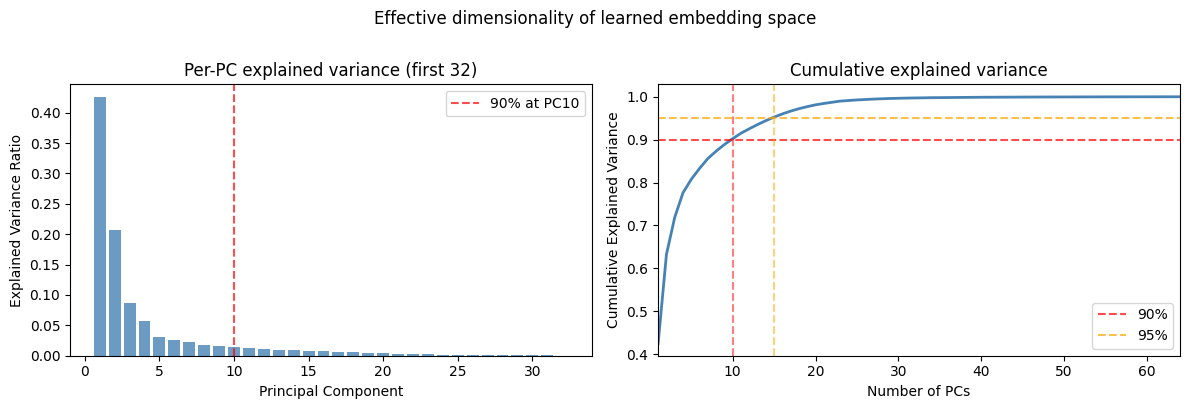

90% variance explained by 10 PCs
95% variance explained by 15 PCs
Effective rank ~ 10 (out of 128 dimensions)


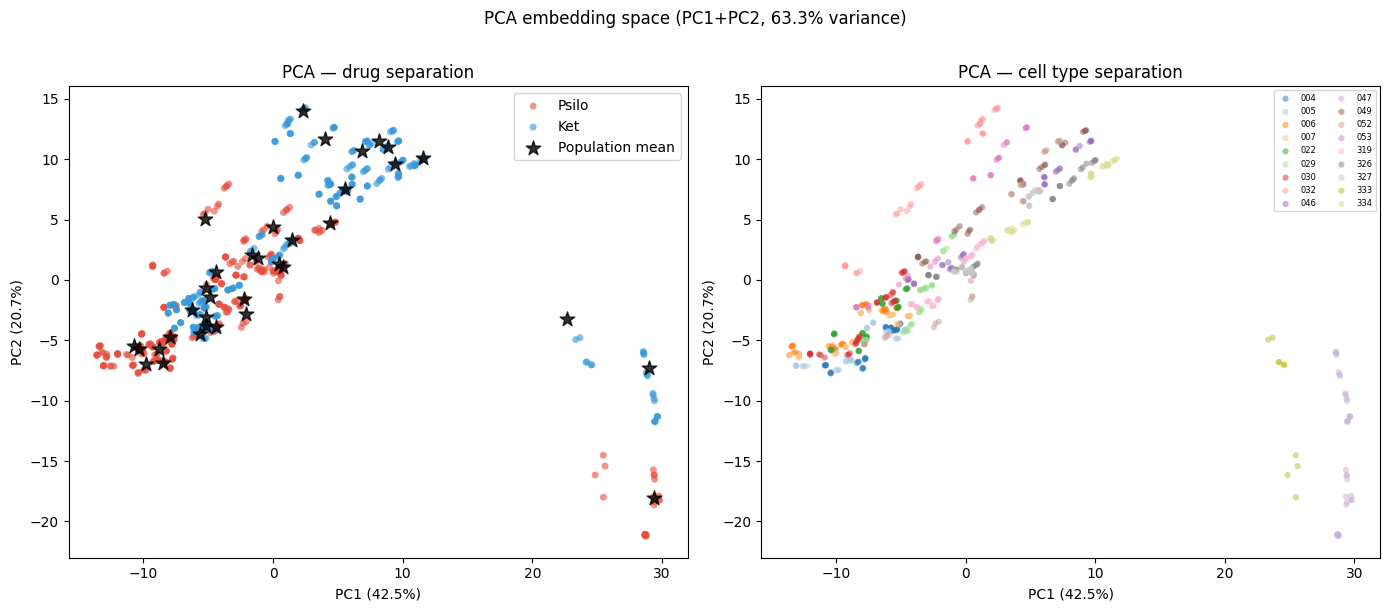


Drug silhouette (PCA, 10 PCs):      0.1796
Cell type silhouette (PCA, 10 PCs): 0.2081


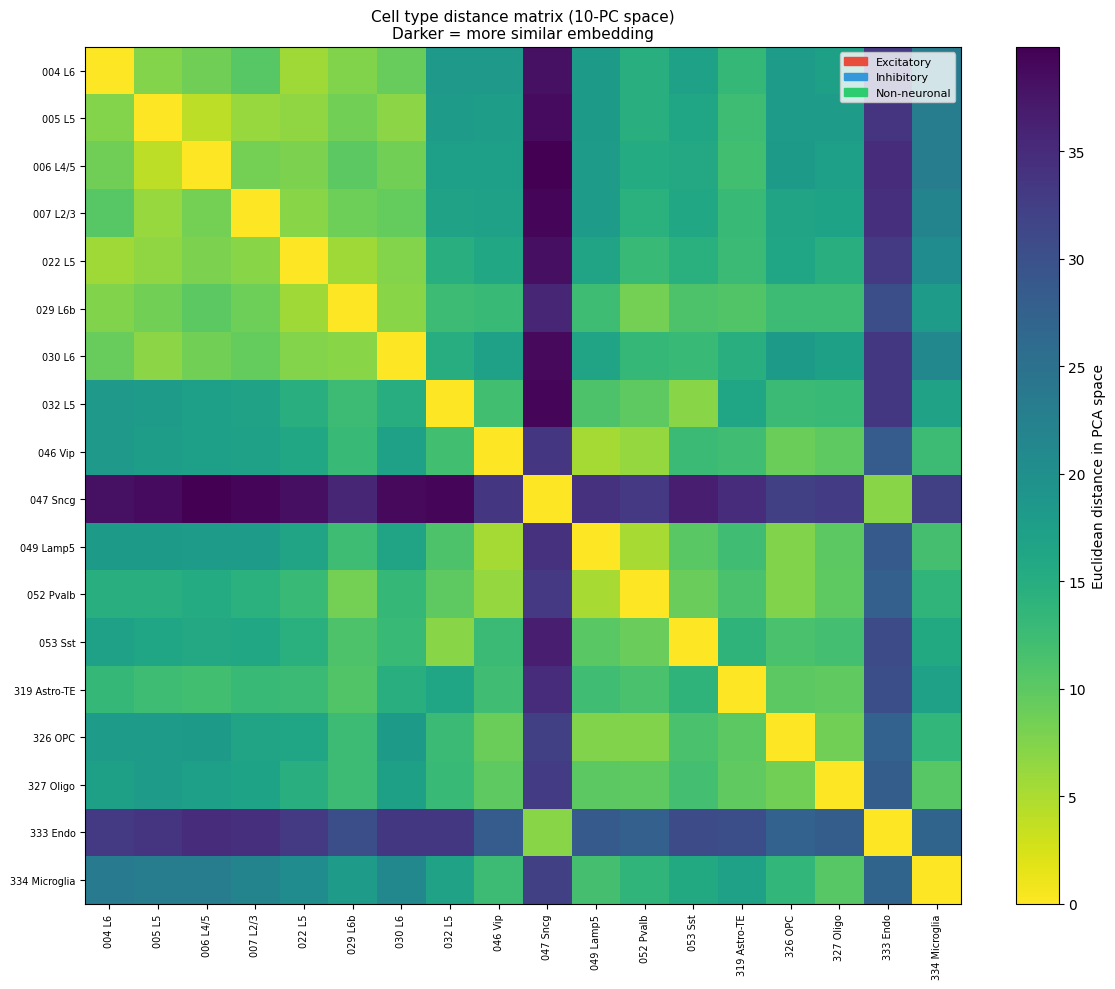


Most similar cell type pairs (smallest PCA distance):
  005    ↔ 006   : 3.947
  049    ↔ 052   : 5.283
  046    ↔ 049   : 5.334
  022    ↔ 029   : 5.624
  004    ↔ 022   : 5.761

Most distant cell type pairs:
  005    ↔ 047   : 38.739
  030    ↔ 047   : 38.866
  007    ↔ 047   : 39.249
  032    ↔ 047   : 39.286
  006    ↔ 047   : 39.868


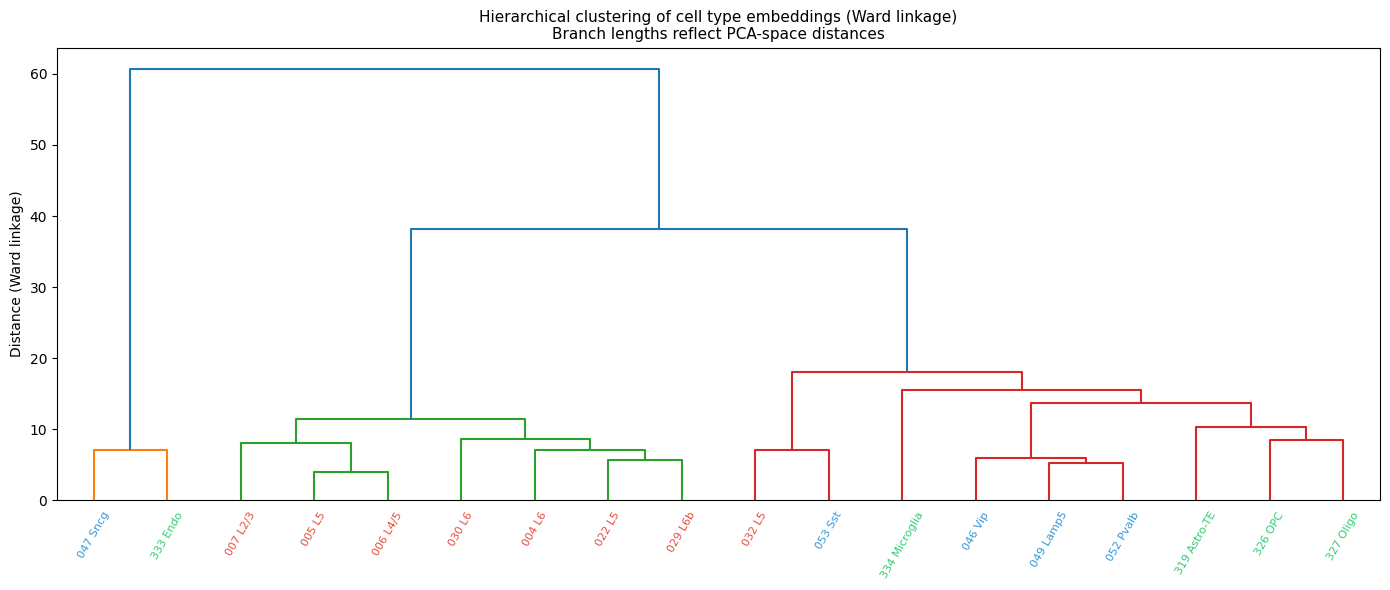

In [ ]:
import os

# ============================================================================
# INVESTIGATION BLOCK 1 — REPRESENTATION ANALYSIS
# ============================================================================

# Ensure the figures directory exists
os.makedirs(f'{DRIVE_PATH}/figures', exist_ok=True)

# ── INV-1A: Explained variance curve (how many dimensions matter?) ───────────
# Run this first — it tells you the effective rank of the embedding space.
# Before interpreting any distances, you need to know how many PCs capture
# the meaningful signal vs noise.

pca_full = PCA(n_components=128)
pca_full.fit(embeddings)

explained    = pca_full.explained_variance_ratio_
cumulative   = np.cumsum(explained)
n_90         = np.argmax(cumulative >= 0.90) + 1
n_95         = np.argmax(cumulative >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, 33), explained[:32], color='steelblue', alpha=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Per-PC explained variance (first 32)')
ax.axvline(x=n_90, color='red', linestyle='--', alpha=0.7,
           label=f'90% at PC{n_90}')
ax.legend()

ax = axes[1]
ax.plot(range(1, 129), cumulative, color='steelblue', linewidth=2)
ax.axhline(y=0.90, color='red',    linestyle='--', alpha=0.7, label='90%')
ax.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax.axvline(x=n_90, color='red',    linestyle='--', alpha=0.5)
ax.axvline(x=n_95, color='orange', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative explained variance')
ax.legend()
ax.set_xlim(1, 64)

plt.suptitle('Effective dimensionality of learned embedding space',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/pca_explained_variance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"90% variance explained by {n_90} PCs")
print(f"95% variance explained by {n_95} PCs")
print(f"Effective rank ~ {n_90} (out of 128 dimensions)")


# ── INV-1B: PCA scatter — drug separation ───────────────────────────────────
# Replace UMAP drug separation plot with PCA. Distances are now meaningful.

pca_2d   = PCA(n_components=2)
emb_2d   = pca_2d.fit_transform(embeddings)

# Individual examples only (exclude population means for cleaner plot)
ind_mask = get_mask(example_type='individual')
pop_mask = get_mask(example_type='population')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: drug coloring
ax = axes[0]
for drug, color in DRUG_COLORS.items():
    if drug == 'population': continue
    m = ind_mask & (drugs_arr == drug)
    ax.scatter(emb_2d[m, 0], emb_2d[m, 1],
               c=color, label=drug, alpha=0.6, s=25, edgecolors='none')
# Population means overlaid as larger markers
ax.scatter(emb_2d[pop_mask, 0], emb_2d[pop_mask, 1],
           c='black', marker='*', s=120, label='Population mean',
           zorder=5, alpha=0.8)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA — drug separation')
ax.legend()

# Panel 2: cell type coloring (individual only)
ax = axes[1]
for ct in ct_list:
    m = ind_mask & (celltypes_arr == ct)
    if m.sum() == 0: continue
    # Abbreviate label: just the numeric prefix
    short = ct.split()[0]
    ax.scatter(emb_2d[m, 0], emb_2d[m, 1],
               c=[CT_COLORS[ct]], label=short, alpha=0.5, s=20,
               edgecolors='none')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA — cell type separation')
ax.legend(fontsize=6, ncol=2, loc='upper right')

plt.suptitle(f'PCA embedding space (PC1+PC2, {(explained[0]+explained[1])*100:.1f}% variance)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/pca_drug_celltype.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Drug silhouette in PCA space (first n_90 PCs — where signal lives)
pca_n90   = PCA(n_components=n_90)
emb_n90   = pca_n90.fit_transform(embeddings)

drug_labels_ind = drugs_arr[ind_mask]
sil_drug_pca    = silhouette_score(emb_n90[ind_mask], drug_labels_ind)
sil_ct_pca      = silhouette_score(emb_n90[ind_mask], celltypes_arr[ind_mask])
print(f"\nDrug silhouette (PCA, {n_90} PCs):      {sil_drug_pca:.4f}")
print(f"Cell type silhouette (PCA, {n_90} PCs): {sil_ct_pca:.4f}")


# ── INV-1C: Cell type distance matrix in PCA space ──────────────────────────
# Pairwise Euclidean distances between cell type centroids in PCA space.
# This is the Ethan-suggested analysis — replaces UMAP-derived visual distance.

centroids = {}
for ct in ct_list:
    m = ind_mask & (celltypes_arr == ct)
    if m.sum() > 0:
        centroids[ct] = emb_n90[m].mean(axis=0)

ct_names  = list(centroids.keys())
ct_matrix = np.stack([centroids[ct] for ct in ct_names])
dist_mat  = cdist(ct_matrix, ct_matrix, metric='euclidean')

# Annotate with cell type class for color coding
ct_class = []
for ct in ct_names:
    if 'Glut' in ct:  ct_class.append('Excitatory')
    elif 'Gaba' in ct: ct_class.append('Inhibitory')
    else:             ct_class.append('Non-neuronal')

class_colors = {'Excitatory': '#E74C3C', 'Inhibitory': '#3498DB',
                'Non-neuronal': '#2ECC71'}
row_colors   = [class_colors[c] for c in ct_class]

# Short labels
short_labels = [ct.split()[0] + ' ' + ct.split()[1] for ct in ct_names]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(dist_mat, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(ct_names)))
ax.set_yticks(range(len(ct_names)))
ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
ax.set_yticklabels(short_labels, fontsize=7)
plt.colorbar(im, ax=ax, label='Euclidean distance in PCA space')
ax.set_title(f'Cell type distance matrix ({n_90}-PC space)\n'
             f'Darker = more similar embedding', fontsize=11)

# Add class legend
legend_handles = [Patch(color=c, label=l)
                  for l, c in class_colors.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/celltype_distance_matrix_pca.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print most similar / most distant pairs
print("\nMost similar cell type pairs (smallest PCA distance):")
triu_idx = np.triu_indices(len(ct_names), k=1)
dists    = [(dist_mat[i, j], ct_names[i], ct_names[j])
            for i, j in zip(*triu_idx)]
dists.sort()
for d, a, b in dists[:5]:
    print(f"  {a.split()[0]:6s} ↔ {b.split()[0]:6s}: {d:.3f}")

print("\nMost distant cell type pairs:")
for d, a, b in dists[-5:]:
    print(f"  {a.split()[0]:6s} ↔ {b.split()[0]:6s}: {d:.3f}")


# ── INV-1D: Hierarchical clustering of cell types (Bonsai-style) ────────────
# Fit a hierarchical tree to cell type centroids.
# Branch lengths = true PCA distances. Captures the known Glut/Gaba/NN split.

Z = linkage(ct_matrix, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(
    Z,
    labels=short_labels,
    leaf_rotation=60,
    leaf_font_size=8,
    ax=ax,
    color_threshold=0.6 * max(Z[:, 2])
)
ax.set_title('Hierarchical clustering of cell type embeddings (Ward linkage)\n'
             'Branch lengths reflect PCA-space distances', fontsize=11)
ax.set_ylabel('Distance (Ward linkage)')

# Color leaf labels by cell type class
for label in ax.get_xticklabels():
    txt  = label.get_text()
    # match back to full ct name
    full = next((ct for ct in ct_names
                 if ct.startswith(txt.split()[0])), None)
    if full:
        cls = ct_class[ct_names.index(full)]
        label.set_color(class_colors[cls])

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/celltype_dendrogram.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.path.exists('/content/drive/MyDrive/attention-to-bio/figures/'))

Mounted at /content/drive
True


Running temporal attention scan: 007 L2/3 IT CTX Glut | Psilo

Top 30 genes by temporal attention CV (007 L2/3 IT CTX Glut, Psilo):
Rank          Gene      CV  PeakTP   PeakVal
   1          Eml5  1.9274      4h  0.067933
   2       Gm46367  1.5631      4h  0.007973
   3         Cdkl5  1.5473      4h  0.017003
   4      Slc39a10  1.5186      4h  0.032810
   5      Kcnq1ot1  1.4418      2h  0.025323
   6          Pak7  1.3288      4h  0.012589
   7       Fam219a  1.3267      4h  0.007048
   8       Gm16599  1.3213      4h  0.006453
   9       Gm28376  1.3191      4h  0.005589
  10         Vsnl1  1.3174      2h  0.013816
  11         Celf4  1.3172      4h  0.008943
  12         Nyap2  1.2820      4h  0.008663
  13         Gsg1l  1.2811      2h  0.006765
  14        Spata7  1.2805      4h  0.006721
  15         Maml3  1.1842      2h  0.002836
  16        Sh3gl2  1.0703      0h  0.001770
  17         Itga8  1.0102      0h  0.002431
  18          Eno2  0.9372      4h  0.001166
  19         

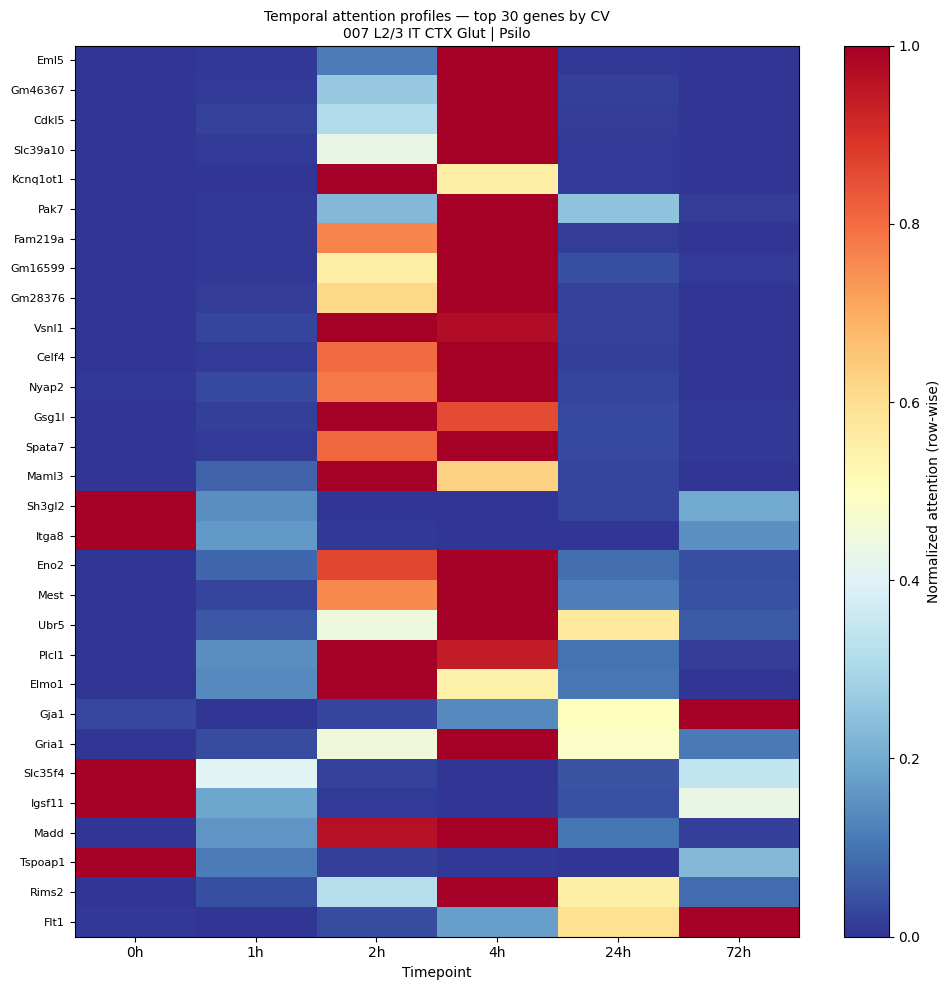


Lowest entropy genes (most focused attention):
  Fcrls          : 6.4857
  4930509J09Rik  : 6.4957
  Plpp4          : 6.5030
  Cry2           : 6.5207
  Grin3a         : 6.5222
  Kctd8          : 6.5512
  Csf1r          : 6.5513
  Bhlhe40        : 6.5514
  Bcan           : 6.5535
  Fgfr3          : 6.5557

Highest entropy genes (most diffuse attention):
  Gm46367        : 6.8195
  Spata7         : 6.8230
  Btbd9          : 6.8241
  Kctd16         : 6.8291
  Apoe           : 6.8300
  Prkcb          : 6.8334
  Grin2a         : 6.8362
  Fam219a        : 6.8513
  Atp1a1         : 6.8837
  Ldb2           : 6.8940


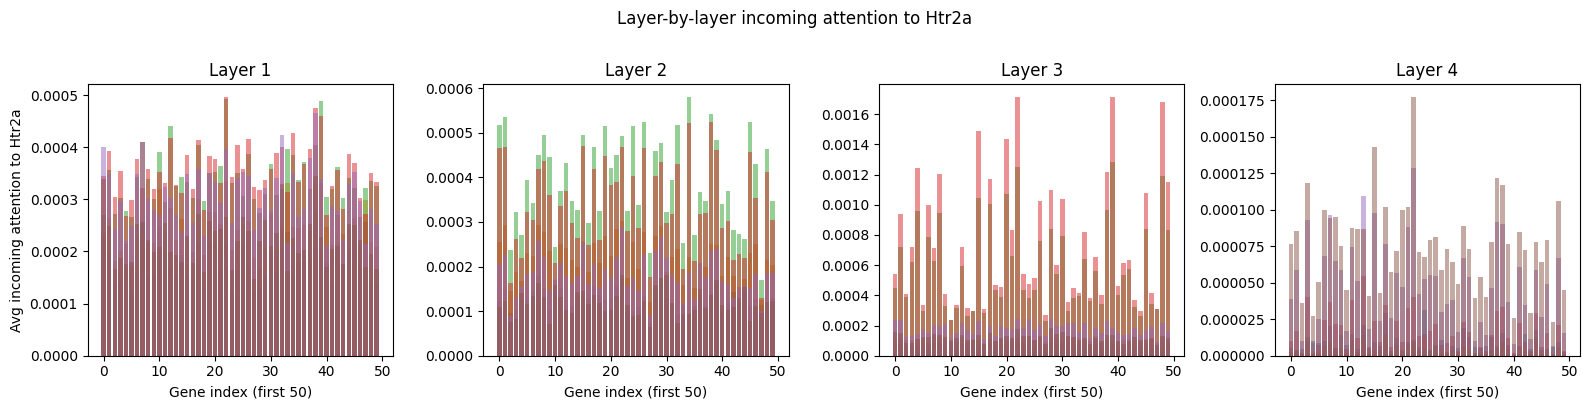

In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 2 — ATTENTION ANALYSIS
# ============================================================================

# ── INV-2A: Systematic temporal attention scan (top 30 genes) ────────────────
# For each gene, compute coefficient of variation of attention across timepoints.
# Genes with high CV have strongly timepoint-dependent attention — interesting.

def compute_temporal_attention_cv(cell_type, drug, model, device):
    """For a given cell_type + drug, compute per-gene attention CV
    using the population mean example (full 6-timepoint trajectory)."""
    idx = next(i for i, m in enumerate(metadata_v5)
               if m['cell_type'] == cell_type
               and m['drug'] == drug
               and m['example_type'] == 'population')
    x    = input_tensor_v5[idx].unsqueeze(0).to(device)
    x_in = x.clone(); x_in[x_in == -1.0] = 0.0
    ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
    dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

    with torch.no_grad():
        all_attn = model.get_attention_weights(x_in, ct, dr)

    # Average across all 4 layers: shape (3060, 3060)
    avg_attn = torch.stack(all_attn).mean(0)[0]

    # For each gene, collect incoming attention across its 6 timepoints
    results = []
    for gi, gene in enumerate(final_genes_500):
        tp_attns = []
        for ti in range(N_TIMEPOINTS):
            pos = gi * N_TIMEPOINTS + ti
            # Incoming attention: how much do all other tokens attend to this pos
            incoming = avg_attn[:, pos].mean().item()
            tp_attns.append(incoming)
        tp_attns = np.array(tp_attns)
        cv = tp_attns.std() / (tp_attns.mean() + 1e-10)
        results.append({'gene': gene, 'tp_attns': tp_attns, 'cv': cv,
                        'peak_tp': TIMEPOINT_LIST[tp_attns.argmax()],
                        'peak_val': tp_attns.max()})
    return sorted(results, key=lambda x: -x['cv'])


# Run for L2/3 IT psilocybin (primary target cell type)
TARGET_CT   = '007 L2/3 IT CTX Glut'
TARGET_DRUG = 'Psilo'
print(f"Running temporal attention scan: {TARGET_CT} | {TARGET_DRUG}")
attn_results = compute_temporal_attention_cv(TARGET_CT, TARGET_DRUG,
                                             model, device)

top30 = attn_results[:30]
print(f"\nTop 30 genes by temporal attention CV ({TARGET_CT}, {TARGET_DRUG}):")
print(f"{'Rank':>4}  {'Gene':>12}  {'CV':>6}  {'PeakTP':>6}  {'PeakVal':>8}")
for rank, r in enumerate(top30, 1):
    print(f"{rank:>4}  {r['gene']:>12}  {r['cv']:>6.4f}  "
          f"{r['peak_tp']:>6}  {r['peak_val']:>8.6f}")

# Heatmap of top 30 gene attention profiles across timepoints
top30_matrix = np.stack([r['tp_attns'] for r in top30])  # (30, 6)
top30_matrix_norm = (top30_matrix - top30_matrix.min(axis=1, keepdims=True)) / \
                    (top30_matrix.max(axis=1, keepdims=True) -
                     top30_matrix.min(axis=1, keepdims=True) + 1e-10)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(top30_matrix_norm, cmap='RdYlBu_r', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(range(N_TIMEPOINTS))
ax.set_xticklabels(TIMEPOINT_LIST)
ax.set_yticks(range(30))
ax.set_yticklabels([r['gene'] for r in top30], fontsize=8)
plt.colorbar(im, ax=ax, label='Normalized attention (row-wise)')
ax.set_xlabel('Timepoint')
ax.set_title(f'Temporal attention profiles — top 30 genes by CV\n'
             f'{TARGET_CT} | {TARGET_DRUG}', fontsize=10)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/systematic_attention_top30.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── INV-2B: Attention entropy per gene ──────────────────────────────────────
# Entropy quantifies how spread vs concentrated attention is.
# Low entropy = model attends to a few specific tokens (precise, selective).
# High entropy = model spreads attention broadly (diffuse, uncertain).

def attention_entropy(attn_row):
    """Shannon entropy of an attention distribution."""
    p = attn_row + 1e-10
    p = p / p.sum()
    return -(p * np.log(p)).sum()

# Use the same population mean example
idx = next(i for i, m in enumerate(metadata_v5)
           if m['cell_type'] == TARGET_CT
           and m['drug'] == TARGET_DRUG
           and m['example_type'] == 'population')
x    = input_tensor_v5[idx].unsqueeze(0).to(device)
x_in = x.clone(); x_in[x_in == -1.0] = 0.0
ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

with torch.no_grad():
    all_attn = model.get_attention_weights(x_in, ct, dr)

avg_attn_np = torch.stack(all_attn).mean(0)[0].numpy()  # (3060, 3060)

# Per-gene entropy: average entropy across that gene's 6 timepoint rows
gene_entropies = []
for gi, gene in enumerate(final_genes_500):
    ent = np.mean([attention_entropy(avg_attn_np[gi*N_TIMEPOINTS + ti])
                   for ti in range(N_TIMEPOINTS)])
    gene_entropies.append((gene, ent))

gene_entropies.sort(key=lambda x: x[1])

print("\nLowest entropy genes (most focused attention):")
for gene, ent in gene_entropies[:10]:
    print(f"  {gene:15s}: {ent:.4f}")
print("\nHighest entropy genes (most diffuse attention):")
for gene, ent in gene_entropies[-10:]:
    print(f"  {gene:15s}: {ent:.4f}")


# ── INV-2C: Layer-by-layer attention evolution ───────────────────────────────
# Do early and late layers attend differently?
# Early layers often capture local/syntactic structure.
# Late layers often capture semantic/abstract structure.
# In our model: early = co-expression within timepoint? Late = temporal patterns?

layer_attns = [a[0].numpy() for a in all_attn]  # list of (3060, 3060)

# For a focal gene (Htr2a) track how its incoming attention changes across layers
focal_gene = 'Htr2a'
focal_gi   = final_genes_500.index(focal_gene)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for li, layer_attn in enumerate(layer_attns):
    ax = axes[li]
    # Incoming attention to focal gene across all timepoints and layers
    for ti, tp in enumerate(TIMEPOINT_LIST):
        pos = focal_gi * N_TIMEPOINTS + ti
        incoming = layer_attn[:, pos]  # (3060,)
        # Average by timepoint group
        tp_means = [layer_attn[gi*N_TIMEPOINTS:gi*N_TIMEPOINTS+N_TIMEPOINTS,
                               pos].mean()
                    for gi in range(min(50, N_GENES))]
        ax.bar(range(len(tp_means)), tp_means, alpha=0.5)
    ax.set_title(f'Layer {li+1}')
    ax.set_xlabel('Gene index (first 50)')
    if li == 0: ax.set_ylabel('Avg incoming attention to Htr2a')

plt.suptitle(f'Layer-by-layer incoming attention to {focal_gene}', y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/layer_attention_evolution.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 3 — PROBING
# ============================================================================

# ── INV-3A: Linear probes — what information is linearly decodable? ──────────
# A linear probe trains a logistic regression on frozen embeddings.
# If it achieves high accuracy, that information is linearly accessible
# in the representation — the model explicitly encoded it.
# If it fails, the information either isn't there or is entangled nonlinearly.

from sklearn.model_selection import cross_val_score

# Only use individual examples for probing (population means are special)
ind_emb   = embeddings[ind_mask]
ind_drugs = drugs_arr[ind_mask]
ind_cts   = celltypes_arr[ind_mask]
ind_anis  = animals_arr[ind_mask]
ind_tps   = tps_arr[ind_mask]

def run_probe(X, y, name, cv=5):
    """Logistic regression probe with cross-validation."""
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    scores = cross_val_score(clf, X, y_enc, cv=cv, scoring='balanced_accuracy')
    print(f"  {name:30s}: {scores.mean():.3f} ± {scores.std():.3f}  "
          f"(n_classes={len(le.classes_)})")
    return scores

print("\nLinear probe results (5-fold CV, balanced accuracy):")
print(f"  {'Task':30s}  {'Mean':>6}  {'Std':>6}  {'n_classes':>10}")
probe_drug = run_probe(ind_emb, ind_drugs, 'Drug (Psilo vs Ket)')
probe_ct   = run_probe(ind_emb, ind_cts,   'Cell type (18 classes)')
probe_tp   = run_probe(ind_emb, ind_tps,   'Timepoint (5 drug TPs)')
probe_anim = run_probe(ind_emb, ind_anis,  'Animal identity')

# Chance levels for reference
print(f"\n  Chance for drug:     0.500")
print(f"  Chance for cell type: {1/18:.3f}")
print(f"  Chance for timepoint: {1/5:.3f}")
print(f"  Chance for animal:   varies (~{1/17:.3f})")


# ── INV-3B: Probe in PCA space — does reducing dimensions help or hurt? ──────
print("\nProbe in PCA space (first n_90 PCs):")
ind_emb_pca = emb_n90[ind_mask]
run_probe(ind_emb_pca, ind_drugs, 'Drug (PCA space)')
run_probe(ind_emb_pca, ind_cts,   'Cell type (PCA space)')
run_probe(ind_emb_pca, ind_tps,   'Timepoint (PCA space)')


Linear probe results (5-fold CV, balanced accuracy):
  Task                              Mean     Std   n_classes
  Drug (Psilo vs Ket)           : 1.000 ± 0.000  (n_classes=2)
  Cell type (18 classes)        : 1.000 ± 0.000  (n_classes=18)
  Timepoint (5 drug TPs)        : 0.974 ± 0.016  (n_classes=5)
  Animal identity               : 0.100 ± 0.038  (n_classes=34)

  Chance for drug:     0.500
  Chance for cell type: 0.056
  Chance for timepoint: 0.200
  Chance for animal:   varies (~0.059)

Probe in PCA space (first n_90 PCs):
  Drug (PCA space)              : 1.000 ± 0.000  (n_classes=2)
  Cell type (PCA space)         : 1.000 ± 0.000  (n_classes=18)
  Timepoint (PCA space)         : 0.332 ± 0.045  (n_classes=5)


array([0.29761905, 0.26038095, 0.36914286, 0.3742236 , 0.35642857])

In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 4 — PERTURBATION ANALYSIS
# (placeholder structure — fill after Blocks 1-3 are interpreted)
# ============================================================================

# ── INV-4A: Drug label swap ───────────────────────────────────────────────────
# Take a psilocybin example, change drug_id to ketamine at inference.
# Measure how far the embedding moves. If large shift → drug conditioning
# is doing real work. If small → drug embedding contributes little.

def embedding_shift_drug_swap(model, device, n_examples=20):
    """For n individual psilocybin examples, compute embedding with
    correct drug label vs swapped drug label. Return distances."""
    psilo_idx = np.where(ind_mask & (drugs_arr == 'Psilo'))[0][:n_examples]
    shifts = []
    with torch.no_grad():
        for idx in psilo_idx:
            x    = input_tensor_v5[idx].unsqueeze(0).to(device)
            x_in = x.clone(); x_in[x_in == -1.0] = 0.0
            ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
            dr_0 = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)
            dr_1 = torch.tensor([1 - metadata_v5[idx]['drug_idx']]).to(device)
            emb_0 = model.get_embedding(x_in, ct, dr_0).cpu().numpy()
            emb_1 = model.get_embedding(x_in, ct, dr_1).cpu().numpy()
            shifts.append(np.linalg.norm(emb_0 - emb_1))
    return np.array(shifts)

shifts = embedding_shift_drug_swap(model, device)
print(f"\nDrug label swap embedding shift:")
print(f"  Mean: {shifts.mean():.4f} | Std: {shifts.std():.4f} | "
      f"Min: {shifts.min():.4f} | Max: {shifts.max():.4f}")
# Compare to typical within-drug between-example distance for scale
psilo_embs = embeddings[ind_mask & (drugs_arr == 'Psilo')]
ket_embs   = embeddings[ind_mask & (drugs_arr == 'Ket')]
within_psilo = cdist(psilo_embs[:20], psilo_embs[:20]).mean()
cross_drug   = cdist(psilo_embs[:20], ket_embs[:20]).mean()
print(f"  Within-drug distance (reference): {within_psilo:.4f}")
print(f"  Cross-drug distance  (reference): {cross_drug:.4f}")


# ── INV-4B: Sentinel injection — timepoint dropout ───────────────────────────
# Take population mean examples (all timepoints filled).
# Replace each drug timepoint column with sentinel one at a time.
# Measure embedding shift. Which timepoints contribute most to the representation?

def timepoint_importance(model, device, cell_type, drug):
    """Ablate each drug timepoint and measure embedding shift
    from full-information baseline."""
    idx = next(i for i, m in enumerate(metadata_v5)
               if m['cell_type'] == cell_type
               and m['drug'] == drug
               and m['example_type'] == 'population')
    x    = input_tensor_v5[idx].unsqueeze(0).to(device)
    ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
    dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

    with torch.no_grad():
        emb_full = model.get_embedding(x.clone(), ct, dr).cpu().numpy()
        shifts = {}
        for ti, tp in enumerate(TIMEPOINT_LIST):
            if tp == '0h': continue  # baseline always present
            x_abl = x.clone()
            x_abl[0, :, ti] = -1.0  # inject sentinel
            emb_abl = model.get_embedding(x_abl, ct, dr).cpu().numpy()
            shifts[tp] = np.linalg.norm(emb_full - emb_abl)
    return shifts

tp_shifts = timepoint_importance(model, device, TARGET_CT, TARGET_DRUG)
print(f"\nTimepoint importance ({TARGET_CT} | {TARGET_DRUG}):")
print(f"  (embedding shift when that timepoint is sentineled out)")
for tp, shift in sorted(tp_shifts.items(), key=lambda x: -x[1]):
    bar = '█' * int(shift / max(tp_shifts.values()) * 30)
    print(f"  {tp:>4}: {shift:.4f}  {bar}")


Drug label swap embedding shift:
  Mean: 14.1597 | Std: 3.6130 | Min: 10.8448 | Max: 22.1498
  Within-drug distance (reference): 16.1855
  Cross-drug distance  (reference): 21.6537

Timepoint importance (007 L2/3 IT CTX Glut | Psilo):
  (embedding shift when that timepoint is sentineled out)
    2h: 1.9080  ██████████████████████████████
    4h: 1.5581  ████████████████████████
    1h: 1.2558  ███████████████████
   24h: 0.7173  ███████████
   72h: 0.6821  ██████████


In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 5 — CO-ATTENTION CLUSTER ANALYSIS
# ============================================================================
# Goal: extract the gene × gene attention matrix, cluster it, and compare
# clusters against known biological pathways (KEGG/GO via gprofiler).
#
# The key question: did the model learn to group genes by biological function
# without ever being told about pathways?
# ============================================================================

!pip install gprofiler-official scipy -q

from gprofiler import GProfiler
from scipy.cluster.hierarchy import fcluster

# ── INV-5A: Extract aggregate gene × gene attention matrix ───────────────────
# Strategy: run get_attention_weights on ALL population mean examples
# (one per drug × cell type — 35 examples, all timepoints real).
# Average the resulting attention matrices across all examples and all layers.
# Then collapse the timepoint dimension to get a 510 × 510 gene × gene matrix.

def extract_gene_gene_attention(model, device, metadata_v5, input_tensor_v5,
                                 final_genes_500, n_genes, n_timepoints,
                                 example_type='population'):
    """
    Returns: gene_attn (n_genes, n_genes) — aggregate attention matrix.
    Entry [i, j] = how much gene i attends to gene j, averaged across
    all timepoint pairs, all layers, and all population mean examples.
    """
    pop_indices = [i for i, m in enumerate(metadata_v5)
                   if m['example_type'] == example_type]
    print(f"Extracting attention from {len(pop_indices)} {example_type} examples...")

    # Accumulator: sum over examples
    gene_attn_sum = np.zeros((n_genes, n_genes), dtype=np.float64)
    n_accumulated = 0

    for count, idx in enumerate(pop_indices):
        x    = input_tensor_v5[idx].unsqueeze(0).to(device)
        # Sentinels → 0 for model input (population means have no sentinels,
        # but defensive programming here doesn't hurt)
        x_in = x.clone(); x_in[x_in == -1.0] = 0.0
        ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
        dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

        with torch.no_grad():
            all_attn = model.get_attention_weights(x_in, ct, dr)

        # Average across 4 layers → (seq_len, seq_len) = (3060, 3060)
        avg_attn = torch.stack(all_attn).mean(0)[0].numpy()  # (3060, 3060)

        # Collapse timepoints: for each gene pair (i, j),
        # sum attention across all 6×6 timepoint combinations.
        # avg_attn[i*T+ti, j*T+tj] is attention from gene-i@tp-ti to gene-j@tp-tj
        # Reshape to (n_genes, n_tp, n_genes, n_tp) then sum over both tp axes.
        T = n_timepoints
        G = n_genes
        # avg_attn shape: (G*T, G*T)
        # Reshape: rows = (G, T), cols = (G, T)
        attn_4d = avg_attn.reshape(G, T, G, T)   # (G, T, G, T)
        gene_gene = attn_4d.sum(axis=(1, 3))       # (G, G) — sum over both T axes

        gene_attn_sum += gene_gene
        n_accumulated += 1

        if (count + 1) % 10 == 0:
            print(f"  Processed {count+1}/{len(pop_indices)} examples")

    gene_attn_agg = gene_attn_sum / n_accumulated

    # Symmetrize: attention is not symmetric (i→j ≠ j→i) but for clustering
    # we want an undirected similarity. Average both directions.
    gene_attn_sym = (gene_attn_agg + gene_attn_agg.T) / 2.0

    print(f"Gene-gene attention matrix: {gene_attn_sym.shape}")
    print(f"  Min: {gene_attn_sym.min():.6f} | "
          f"Max: {gene_attn_sym.max():.6f} | "
          f"Mean: {gene_attn_sym.mean():.6f}")

    return gene_attn_agg, gene_attn_sym


gene_attn_raw, gene_attn_sym = extract_gene_gene_attention(
    model, device, metadata_v5, input_tensor_v5,
    final_genes_500, N_GENES, N_TIMEPOINTS)

# Save for reuse (extraction takes a few minutes)
np.save(f'{DRIVE_PATH}/checkpoints/gene_gene_attn_raw.npy', gene_attn_raw)
np.save(f'{DRIVE_PATH}/checkpoints/gene_gene_attn_sym.npy', gene_attn_sym)
print("Saved attention matrices.")

Extracting attention from 35 population examples...
  Processed 10/35 examples
  Processed 20/35 examples
  Processed 30/35 examples
Gene-gene attention matrix: (510, 510)
  Min: 0.004341 | Max: 0.216723 | Mean: 0.011765
Saved attention matrices.


In [ ]:
# ── INV-5B: Cluster the gene × gene matrix ───────────────────────────────────
# Convert attention → distance (high attention = similar = small distance),
# then apply hierarchical clustering. Cut the tree into clusters.
#
# Distance = 1 - normalized_attention
# Normalize per-row so each gene's attention sums to 1 (probability-like).

# Row-normalize the symmetric matrix
row_sums = gene_attn_sym.sum(axis=1, keepdims=True) + 1e-10
gene_attn_norm = gene_attn_sym / row_sums   # (G, G) — rows sum to 1

# Convert to distance
attn_dist = 1.0 - gene_attn_norm            # (G, G) — high attention = low distance

# Force symmetry and zero diagonal (numerical cleanup)
attn_dist = (attn_dist + attn_dist.T) / 2.0
np.fill_diagonal(attn_dist, 0.0)
np.clip(attn_dist, 0.0, None, out=attn_dist)  # no negative distances

# Hierarchical clustering on condensed distance matrix
from scipy.spatial.distance import squareform
condensed = squareform(attn_dist, checks=False)
Z_genes   = linkage(condensed, method='average')

# Cut into clusters — try a range and pick by interpretability
# Start with 8-12 clusters (enough to be biologically meaningful,
# few enough to query pathways clearly)
N_CLUSTERS = 10
cluster_labels = fcluster(Z_genes, N_CLUSTERS, criterion='maxclust')

print(f"\nCluster sizes (N_CLUSTERS={N_CLUSTERS}):")
for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    print(f"  Cluster {c:2d}: {len(members):3d} genes  "
          f"  {', '.join(members[:6])}{'...' if len(members)>6 else ''}")



Cluster sizes (N_CLUSTERS=10):
  Cluster  1: 501 genes    Grin2b, Sv2b, Shisa6, Shisa9, Pou6f2, Igsf9b...
  Cluster  2:   1 genes    Rapgefl1
  Cluster  3:   1 genes    Skil
  Cluster  4:   1 genes    Slc7a1
  Cluster  5:   1 genes    Comt
  Cluster  6:   1 genes    6330411D24Rik
  Cluster  7:   1 genes    Fndc9
  Cluster  8:   1 genes    Zmiz1
  Cluster  9:   1 genes    St8sia5
  Cluster 10:   1 genes    Clstn3


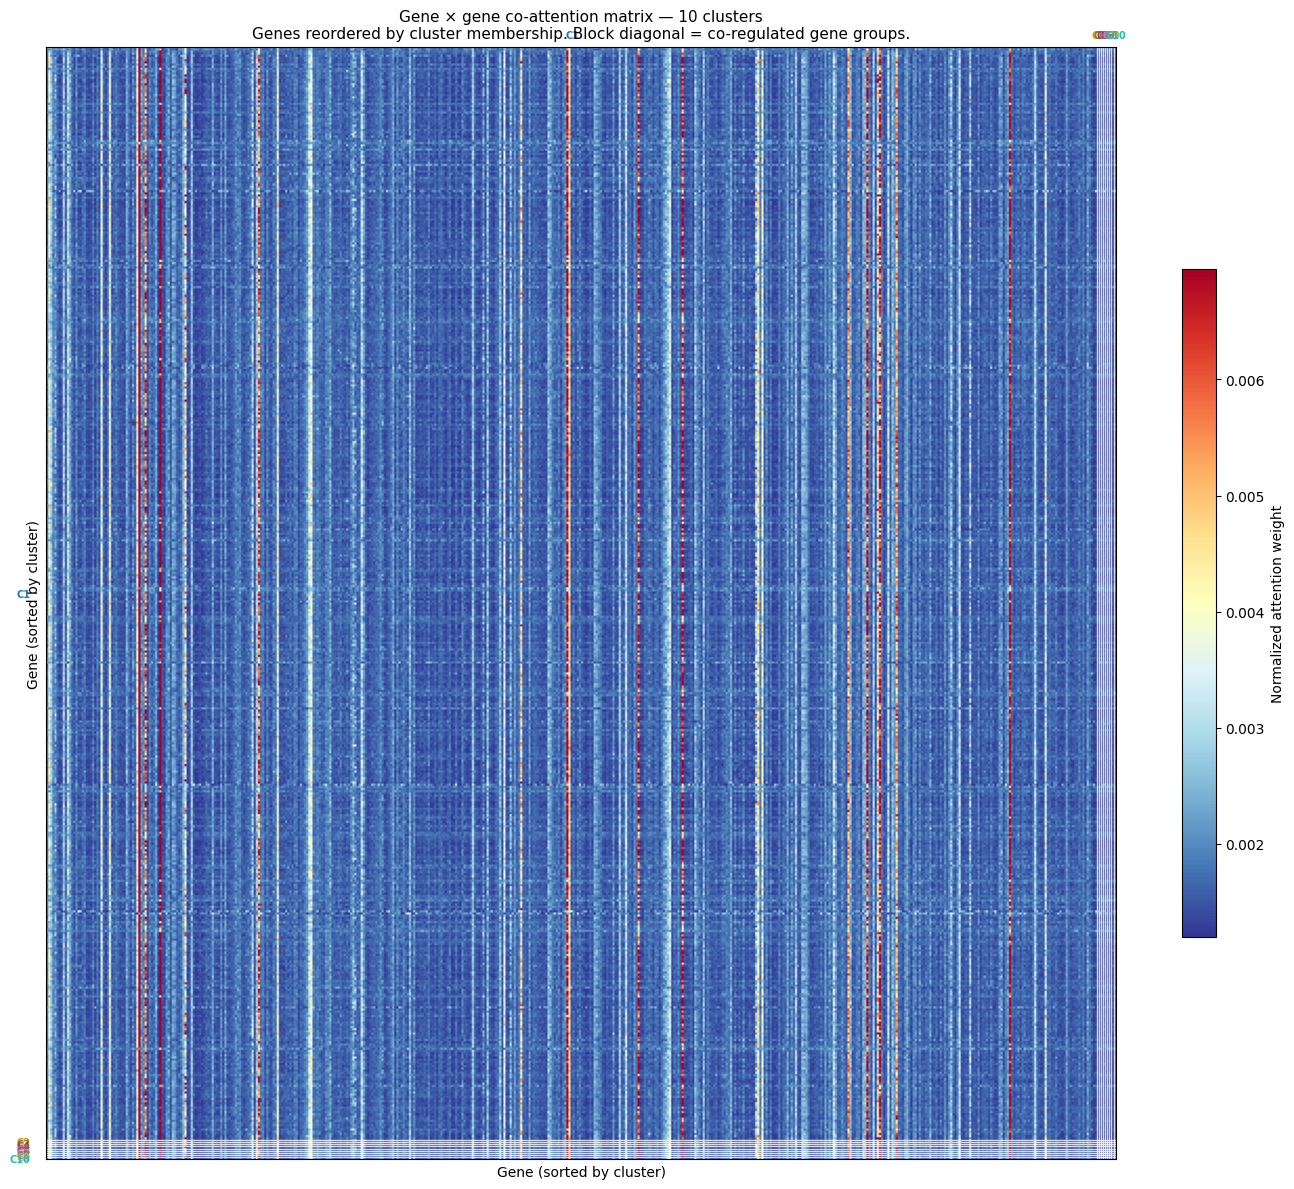

In [ ]:
# ── INV-5C: Visualize the clustered attention matrix ─────────────────────────
# Reorder genes by cluster membership, then plot the heatmap.
# Block-diagonal structure = model learned coherent gene groups.

# Sort genes by cluster label
sort_order  = np.argsort(cluster_labels)
sorted_attn = gene_attn_norm[sort_order][:, sort_order]
sorted_labels = cluster_labels[sort_order]

# Cluster boundary positions for overlay lines
boundaries = []
prev = sorted_labels[0]
for i, cl in enumerate(sorted_labels):
    if cl != prev:
        boundaries.append(i)
        prev = cl

# Color bar per cluster
cluster_colors = plt.cm.tab10.colors
row_color_arr  = np.array([cluster_colors[(cl-1) % 10]
                            for cl in sorted_labels])

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sorted_attn, cmap='RdYlBu_r', aspect='auto',
               vmin=np.percentile(sorted_attn, 1),
               vmax=np.percentile(sorted_attn, 99))
plt.colorbar(im, ax=ax, label='Normalized attention weight', shrink=0.6)

# Draw cluster boundary lines
for b in boundaries:
    ax.axhline(y=b - 0.5, color='white', linewidth=1.0, alpha=0.8)
    ax.axvline(x=b - 0.5, color='white', linewidth=1.0, alpha=0.8)

ax.set_title(f'Gene × gene co-attention matrix — {N_CLUSTERS} clusters\n'
             f'Genes reordered by cluster membership. '
             f'Block diagonal = co-regulated gene groups.', fontsize=11)
ax.set_xlabel('Gene (sorted by cluster)')
ax.set_ylabel('Gene (sorted by cluster)')
ax.set_xticks([])
ax.set_yticks([])

# Cluster label annotations on axes
prev_b = 0
for ci, b in enumerate(boundaries + [N_GENES]):
    mid = (prev_b + b) / 2
    ax.text(mid, -8, f'C{ci+1}', ha='center', va='top',
            fontsize=7, color=cluster_colors[ci % 10], fontweight='bold')
    ax.text(-8, mid, f'C{ci+1}', ha='right', va='center',
            fontsize=7, color=cluster_colors[ci % 10], fontweight='bold')
    prev_b = b

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/coattn_heatmap_{N_CLUSTERS}clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── INV-5D: Pathway enrichment per cluster ───────────────────────────────────
# Query g:Profiler for each cluster. Uses mouse gene IDs (organism='mmusculus').
# Returns GO biological process, KEGG pathway, and Reactome annotations.

gp = GProfiler(return_dataframe=True)

cluster_enrichment = {}
print(f"\nRunning pathway enrichment for {N_CLUSTERS} clusters...")
print("(organism: mmusculus — mouse gene symbols)\n")

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]

    if len(members) < 3:
        print(f"Cluster {c}: too small ({len(members)} genes), skipping")
        continue

    try:
        result = gp.profile(
            organism='mmusculus',
            query=members,
            sources=['GO:BP', 'KEGG', 'REAC'],  # biological process + pathways
            significance_threshold_method='fdr',
            user_threshold=0.05,
            no_evidences=False
        )

        if result.empty:
            print(f"Cluster {c:2d} ({len(members):3d} genes): "
                  f"No significant enrichment")
            cluster_enrichment[c] = None
        else:
            # Keep top 5 results per cluster
            top = result.nsmallest(5, 'p_value')[
                ['name', 'source', 'p_value', 'intersection_size']
            ]
            cluster_enrichment[c] = result
            print(f"Cluster {c:2d} ({len(members):3d} genes) — top hits:")
            for _, row in top.iterrows():
                print(f"  [{row['source']:8s}] {row['name'][:55]:55s} "
                      f"p={row['p_value']:.2e}  "
                      f"n={row['intersection_size']}")
            print()

    except Exception as e:
        print(f"Cluster {c}: enrichment failed — {e}")
        cluster_enrichment[c] = None



Running pathway enrichment for 10 clusters...
(organism: mmusculus — mouse gene symbols)

Cluster  1 (501 genes) — top hits:
  [GO:BP   ] synaptic signaling                                      p=1.71e-42  n=90
  [GO:BP   ] trans-synaptic signaling                                p=3.46e-42  n=88
  [GO:BP   ] chemical synaptic transmission                          p=5.84e-42  n=87
  [GO:BP   ] anterograde trans-synaptic signaling                    p=5.84e-42  n=87
  [GO:BP   ] cell-cell signaling                                     p=1.21e-38  n=101

Cluster 2: too small (1 genes), skipping
Cluster 3: too small (1 genes), skipping
Cluster 4: too small (1 genes), skipping
Cluster 5: too small (1 genes), skipping
Cluster 6: too small (1 genes), skipping
Cluster 7: too small (1 genes), skipping
Cluster 8: too small (1 genes), skipping
Cluster 9: too small (1 genes), skipping
Cluster 10: too small (1 genes), skipping


In [ ]:
# ── INV-5E: Summary table — cluster → top pathway ────────────────────────────
print("\n" + "="*70)
print("SUMMARY: Cluster → biological annotation")
print("="*70)
print(f"{'Cluster':>8}  {'N genes':>8}  {'Top pathway':55}  {'Source':8}  {'p-value':>10}")
print("-"*70)

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    enr = cluster_enrichment.get(c)

    if enr is None or (hasattr(enr, 'empty') and enr.empty):
        top_name   = "— no significant enrichment —"
        top_source = ""
        top_p      = float('nan')
    else:
        top_row    = enr.nsmallest(1, 'p_value').iloc[0]
        top_name   = top_row['name'][:55]
        top_source = top_row['source']
        top_p      = top_row['p_value']

    print(f"  C{c:2d}    {len(members):>8}  {top_name:55}  "
          f"{top_source:8}  {top_p:>10.2e}" if not np.isnan(top_p)
          else f"  C{c:2d}    {len(members):>8}  {top_name}")




SUMMARY: Cluster → biological annotation
 Cluster   N genes  Top pathway                                              Source       p-value
----------------------------------------------------------------------
  C 1         501  synaptic signaling                                       GO:BP       1.71e-42
  C 2           1  — no significant enrichment —
  C 3           1  — no significant enrichment —
  C 4           1  — no significant enrichment —
  C 5           1  — no significant enrichment —
  C 6           1  — no significant enrichment —
  C 7           1  — no significant enrichment —
  C 8           1  — no significant enrichment —
  C 9           1  — no significant enrichment —
  C10           1  — no significant enrichment —


In [ ]:
# ── INV-5F: Condition-specific attention — does co-regulation change? ─────────
# For any cluster that shows strong pathway enrichment, compare its internal
# attention strength under psilocybin vs ketamine.
# High internal attention = model sees these genes as strongly co-regulated.
# If psilo >> ket for a cluster, the co-regulation is drug-specific.

def cluster_internal_attention(gene_attn_matrix, cluster_labels, cluster_id,
                                n_genes):
    """Mean attention weight within a cluster (internal cohesion)."""
    members_idx = np.where(cluster_labels == cluster_id)[0]
    if len(members_idx) < 2:
        return 0.0
    sub = gene_attn_matrix[np.ix_(members_idx, members_idx)]
    # Exclude diagonal (self-attention)
    np.fill_diagonal(sub, 0)
    return sub.sum() / (len(members_idx) * (len(members_idx) - 1))


# Extract drug-specific attention matrices
print("\nExtracting drug-specific attention matrices...")
psilo_pops = [i for i, m in enumerate(metadata_v5)
              if m['example_type'] == 'population' and m['drug'] == 'Psilo']
ket_pops   = [i for i, m in enumerate(metadata_v5)
              if m['example_type'] == 'population' and m['drug'] == 'Ket']

def extract_subset_attention(indices):
    attn_sum = np.zeros((N_GENES, N_GENES))
    for idx in indices:
        x    = input_tensor_v5[idx].unsqueeze(0).to(device)
        x_in = x.clone(); x_in[x_in == -1.0] = 0.0
        ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
        dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)
        with torch.no_grad():
            all_attn = model.get_attention_weights(x_in, ct, dr)
        avg   = torch.stack(all_attn).mean(0)[0].numpy()
        attn_4d = avg.reshape(N_GENES, N_TIMEPOINTS, N_GENES, N_TIMEPOINTS)
        attn_sum += attn_4d.sum(axis=(1, 3))
    return attn_sum / len(indices)

psilo_attn = extract_subset_attention(psilo_pops)
ket_attn   = extract_subset_attention(ket_pops)

print("\nCluster internal cohesion: Psilo vs Ket")
print(f"{'Cluster':>8}  {'N genes':>8}  {'Psilo':>8}  {'Ket':>8}  "
      f"{'Ratio P/K':>10}  Top pathway")
print("-"*80)

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    p_coh = cluster_internal_attention(psilo_attn, cluster_labels, c, N_GENES)
    k_coh = cluster_internal_attention(ket_attn,   cluster_labels, c, N_GENES)
    ratio = p_coh / (k_coh + 1e-10)

    enr = cluster_enrichment.get(c)
    pathway = ""
    if enr is not None and not (hasattr(enr, 'empty') and enr.empty):
        pathway = enr.nsmallest(1, 'p_value').iloc[0]['name'][:40]

    print(f"  C{c:2d}    {len(members):>8}  {p_coh:>8.4f}  {k_coh:>8.4f}  "
          f"{ratio:>10.3f}  {pathway}")


Extracting drug-specific attention matrices...

Cluster internal cohesion: Psilo vs Ket
 Cluster   N genes     Psilo       Ket   Ratio P/K  Top pathway
--------------------------------------------------------------------------------
  C 1         501    0.0119    0.0119       1.002  synaptic signaling
  C 2           1    0.0000    0.0000       0.000  
  C 3           1    0.0000    0.0000       0.000  
  C 4           1    0.0000    0.0000       0.000  
  C 5           1    0.0000    0.0000       0.000  
  C 6           1    0.0000    0.0000       0.000  
  C 7           1    0.0000    0.0000       0.000  
  C 8           1    0.0000    0.0000       0.000  
  C 9           1    0.0000    0.0000       0.000  
  C10           1    0.0000    0.0000       0.000  


Extracting attention from 35 population examples...
  Processed 10/35 examples
  Processed 20/35 examples
  Processed 30/35 examples
Gene-gene attention matrix: (510, 510)
  Min: 0.004341 | Max: 0.216723 | Mean: 0.011765
Saved attention matrices.
Z-scored attention matrix:
  Mean: -0.0000 (should be ~0)
  Std:  1.0000  (should be ~1)
  Min:  -0.8099 | Max: 22.3618

Sparsified at 80th percentile (threshold=0.190)
  Sparsity: 80.0% zeros
  Non-zero entries: 51,942

Cluster sizes (N_CLUSTERS=15):
  Cluster  1:   3 genes    Ptprm, Dip2a, Ccdc148
  Cluster  2:   5 genes    Tek, Htr1f, Igsf11, Tox, Gm13963
  Cluster  3:  11 genes    Grin2b, Baiap2, Fam135b, Ptk2b, Sox2ot, Bach2...
  Cluster  4:  17 genes    Nos1ap, Ldb2, Snhg14, Slc4a10, Rims2, Dock2...
  Cluster  5:  17 genes    Hcn1, Arhgap26, Aifm3, Ndrg4, Sh3gl2, Atp2b1...
  Cluster  6:  10 genes    Syt1, Ntrk2, Atp1a1, Kifc2, Kcnn2, Dgkb...
  Cluster  7:  20 genes    Shisa9, Rian, Cacna1e, Gria1, Unc79, Mir124a-1hg...
  Cluster  8:  13 

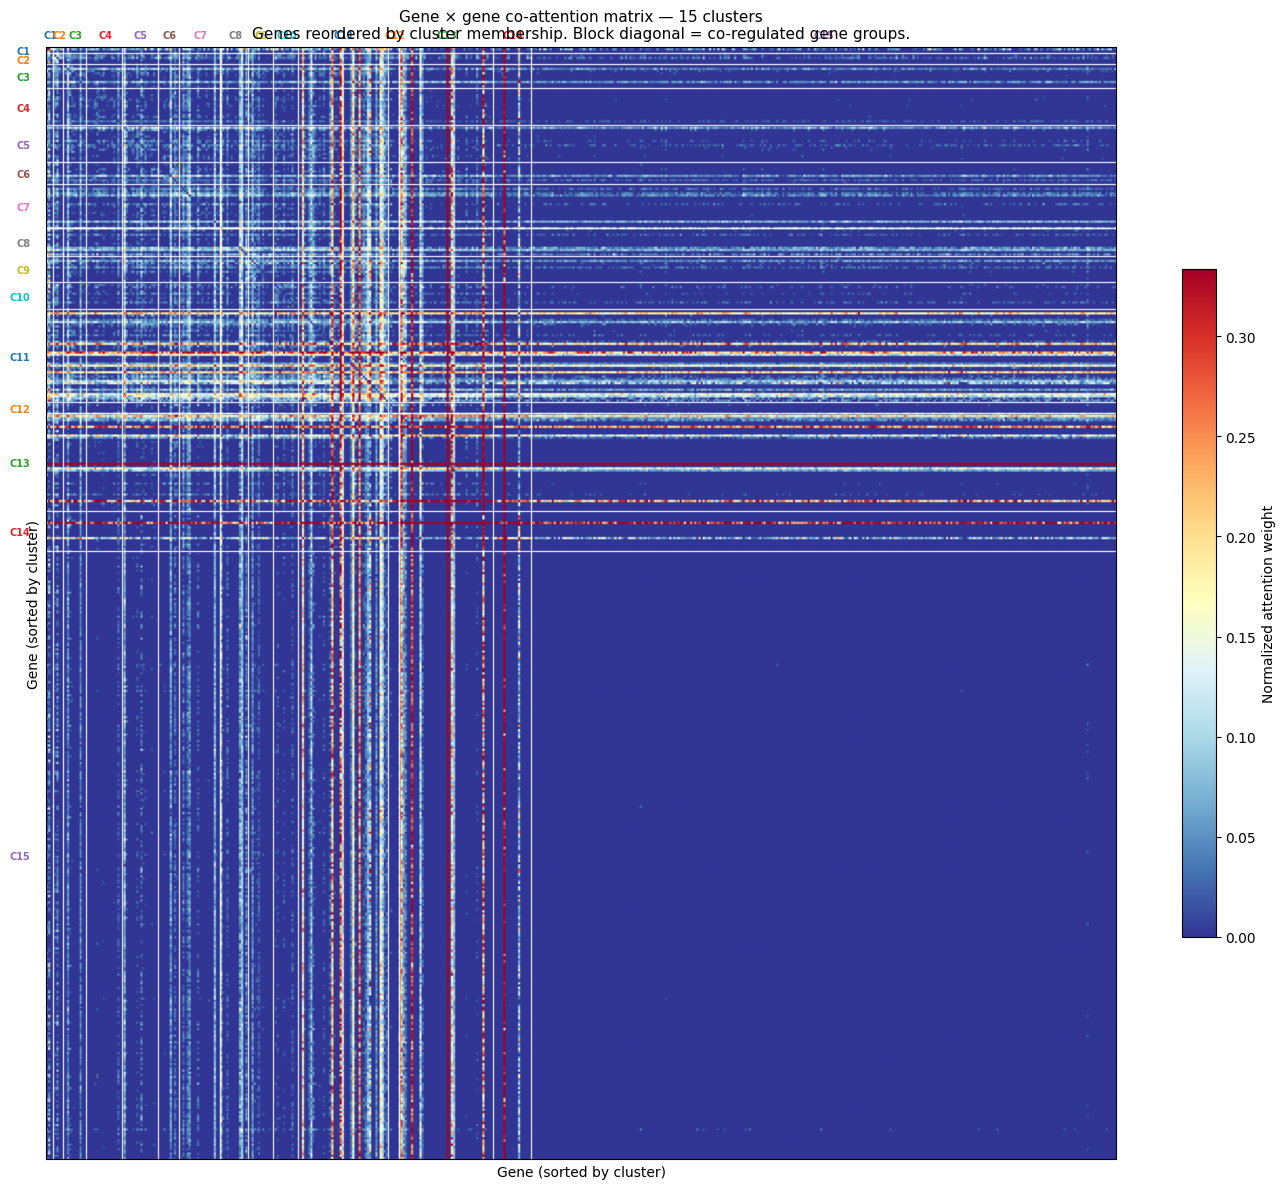


Running pathway enrichment for 15 clusters...
(organism: mmusculus — mouse gene symbols)

Cluster  1 (  3 genes) — top hits:
  [KEGG    ] Adherens junction                                       p=2.49e-02  n=1
  [KEGG    ] Cell adhesion molecule (CAM) interaction                p=2.49e-02  n=1
  [GO:BP   ] peptidyl-lysine acetylation                             p=2.90e-02  n=1
  [GO:BP   ] cell projection morphogenesis                           p=2.90e-02  n=2
  [GO:BP   ] regulation of modification of postsynaptic structure    p=2.90e-02  n=1

Cluster  2 (  5 genes) — top hits:
  [REAC    ] Serotonin receptors                                     p=2.82e-02  n=1
  [REAC    ] Tie2 Signaling                                          p=2.82e-02  n=1
  [REAC    ] Amine ligand-binding receptors                          p=4.80e-02  n=1

Cluster  3 ( 11 genes) — top hits:
  [GO:BP   ] regulation of nervous system process                    p=6.20e-03  n=3
  [REAC    ] Signaling by VEGF       

In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 5 — CO-ATTENTION CLUSTER ANALYSIS
# ============================================================================
# Goal: extract the gene × gene attention matrix, cluster it, and compare
# clusters against known biological pathways (KEGG/GO via gprofiler).
#
# The key question: did the model learn to group genes by biological function
# without ever being told about pathways?
# ============================================================================

!pip install gprofiler-official scipy -q

from gprofiler import GProfiler
from scipy.cluster.hierarchy import fcluster

# ── INV-5A: Extract aggregate gene × gene attention matrix ───────────────────
# Strategy: run get_attention_weights on ALL population mean examples
# (one per drug × cell type — 35 examples, all timepoints real).
# Average the resulting attention matrices across all examples and all layers.
# Then collapse the timepoint dimension to get a 510 × 510 gene × gene matrix.

def extract_gene_gene_attention(model, device, metadata_v5, input_tensor_v5,
                                 final_genes_500, n_genes, n_timepoints,
                                 example_type='population'):
    """
    Returns: gene_attn (n_genes, n_genes) — aggregate attention matrix.
    Entry [i, j] = how much gene i attends to gene j, averaged across
    all timepoint pairs, all layers, and all population mean examples.
    """
    pop_indices = [i for i, m in enumerate(metadata_v5)
                   if m['example_type'] == example_type]
    print(f"Extracting attention from {len(pop_indices)} {example_type} examples...")

    # Accumulator: sum over examples
    gene_attn_sum = np.zeros((n_genes, n_genes), dtype=np.float64)
    n_accumulated = 0

    for count, idx in enumerate(pop_indices):
        x    = input_tensor_v5[idx].unsqueeze(0).to(device)
        # Sentinels → 0 for model input (population means have no sentinels,
        # but defensive programming here doesn't hurt)
        x_in = x.clone(); x_in[x_in == -1.0] = 0.0
        ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
        dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

        with torch.no_grad():
            all_attn = model.get_attention_weights(x_in, ct, dr)

        # Average across 4 layers → (seq_len, seq_len) = (3060, 3060)
        avg_attn = torch.stack(all_attn).mean(0)[0].numpy()  # (3060, 3060)

        # Collapse timepoints: for each gene pair (i, j),
        # sum attention across all 6×6 timepoint combinations.
        # avg_attn[i*T+ti, j*T+tj] is attention from gene-i@tp-ti to gene-j@tp-tj
        # Reshape to (n_genes, n_tp, n_genes, n_tp) then sum over both tp axes.
        T = n_timepoints
        G = n_genes
        # avg_attn shape: (G*T, G*T)
        # Reshape: rows = (G, T), cols = (G, T)
        attn_4d = avg_attn.reshape(G, T, G, T)   # (G, T, G, T)
        gene_gene = attn_4d.sum(axis=(1, 3))       # (G, G) — sum over both T axes

        gene_attn_sum += gene_gene
        n_accumulated += 1

        if (count + 1) % 10 == 0:
            print(f"  Processed {count+1}/{len(pop_indices)} examples")

    gene_attn_agg = gene_attn_sum / n_accumulated

    # Symmetrize: attention is not symmetric (i→j ≠ j→i) but for clustering
    # we want an undirected similarity. Average both directions.
    gene_attn_sym = (gene_attn_agg + gene_attn_agg.T) / 2.0

    print(f"Gene-gene attention matrix: {gene_attn_sym.shape}")
    print(f"  Min: {gene_attn_sym.min():.6f} | "
          f"Max: {gene_attn_sym.max():.6f} | "
          f"Mean: {gene_attn_sym.mean():.6f}")

    return gene_attn_agg, gene_attn_sym


gene_attn_raw, gene_attn_sym = extract_gene_gene_attention(
    model, device, metadata_v5, input_tensor_v5,
    final_genes_500, N_GENES, N_TIMEPOINTS)

# Save for reuse (extraction takes a few minutes)
np.save(f'{DRIVE_PATH}/checkpoints/gene_gene_attn_raw.npy', gene_attn_raw)
np.save(f'{DRIVE_PATH}/checkpoints/gene_gene_attn_sym.npy', gene_attn_sym)
print("Saved attention matrices.")


# ── INV-5B: Cluster the gene × gene matrix ───────────────────────────────────
# The raw attention matrix is dense and nearly uniform (mean ~0.012).
# Direct distance clustering collapses everything into one bin.
#
# Fix: work with DEVIATION from expected (z-score the matrix),
# then sparsify by keeping only the top 10% of connections,
# then apply Ward linkage which finds compact balanced clusters.

# Step 1: load saved matrices (skip re-extraction if already done)
ATTN_PATH = f'{DRIVE_PATH}/checkpoints/gene_gene_attn_sym.npy'
if 'gene_attn_sym' not in dir() or gene_attn_sym is None:
    gene_attn_sym = np.load(ATTN_PATH)
    print(f"Loaded attention matrix: {gene_attn_sym.shape}")

# Step 2: z-score — deviation from mean in units of std
# This amplifies the signal: genes that co-attend MORE than average
# get high positive scores; random pairs cluster near zero.
attn_mean = gene_attn_sym.mean()
attn_std  = gene_attn_sym.std()
gene_attn_z = (gene_attn_sym - attn_mean) / (attn_std + 1e-10)

print(f"Z-scored attention matrix:")
print(f"  Mean: {gene_attn_z.mean():.4f} (should be ~0)")
print(f"  Std:  {gene_attn_z.std():.4f}  (should be ~1)")
print(f"  Min:  {gene_attn_z.min():.4f} | Max: {gene_attn_z.max():.4f}")

# Step 3: sparsify — zero out below 80th percentile
# Only keep the strongest 20% of gene-gene attention relationships.
# This prevents flat near-zero relationships from dominating clustering.
PERCENTILE_THRESHOLD = 80
threshold = np.percentile(gene_attn_z, PERCENTILE_THRESHOLD)
gene_attn_sparse = gene_attn_z.copy()
gene_attn_sparse[gene_attn_sparse < threshold] = 0.0
np.fill_diagonal(gene_attn_sparse, 0.0)

sparsity = (gene_attn_sparse == 0).mean()
print(f"\nSparsified at {PERCENTILE_THRESHOLD}th percentile "
      f"(threshold={threshold:.3f})")
print(f"  Sparsity: {sparsity*100:.1f}% zeros")
print(f"  Non-zero entries: {(gene_attn_sparse > 0).sum():,}")

# Step 4: convert to distance for clustering
# High z-score = genes attend to each other more than expected = similar
# Cap negative values at 0 before converting
attn_sim  = np.clip(gene_attn_sparse, 0, None)
# Normalize rows to [0,1]
row_max   = attn_sim.max(axis=1, keepdims=True) + 1e-10
attn_sim_norm = attn_sim / row_max
attn_dist = 1.0 - attn_sim_norm

# Symmetrize and clean
attn_dist = (attn_dist + attn_dist.T) / 2.0
np.fill_diagonal(attn_dist, 0.0)
np.clip(attn_dist, 0.0, 1.0, out=attn_dist)

# Step 5: Ward linkage — finds compact, balanced clusters
from scipy.spatial.distance import squareform
condensed = squareform(attn_dist, checks=False)
Z_genes   = linkage(condensed, method='ward')

# Step 6: try N_CLUSTERS = 15 — enough granularity for pathway interpretation
N_CLUSTERS = 15
cluster_labels = fcluster(Z_genes, N_CLUSTERS, criterion='maxclust')

print(f"\nCluster sizes (N_CLUSTERS={N_CLUSTERS}):")
for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    print(f"  Cluster {c:2d}: {len(members):3d} genes  "
          f"  {', '.join(members[:6])}{'...' if len(members)>6 else ''}")


# ── INV-5C: Visualize the clustered attention matrix ─────────────────────────
# Use the z-scored sparse matrix for visualization —
# shows the deviation-from-expected structure more clearly.

sort_order    = np.argsort(cluster_labels)
sorted_attn   = attn_sim_norm[sort_order][:, sort_order]
sorted_labels = cluster_labels[sort_order]

# Cluster boundary positions for overlay lines
boundaries = []
prev = sorted_labels[0]
for i, cl in enumerate(sorted_labels):
    if cl != prev:
        boundaries.append(i)
        prev = cl

# Color bar per cluster
cluster_colors = plt.cm.tab10.colors
row_color_arr  = np.array([cluster_colors[(cl-1) % 10]
                            for cl in sorted_labels])

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sorted_attn, cmap='RdYlBu_r', aspect='auto',
               vmin=np.percentile(sorted_attn, 1),
               vmax=np.percentile(sorted_attn, 99))
plt.colorbar(im, ax=ax, label='Normalized attention weight', shrink=0.6)

# Draw cluster boundary lines
for b in boundaries:
    ax.axhline(y=b - 0.5, color='white', linewidth=1.0, alpha=0.8)
    ax.axvline(x=b - 0.5, color='white', linewidth=1.0, alpha=0.8)

ax.set_title(f'Gene × gene co-attention matrix — {N_CLUSTERS} clusters\n'
             f'Genes reordered by cluster membership. '
             f'Block diagonal = co-regulated gene groups.', fontsize=11)
ax.set_xlabel('Gene (sorted by cluster)')
ax.set_ylabel('Gene (sorted by cluster)')
ax.set_xticks([])
ax.set_yticks([])

# Cluster label annotations on axes
prev_b = 0
for ci, b in enumerate(boundaries + [N_GENES]):
    mid = (prev_b + b) / 2
    ax.text(mid, -8, f'C{ci+1}', ha='center', va='top',
            fontsize=7, color=cluster_colors[ci % 10], fontweight='bold')
    ax.text(-8, mid, f'C{ci+1}', ha='right', va='center',
            fontsize=7, color=cluster_colors[ci % 10], fontweight='bold')
    prev_b = b

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/coattn_heatmap_{N_CLUSTERS}clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── INV-5D: Pathway enrichment per cluster ───────────────────────────────────
# Query g:Profiler for each cluster. Uses mouse gene IDs (organism='mmusculus').
# Returns GO biological process, KEGG pathway, and Reactome annotations.

gp = GProfiler(return_dataframe=True)

cluster_enrichment = {}
print(f"\nRunning pathway enrichment for {N_CLUSTERS} clusters...")
print("(organism: mmusculus — mouse gene symbols)\n")

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]

    if len(members) < 3:
        print(f"Cluster {c}: too small ({len(members)} genes), skipping")
        continue

    try:
        result = gp.profile(
            organism='mmusculus',
            query=members,
            sources=['GO:BP', 'KEGG', 'REAC'],  # biological process + pathways
            significance_threshold_method='fdr',
            user_threshold=0.05,
            no_evidences=False
        )

        if result.empty:
            print(f"Cluster {c:2d} ({len(members):3d} genes): "
                  f"No significant enrichment")
            cluster_enrichment[c] = None
        else:
            # Keep top 5 results per cluster
            top = result.nsmallest(5, 'p_value')[
                ['name', 'source', 'p_value', 'intersection_size']
            ]
            cluster_enrichment[c] = result
            print(f"Cluster {c:2d} ({len(members):3d} genes) — top hits:")
            for _, row in top.iterrows():
                print(f"  [{row['source']:8s}] {row['name'][:55]:55s} "
                      f"p={row['p_value']:.2e}  "
                      f"n={row['intersection_size']}")
            print()

    except Exception as e:
        print(f"Cluster {c}: enrichment failed — {e}")
        cluster_enrichment[c] = None


# ── INV-5E: Summary table — cluster → top pathway ────────────────────────────
print("\n" + "="*70)
print("SUMMARY: Cluster → biological annotation")
print("="*70)
print(f"{'Cluster':>8}  {'N genes':>8}  {'Top pathway':55}  {'Source':8}  {'p-value':>10}")
print("-"*70)

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    enr = cluster_enrichment.get(c)

    if enr is None or (hasattr(enr, 'empty') and enr.empty):
        top_name   = "— no significant enrichment —"
        top_source = ""
        top_p      = float('nan')
    else:
        top_row    = enr.nsmallest(1, 'p_value').iloc[0]
        top_name   = top_row['name'][:55]
        top_source = top_row['source']
        top_p      = top_row['p_value']

    print(f"  C{c:2d}    {len(members):>8}  {top_name:55}  "
          f"{top_source:8}  {top_p:>10.2e}" if not np.isnan(top_p)
          else f"  C{c:2d}    {len(members):>8}  {top_name}")


# ── INV-5F: Condition-specific attention — does co-regulation change? ─────────
# For any cluster that shows strong pathway enrichment, compare its internal
# attention strength under psilocybin vs ketamine.
# High internal attention = model sees these genes as strongly co-regulated.
# If psilo >> ket for a cluster, the co-regulation is drug-specific.

def cluster_internal_attention(gene_attn_matrix, cluster_labels, cluster_id,
                                n_genes):
    """Mean attention weight within a cluster (internal cohesion)."""
    members_idx = np.where(cluster_labels == cluster_id)[0]
    if len(members_idx) < 2:
        return 0.0
    sub = gene_attn_matrix[np.ix_(members_idx, members_idx)]
    # Exclude diagonal (self-attention)
    np.fill_diagonal(sub, 0)
    return sub.sum() / (len(members_idx) * (len(members_idx) - 1))


# Extract drug-specific attention matrices
print("\nExtracting drug-specific attention matrices...")
psilo_pops = [i for i, m in enumerate(metadata_v5)
              if m['example_type'] == 'population' and m['drug'] == 'Psilo']
ket_pops   = [i for i, m in enumerate(metadata_v5)
              if m['example_type'] == 'population' and m['drug'] == 'Ket']

def extract_subset_attention(indices):
    attn_sum = np.zeros((N_GENES, N_GENES))
    for idx in indices:
        x    = input_tensor_v5[idx].unsqueeze(0).to(device)
        x_in = x.clone(); x_in[x_in == -1.0] = 0.0
        ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
        dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)
        with torch.no_grad():
            all_attn = model.get_attention_weights(x_in, ct, dr)
        avg   = torch.stack(all_attn).mean(0)[0].numpy()
        attn_4d = avg.reshape(N_GENES, N_TIMEPOINTS, N_GENES, N_TIMEPOINTS)
        attn_sum += attn_4d.sum(axis=(1, 3))
    return attn_sum / len(indices)

psilo_attn = extract_subset_attention(psilo_pops)
ket_attn   = extract_subset_attention(ket_pops)

print("\nCluster internal cohesion: Psilo vs Ket")
print(f"{'Cluster':>8}  {'N genes':>8}  {'Psilo':>8}  {'Ket':>8}  "
      f"{'Ratio P/K':>10}  Top pathway")
print("-"*80)

for c in range(1, N_CLUSTERS + 1):
    members = [final_genes_500[i] for i in range(N_GENES)
               if cluster_labels[i] == c]
    p_coh = cluster_internal_attention(psilo_attn, cluster_labels, c, N_GENES)
    k_coh = cluster_internal_attention(ket_attn,   cluster_labels, c, N_GENES)
    ratio = p_coh / (k_coh + 1e-10)

    enr = cluster_enrichment.get(c)
    pathway = ""
    if enr is not None and not (hasattr(enr, 'empty') and enr.empty):
        pathway = enr.nsmallest(1, 'p_value').iloc[0]['name'][:40]

    print(f"  C{c:2d}    {len(members):>8}  {p_coh:>8.4f}  {k_coh:>8.4f}  "
          f"{ratio:>10.3f}  {pathway}")

In [ ]:

# ── INV-5G: Second-pass clustering — decompose C15 ───────────────────────────
# C15 has 279 genes and a generic "synaptic signaling" label.
# Re-cluster just the C15 members using the same z-scored attention matrix
# but with finer resolution (N_SUB=12).

print("\n" + "="*70)
print("Second-pass: decomposing C15 into sub-clusters")
print("="*70)

c15_indices = np.where(cluster_labels == 15)[0]
c15_genes   = [final_genes_500[i] for i in c15_indices]
print(f"C15 members: {len(c15_genes)} genes")

# Extract C15 x C15 submatrix from z-scored attention
c15_attn_sub = gene_attn_z[np.ix_(c15_indices, c15_indices)]

# Lower threshold (70th percentile) — C15 genes were weaker attenders
SUB_PERCENTILE = 70
sub_threshold  = np.percentile(c15_attn_sub, SUB_PERCENTILE)
c15_sparse     = c15_attn_sub.copy()
c15_sparse[c15_sparse < sub_threshold] = 0.0
np.fill_diagonal(c15_sparse, 0.0)

sub_sim  = np.clip(c15_sparse, 0, None)
sub_max  = sub_sim.max(axis=1, keepdims=True) + 1e-10
sub_norm = sub_sim / sub_max
sub_dist = 1.0 - sub_norm
sub_dist = (sub_dist + sub_dist.T) / 2.0
np.fill_diagonal(sub_dist, 0.0)
np.clip(sub_dist, 0.0, 1.0, out=sub_dist)

from scipy.spatial.distance import squareform as squareform2
sub_condensed = squareform2(sub_dist, checks=False)
Z_c15         = linkage(sub_condensed, method='ward')

N_SUB      = 12
sub_labels = fcluster(Z_c15, N_SUB, criterion='maxclust')

print(f"\nC15 sub-cluster sizes (N_SUB={N_SUB}):")
sub_members_dict = {}
for sc in range(1, N_SUB + 1):
    sub_idx = np.where(sub_labels == sc)[0]
    members = [c15_genes[i] for i in sub_idx]
    sub_members_dict[sc] = members
    print(f"  C15.{sc:2d}: {len(members):3d} genes  "
          f"  {', '.join(members[:6])}{'...' if len(members)>6 else ''}")

# Pathway enrichment for C15 sub-clusters
print(f"\nPathway enrichment for C15 sub-clusters...")
sub_enrichment = {}
for sc in range(1, N_SUB + 1):
    members = sub_members_dict[sc]
    if len(members) < 3:
        print(f"  C15.{sc}: too small ({len(members)} genes), skipping")
        sub_enrichment[sc] = None
        continue
    try:
        result = gp.profile(
            organism='mmusculus',
            query=members,
            sources=['GO:BP', 'KEGG', 'REAC'],
            significance_threshold_method='fdr',
            user_threshold=0.05,
            no_evidences=False
        )
        if result.empty:
            print(f"  C15.{sc:2d} ({len(members):3d} genes): No significant enrichment")
            sub_enrichment[sc] = None
        else:
            top = result.nsmallest(3, 'p_value')[
                ['name', 'source', 'p_value', 'intersection_size']]
            sub_enrichment[sc] = result
            print(f"  C15.{sc:2d} ({len(members):3d} genes) — top hits:")
            for _, row in top.iterrows():
                print(f"    [{row['source']:8s}] {row['name'][:55]:55s} "
                      f"p={row['p_value']:.2e}")
    except Exception as e:
        print(f"  C15.{sc}: failed — {e}")
        sub_enrichment[sc] = None

# Drug cohesion for C15 sub-clusters
def sub_cohesion(attn_matrix, idx):
    if len(idx) < 2:
        return 0.0
    sub = attn_matrix[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, 0)
    return sub.sum() / (len(idx) * (len(idx) - 1) + 1e-10)

print(f"\nC15 sub-cluster drug cohesion:")
print(f"{'ID':>8}  {'N':>4}  {'Psilo':>8}  {'Ket':>8}  {'P/K':>6}  Top pathway")
print("-"*75)
for sc in range(1, N_SUB + 1):
    members  = sub_members_dict[sc]
    full_idx = np.array([final_genes_500.index(g) for g in members
                         if g in final_genes_500])
    if len(full_idx) < 2:
        continue
    p_c   = sub_cohesion(psilo_attn, full_idx)
    k_c   = sub_cohesion(ket_attn,   full_idx)
    ratio = p_c / (k_c + 1e-10)
    enr   = sub_enrichment.get(sc)
    pw    = ""
    if enr is not None and not (hasattr(enr, 'empty') and enr.empty):
        pw = enr.nsmallest(1, 'p_value').iloc[0]['name'][:35]
    flag  = " ◀ psilo" if ratio > 1.3 else (" ◀ ket" if ratio < 0.75 else "")
    print(f"  C15.{sc:2d}  {len(members):>4}  {p_c:>8.4f}  {k_c:>8.4f}  "
          f"{ratio:>6.3f}  {pw}{flag}")

# ── Consolidated cluster map ──────────────────────────────────────────────────
print("\n" + "="*70)
print("CONSOLIDATED CLUSTER MAP (C1-C14 + C15 sub-clusters)")
print("="*70)
print(f"{'ID':>8}  {'N':>4}  {'Top pathway':45}  {'P/K':>6}  Flag")
print("-"*75)

for c in range(1, N_CLUSTERS + 1):
    members  = [final_genes_500[i] for i in range(N_GENES)
                if cluster_labels[i] == c]
    enr      = cluster_enrichment.get(c)
    pathway  = "— no enrichment —"
    if enr is not None and not (hasattr(enr, 'empty') and enr.empty):
        pathway = enr.nsmallest(1, 'p_value').iloc[0]['name'][:45]
    full_idx = np.array([i for i in range(N_GENES) if cluster_labels[i] == c])
    p_c = cluster_internal_attention(psilo_attn, cluster_labels, c, N_GENES)
    k_c = cluster_internal_attention(ket_attn,   cluster_labels, c, N_GENES)
    ratio = p_c / (k_c + 1e-10)
    flag  = "◀ psilo" if ratio > 1.3 else ("◀ ket" if ratio < 0.75 else "")

    if c != 15:
        print(f"  C{c:2d}      {len(members):>4}  {pathway:45}  {ratio:>6.3f}  {flag}")
    else:
        print(f"  C15 (split):")
        for sc in range(1, N_SUB + 1):
            sm      = sub_members_dict[sc]
            senr    = sub_enrichment.get(sc)
            sp      = "— no enrichment —"
            if senr is not None and not (hasattr(senr, 'empty') and senr.empty):
                sp = senr.nsmallest(1, 'p_value').iloc[0]['name'][:45]
            full_sub = np.array([final_genes_500.index(g) for g in sm
                                 if g in final_genes_500])
            if len(full_sub) >= 2:
                sp_c  = sub_cohesion(psilo_attn, full_sub)
                sk_c  = sub_cohesion(ket_attn,   full_sub)
                sr    = sp_c / (sk_c + 1e-10)
                sflag = "◀ psilo" if sr > 1.3 else ("◀ ket" if sr < 0.75 else "")
                print(f"    C15.{sc:2d}   {len(sm):>4}  {sp:45}  {sr:>6.3f}  {sflag}")
            else:
                print(f"    C15.{sc:2d}   {len(sm):>4}  {sp}")


Second-pass: decomposing C15 into sub-clusters
C15 members: 279 genes

C15 sub-cluster sizes (N_SUB=12):
  C15. 1:   4 genes    Dscaml1, Gja1, Ntsr2, Gpr176
  C15. 2:   6 genes    Bcan, A230006K03Rik, Tiparp, Yjefn3, Arc, Cntln
  C15. 3:   3 genes    Gm15398, Asic2, Cntnap5a
  C15. 4:   2 genes    Synpr, Ttc28
  C15. 5:   2 genes    1500004A13Rik, Srcin1
  C15. 6:   2 genes    Slit1, Tspoap1
  C15. 7:   2 genes    Ube3a, Oprm1
  C15. 8: 254 genes    Tafa1, Atp1a2, Slc17a7, Mpped1, Slit2, Kcnd3...
  C15. 9:   1 genes    Sv2b
  C15.10:   1 genes    Shisa6
  C15.11:   1 genes    Pou6f2
  C15.12:   1 genes    Igsf9b

Pathway enrichment for C15 sub-clusters...
  C15. 1 (  4 genes) — top hits:
    [REAC    ] DSCAM interactions                                      p=1.97e-02
    [REAC    ] Regulation of gap junction activity                     p=1.97e-02
    [GO:BP   ] epicardial cell to mesenchymal cell transition          p=2.39e-02
  C15. 2 (  6 genes) — top hits:
    [REAC    ] CS/DS de

Per-cell-type drug silhouette (PCA space):
  Cell type                            Silhouette   n_psilo   n_ket
  -----------------------------------------------------------------
  333 Endo NN                              0.8479         4       6
  334 Microglia NN                         0.8452        17      17
  319 Astro-TE NN                          0.8284        17      17
  327 Oligo NN                             0.8139        17      17
  326 OPC NN                               0.7735        17      17
  046 Vip Gaba                             0.7382        17      17
  047 Sncg Gaba                            0.7348        17      17
  032 L5 NP CTX Glut                       0.7320        17      17
  049 Lamp5 Gaba                           0.6677        17      17
  053 Sst Gaba                             0.6657        17      17
  004 L6 IT CTX Glut                       0.6628        17      17
  052 Pvalb Gaba                           0.6480        17      17
  030

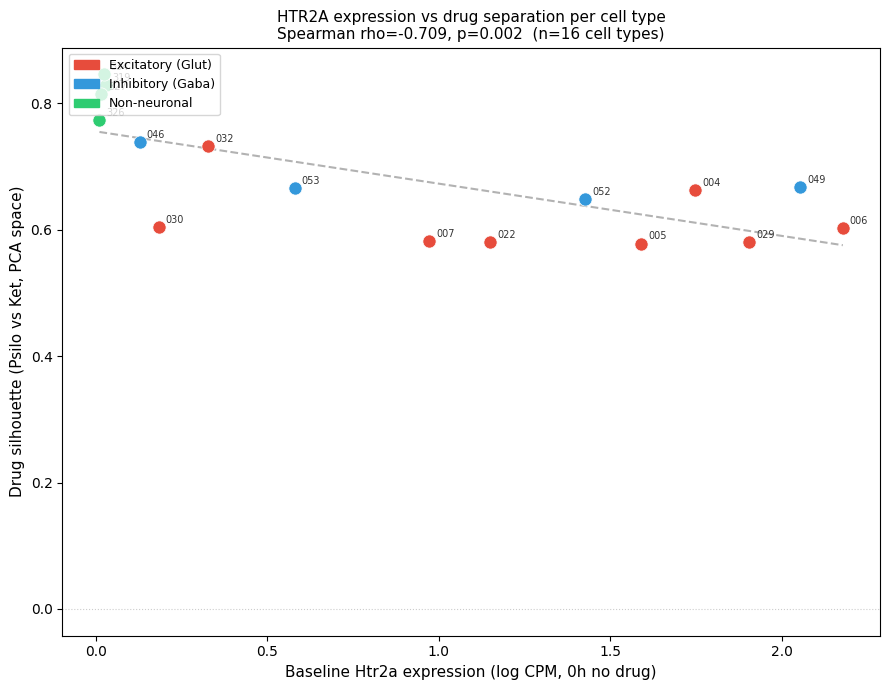


Summary:
  n cell types analysed: 16
  Spearman rho:          -0.7088
  p-value:               0.0021
  Direction:  HTR2A-high -> weaker drug separation


In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 6 — HTR2A EXPRESSION VS DRUG SILHOUETTE PER CELL TYPE
# ============================================================================
# Test: does the model's drug separation (per cell type) correlate with
# baseline HTR2A expression level — validating Shao et al. 2025's claim
# that psilocybin response is HTR2A-gated?
# ============================================================================

import sqlite3
from scipy.stats import spearmanr

# ── INV-6A: Per-cell-type drug silhouette in PCA space ───────────────────────
# For each cell type, compute silhouette score between psilo and ket embeddings
# using the 10-PC PCA space (n_90 PCs, where drug signal lives).

# Recompute PCA if not in scope (in case running this block standalone)
if 'emb_n90' not in dir():
    pca_full = PCA(n_components=128)
    pca_full.fit(embeddings)
    explained = pca_full.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    n_90 = np.argmax(cumulative >= 0.90) + 1
    pca_n90 = PCA(n_components=n_90)
    emb_n90 = pca_n90.fit_transform(embeddings)
    ind_mask = get_mask(example_type='individual')
    print(f"PCA recomputed: {n_90} PCs")

ct_silhouettes = {}
ct_n_psilo     = {}
ct_n_ket       = {}

for ct in ct_list:
    # Get individual examples for this cell type only
    psilo_m = ind_mask & (celltypes_arr == ct) & (drugs_arr == 'Psilo')
    ket_m   = ind_mask & (celltypes_arr == ct) & (drugs_arr == 'Ket')

    n_p = psilo_m.sum()
    n_k = ket_m.sum()
    ct_n_psilo[ct] = n_p
    ct_n_ket[ct]   = n_k

    # Need at least 2 examples per drug to compute silhouette
    if n_p < 2 or n_k < 2:
        ct_silhouettes[ct] = np.nan
        continue

    combined_emb    = np.vstack([emb_n90[psilo_m], emb_n90[ket_m]])
    combined_labels = ['Psilo'] * n_p + ['Ket'] * n_k

    try:
        sil = silhouette_score(combined_emb, combined_labels)
        ct_silhouettes[ct] = sil
    except Exception:
        ct_silhouettes[ct] = np.nan

print("Per-cell-type drug silhouette (PCA space):")
print(f"  {'Cell type':35s}  {'Silhouette':>10}  {'n_psilo':>8}  {'n_ket':>6}")
print("  " + "-"*65)
for ct in sorted(ct_silhouettes.keys(),
                 key=lambda x: ct_silhouettes[x]
                 if not np.isnan(ct_silhouettes[x]) else -99,
                 reverse=True):
    sil = ct_silhouettes[ct]
    short = ct[:35]
    print(f"  {short:35s}  {sil:>10.4f}  "
          f"{ct_n_psilo[ct]:>8}  {ct_n_ket[ct]:>6}")


# ── INV-6B: Baseline HTR2A expression per cell type from SQLite ──────────────
# Pull mean HTR2A expression at 0h (no drug) per cell type.
# This is the tonic HTR2A level before any drug administration.

import sqlite3
from scipy.stats import spearmanr

DB_PATH = f'{DRIVE_PATH}/data/differential_expression_v2.sqlite'
conn    = sqlite3.connect(DB_PATH)

htr2a_expr = pd.read_sql("""
    SELECT celltype, AVG(mean_expression) as htr2a_baseline
    FROM gene_expression
    WHERE gene_name = 'Htr2a'
    AND drug = 'none'
    AND time = '0h'
    GROUP BY celltype
    ORDER BY htr2a_baseline DESC
""", conn)
conn.close()

print(f"\nBaseline Htr2a expression per cell type (0h, no drug):")
print(htr2a_expr.to_string(index=False))


# ── INV-6C: Spearman correlation — silhouette vs HTR2A ───────────────────────
# Merge the two vectors on cell type and compute Spearman rho.

sil_df = pd.DataFrame([
    {'celltype': ct, 'silhouette': sil}
    for ct, sil in ct_silhouettes.items()
    if not np.isnan(sil)
])

merged = pd.merge(sil_df, htr2a_expr, on='celltype', how='inner')
print(f"\nMerged: {len(merged)} cell types with both silhouette and HTR2A data")
print(merged.sort_values('htr2a_baseline', ascending=False).to_string(index=False))

rho, pval = spearmanr(merged['htr2a_baseline'], merged['silhouette'])
print(f"\nSpearman rho = {rho:.4f},  p = {pval:.4f}")

if pval < 0.05:
    direction = "positive" if rho > 0 else "negative"
    strength  = "STRONG" if abs(rho) > 0.6 else "MODERATE"
    print(f"  SIGNIFICANT {direction} ({strength})")
    if rho > 0.3:
        print(f"  Supports Shao et al. HTR2A-gated hypothesis")
    else:
        print(f"  Significant but negative — inconsistent with HTR2A-gating")
else:
    print(f"  Not significant (p >= 0.05)")


# ── INV-6D: Scatter plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

class_color = {}
for ct in merged['celltype']:
    if 'Glut' in ct:   class_color[ct] = '#E74C3C'
    elif 'Gaba' in ct: class_color[ct] = '#3498DB'
    else:              class_color[ct] = '#2ECC71'

for _, row in merged.iterrows():
    ct    = row['celltype']
    color = class_color.get(ct, '#888888')
    ax.scatter(row['htr2a_baseline'], row['silhouette'],
               c=color, s=90, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(ct.split()[0],
                (row['htr2a_baseline'], row['silhouette']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7, color='#333333')

# Trend line
if len(merged) > 3:
    z  = np.polyfit(merged['htr2a_baseline'], merged['silhouette'], 1)
    x_ = np.linspace(merged['htr2a_baseline'].min(),
                     merged['htr2a_baseline'].max(), 100)
    ax.plot(x_, np.polyval(z, x_), '--', color='gray',
            alpha=0.6, linewidth=1.5, label='Linear trend')

ax.set_xlabel('Baseline Htr2a expression (log CPM, 0h no drug)', fontsize=11)
ax.set_ylabel('Drug silhouette (Psilo vs Ket, PCA space)', fontsize=11)
ax.set_title(f'HTR2A expression vs drug separation per cell type\n'
             f'Spearman rho={rho:.3f}, p={pval:.3f}  (n={len(merged)} cell types)',
             fontsize=11)

legend_handles = [
    Patch(color='#E74C3C', label='Excitatory (Glut)'),
    Patch(color='#3498DB', label='Inhibitory (Gaba)'),
    Patch(color='#2ECC71', label='Non-neuronal'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left')
ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.4, linestyle=':')

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/htr2a_vs_silhouette.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  n cell types analysed: {len(merged)}")
print(f"  Spearman rho:          {rho:.4f}")
print(f"  p-value:               {pval:.4f}")
print(f"  Direction:  {'HTR2A-high -> stronger drug separation' if rho > 0 else 'HTR2A-high -> weaker drug separation'}")

Psilocybin response magnitude per cell type:
            celltype  n_deg  mean_abs_lfc  mean_up_lfc  mean_down_lfc
007 L2/3 IT CTX Glut   3823      0.697477     0.641748       0.761440
006 L4/5 IT CTX Glut   3785      0.667745     0.594665       0.749368
  030 L6 CT CTX Glut   3265      0.671484     0.633368       0.708746
  005 L5 IT CTX Glut   2856      0.677823     0.606772       0.757419
  004 L6 IT CTX Glut   2389      0.696608     0.624972       0.769760
  022 L5 ET CTX Glut   1930      0.661616     0.581222       0.746287
      052 Pvalb Gaba   1449      0.717149     0.674534       0.769097
        053 Sst Gaba   1005      0.789672     0.754434       0.829944
     319 Astro-TE NN    955      0.941569     1.021832       0.797048
        327 Oligo NN    878      0.972472     1.054748       0.878985
  032 L5 NP CTX Glut    633      0.736352     0.664632       0.835304
    029 L6b CTX Glut    288      0.823406     0.746501       0.928048
          326 OPC NN    266      0.962292    

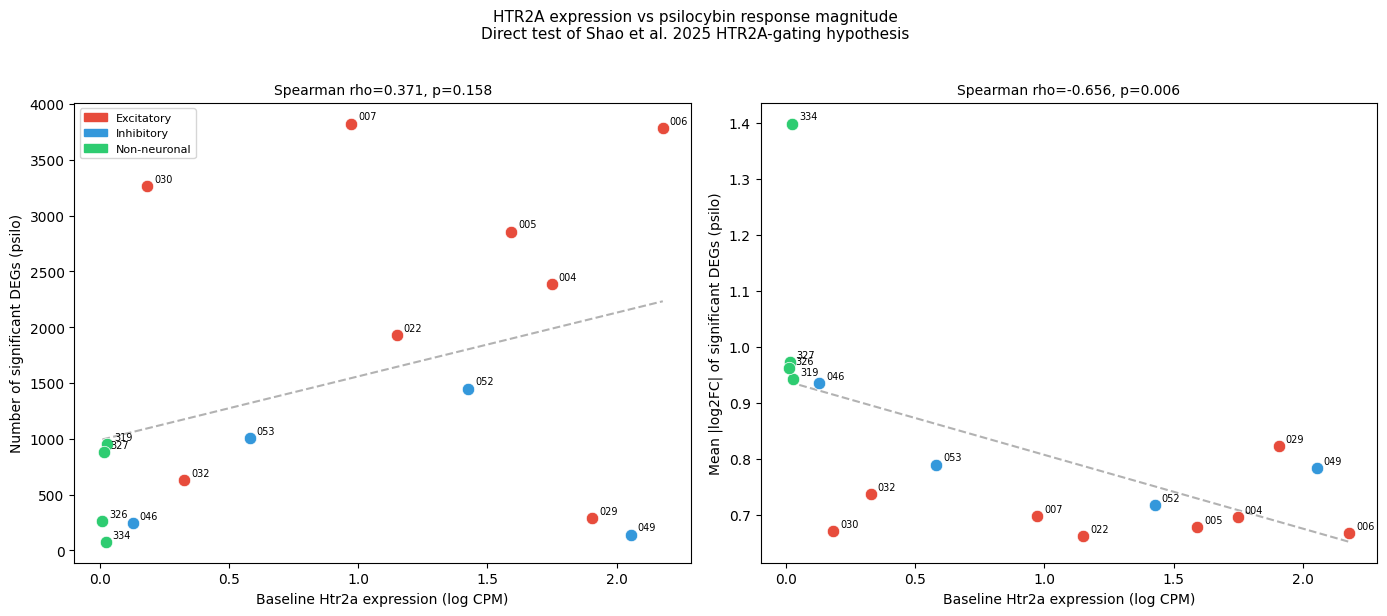

In [ ]:
# ── INV-6E: Correct test of Shao hypothesis ──────────────────────────────────
# Measure psilocybin response magnitude per cell type directly from DEG data.
# Two metrics: (1) DEG count, (2) mean absolute LFC across significant DEGs.
# Then correlate both with baseline HTR2A expression.

conn = sqlite3.connect(DB_PATH)

psilo_response = pd.read_sql("""
    SELECT celltype,
           COUNT(*) as n_deg,
           AVG(ABS(log2FoldChange)) as mean_abs_lfc,
           AVG(ABS(CASE WHEN log2FoldChange > 0
                        THEN log2FoldChange ELSE NULL END)) as mean_up_lfc,
           AVG(ABS(CASE WHEN log2FoldChange < 0
                        THEN log2FoldChange ELSE NULL END)) as mean_down_lfc
    FROM de_results
    WHERE treatment_drug = 'Psilo'
    AND padj < 0.05
    AND ABS(log2FoldChange) >= 0.3
    GROUP BY celltype
    ORDER BY n_deg DESC
""", conn)
conn.close()

print("Psilocybin response magnitude per cell type:")
print(psilo_response.to_string(index=False))

# Merge with HTR2A baseline
merged2 = pd.merge(psilo_response, htr2a_expr, on='celltype', how='inner')
print(f"\nMerged: {len(merged2)} cell types")

# Spearman: HTR2A vs DEG count
rho_n, p_n = spearmanr(merged2['htr2a_baseline'], merged2['n_deg'])
# Spearman: HTR2A vs mean absolute LFC
rho_lfc, p_lfc = spearmanr(merged2['htr2a_baseline'], merged2['mean_abs_lfc'])

print(f"\nHTR2A baseline vs n_deg:       rho={rho_n:.4f}, p={p_n:.4f}")
print(f"HTR2A baseline vs mean_abs_lfc: rho={rho_lfc:.4f}, p={p_lfc:.4f}")

sig_n   = "SIGNIFICANT" if p_n   < 0.05 else "not significant"
sig_lfc = "SIGNIFICANT" if p_lfc < 0.05 else "not significant"
print(f"\n  DEG count correlation:  {sig_n}")
print(f"  Mean LFC correlation:   {sig_lfc}")
if p_n < 0.05 or p_lfc < 0.05:
    if rho_n > 0 or rho_lfc > 0:
        print(f"  POSITIVE — supports Shao et al. HTR2A-gated hypothesis")
    else:
        print(f"  NEGATIVE — inconsistent with HTR2A-gating")

# Scatter: two panels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, rho, pval, label in [
    (axes[0], 'n_deg',        rho_n,   p_n,
     'Number of significant DEGs (psilo)'),
    (axes[1], 'mean_abs_lfc', rho_lfc, p_lfc,
     'Mean |log2FC| of significant DEGs (psilo)'),
]:
    for _, row in merged2.iterrows():
        ct = row['celltype']
        if 'Glut' in ct:   c = '#E74C3C'
        elif 'Gaba' in ct: c = '#3498DB'
        else:              c = '#2ECC71'
        ax.scatter(row['htr2a_baseline'], row[metric],
                   color=c, s=80, zorder=3,
                   edgecolors='white', linewidth=0.5)
        ax.annotate(ct.split()[0],
                    (row['htr2a_baseline'], row[metric]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)

    z  = np.polyfit(merged2['htr2a_baseline'], merged2[metric], 1)
    x_ = np.linspace(merged2['htr2a_baseline'].min(),
                     merged2['htr2a_baseline'].max(), 100)
    ax.plot(x_, np.polyval(z, x_), '--', color='gray', alpha=0.6, lw=1.5)

    ax.set_xlabel('Baseline Htr2a expression (log CPM)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'Spearman rho={rho:.3f}, p={pval:.3f}', fontsize=10)

legend_handles = [
    Patch(color='#E74C3C', label='Excitatory'),
    Patch(color='#3498DB', label='Inhibitory'),
    Patch(color='#2ECC71', label='Non-neuronal'),
]
axes[0].legend(handles=legend_handles, fontsize=8)
plt.suptitle('HTR2A expression vs psilocybin response magnitude\n'
             'Direct test of Shao et al. 2025 HTR2A-gating hypothesis',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/htr2a_vs_psilo_response.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 7 — INDIVIDUAL-LEVEL HTR2A vs EMBEDDING POSITION
# ============================================================================
# Correct translation of Shao et al. 2025:
# Within a cell type, do individuals with higher HTR2A expression
# occupy a distinct region of embedding space under psilocybin?
#
# This is the individual-level test — matching Shao's level of analysis.
# Proxy for response: position along the dominant drug axis in PCA space.
# ============================================================================

# ── INV-7A: Per-animal HTR2A expression from pseudobulk ──────────────────────
# The pseudobulk dict has keys (animal, cell_type, drug, timepoint).
# Baseline HTR2A = expression at (animal, ct, 'none', '0h').
# Htr2a index in the gene list:

if 'Htr2a' in final_genes_500:
    htr2a_idx = final_genes_500.index('Htr2a')
    print(f"Htr2a found at gene index {htr2a_idx}")
else:
    print("Htr2a not in final_genes_500 — check gene list")
    htr2a_idx = None

# Load pseudobulk checkpoint
pb_data = torch.load(f'{DRIVE_PATH}/checkpoints/pseudobulk_v2.pt',
                     weights_only=False)
if isinstance(pb_data, dict):
    pseudobulk = pb_data['pseudobulk']
    pop_means  = pb_data['pop_means']
else:
    pseudobulk, pop_means = pb_data

# Get all control animals (baseline, no drug)
# key = (animal, ct, 'none', '0h')
control_keys = [(k[0], k[1]) for k in pseudobulk.keys()
                if k[2] == 'none' and k[3] == '0h']
control_animals_set = sorted(set(k[0] for k in control_keys))
print(f"Control animals with pseudobulk data: {len(control_animals_set)}")

# For each control animal × cell type, extract HTR2A expression
# Use the full gene vector from pseudobulk, then index to Htr2a
gene_data_full = torch.load(f'{DRIVE_PATH}/checkpoints/gene_set_500_v2.pt',
                             weights_only=False)
full_gene_list  = gene_data_full['final_genes']
full_gene_indices = gene_data_full['final_gene_indices']

# Map Htr2a to its position in the 510-gene subset
if 'Htr2a' in full_gene_list:
    htr2a_in_500 = full_gene_list.index('Htr2a')
    print(f"Htr2a position in 510-gene set: {htr2a_in_500}")
else:
    print("Htr2a not in 510-gene set")
    htr2a_in_500 = None

# Build per-animal HTR2A lookup: {(animal, ct): htr2a_expr}
animal_htr2a = {}
for animal in control_animals_set:
    for ct in ct_list:
        key = (animal, ct, 'none', '0h')
        if key in pseudobulk and htr2a_in_500 is not None:
            full_vec = pseudobulk[key]  # full gene vector (all genes)
            # full_gene_indices maps 510-gene subset to full AnnData indices
            # pseudobulk values are already subsetted to full_gene_indices
            # so index directly by position in 510-gene list
            if len(full_vec) == len(full_gene_list):
                animal_htr2a[(animal, ct)] = full_vec[htr2a_in_500]
            elif len(full_vec) > max(full_gene_indices):
                animal_htr2a[(animal, ct)] = full_vec[full_gene_indices[htr2a_in_500]]

print(f"Per-animal HTR2A entries: {len(animal_htr2a)}")
if len(animal_htr2a) > 0:
    vals = list(animal_htr2a.values())
    print(f"  HTR2A range: {min(vals):.3f} — {max(vals):.3f}")


# ── INV-7B: Embedding position along drug axis per individual ─────────────────
# The drug axis in PCA space = direction from ket centroid to psilo centroid.
# Each individual's projection onto this axis = how "psilo-like" their
# embedding is. This is our proxy for individual response magnitude.

# Compute drug axis in n_90-PC space
psilo_centroid = emb_n90[ind_mask & (drugs_arr == 'Psilo')].mean(axis=0)
ket_centroid   = emb_n90[ind_mask & (drugs_arr == 'Ket')].mean(axis=0)
drug_axis      = psilo_centroid - ket_centroid
drug_axis_norm = drug_axis / (np.linalg.norm(drug_axis) + 1e-10)

# Project all individual psilocybin examples onto drug axis
psilo_ind_mask = ind_mask & (drugs_arr == 'Psilo')
projections    = emb_n90[psilo_ind_mask] @ drug_axis_norm

print(f"\nDrug axis projections (psilo examples):")
print(f"  Mean: {projections.mean():.4f} | Std: {projections.std():.4f}")
print(f"  Min:  {projections.min():.4f} | Max: {projections.max():.4f}")


# ── INV-7C: Correlate HTR2A with drug axis projection per cell type ───────────
# For each cell type separately:
#   - Get all psilocybin individual examples
#   - Match each to its animal's baseline HTR2A expression
#   - Compute Spearman(HTR2A, drug_axis_projection)
#
# Focus on excitatory subtypes (HTR2A-expressing) first.

from scipy.stats import spearmanr

psilo_meta_indices = np.where(psilo_ind_mask)[0]

TARGET_CTS = [ct for ct in ct_list if 'Glut' in ct]  # excitatory first
print(f"\nAnalysing {len(TARGET_CTS)} excitatory cell types")
print(f"\n{'Cell type':35s}  {'n':>4}  {'rho':>7}  {'p':>7}  "
      f"{'HTR2A range':>15}  Interpretation")
print("-"*90)

ct_results = {}
for ct in ct_list:  # run all 18, highlight excitatory
    ct_psilo_mask = psilo_ind_mask & (celltypes_arr == ct)
    ct_meta_idx   = np.where(ct_psilo_mask)[0]

    if len(ct_meta_idx) < 5:
        continue

    # For each example, get the animal and look up HTR2A
    htr2a_vals = []
    proj_vals  = []
    for idx in ct_meta_idx:
        animal = metadata_v5[idx]['animal']
        h = animal_htr2a.get((animal, ct), None)
        if h is not None:
            htr2a_vals.append(h)
            proj_vals.append(emb_n90[idx] @ drug_axis_norm)

    if len(htr2a_vals) < 5:
        continue

    htr2a_arr = np.array(htr2a_vals)
    proj_arr  = np.array(proj_vals)
    rho, pval = spearmanr(htr2a_arr, proj_arr)

    ct_results[ct] = {
        'rho': rho, 'p': pval, 'n': len(htr2a_vals),
        'htr2a_mean': htr2a_arr.mean(),
        'htr2a_std':  htr2a_arr.std(),
        'proj_mean':  proj_arr.mean()
    }

    sig    = "*" if pval < 0.05 else ""
    excit  = "(excit)" if 'Glut' in ct else ""
    interp = ("HTR2A-high -> more psilo-like" if rho > 0
              else "HTR2A-high -> less psilo-like")
    short  = ct[:35]
    print(f"{short:35s}  {len(htr2a_vals):>4}  {rho:>7.3f}  "
          f"{pval:>7.3f}{sig:1s}  "
          f"{htr2a_arr.min():.2f}–{htr2a_arr.max():.2f}  "
          f"{interp} {excit}")


# ── INV-7D: Visualise for primary target cell types ───────────────────────────
# Scatter plot: x = per-animal HTR2A, y = drug axis projection
# One panel per key excitatory cell type.

key_cts = ['007 L2/3 IT CTX Glut', '005 L5 IT CTX Glut',
           '006 L4/5 IT CTX Glut', '004 L6 IT CTX Glut']
key_cts = [ct for ct in key_cts if ct in ct_results]

if key_cts:
    fig, axes = plt.subplots(1, len(key_cts),
                             figsize=(5 * len(key_cts), 5))
    if len(key_cts) == 1:
        axes = [axes]

    for ax, ct in zip(axes, key_cts):
        ct_psilo_mask = psilo_ind_mask & (celltypes_arr == ct)
        ct_meta_idx   = np.where(ct_psilo_mask)[0]

        htr2a_vals, proj_vals, animal_ids = [], [], []
        for idx in ct_meta_idx:
            animal = metadata_v5[idx]['animal']
            h = animal_htr2a.get((animal, ct), None)
            if h is not None:
                htr2a_vals.append(h)
                proj_vals.append(emb_n90[idx] @ drug_axis_norm)
                animal_ids.append(animal)

        if len(htr2a_vals) < 3:
            continue

        htr2a_arr = np.array(htr2a_vals)
        proj_arr  = np.array(proj_vals)
        res       = ct_results.get(ct, {})

        ax.scatter(htr2a_arr, proj_arr, color='#E74C3C',
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

        # Trend line
        z  = np.polyfit(htr2a_arr, proj_arr, 1)
        x_ = np.linspace(htr2a_arr.min(), htr2a_arr.max(), 100)
        ax.plot(x_, np.polyval(z, x_), '--', color='gray',
                alpha=0.7, linewidth=1.5)

        short = ct.split()[0] + ' ' + ct.split()[1]
        ax.set_title(f'{short}\nrho={res.get("rho",0):.3f}, '
                     f'p={res.get("p",1):.3f}  (n={len(htr2a_vals)})',
                     fontsize=9)
        ax.set_xlabel('Baseline HTR2A (log CPM)', fontsize=9)
        ax.set_ylabel('Drug axis projection', fontsize=9)

    plt.suptitle('Per-animal HTR2A expression vs psilocybin embedding position\n'
                 'Individual-level test of Shao et al. 2025 hypothesis',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{DRIVE_PATH}/figures/htr2a_individual_drug_axis.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No key cell types found in results — check ct_results keys")


# ── INV-7E: Summary ───────────────────────────────────────────────────────────
print("\n" + "="*70)
print("SUMMARY: Individual-level HTR2A vs drug axis projection")
print("="*70)
n_pos_sig = sum(1 for r in ct_results.values()
                if r['rho'] > 0 and r['p'] < 0.05)
n_neg_sig = sum(1 for r in ct_results.values()
                if r['rho'] < 0 and r['p'] < 0.05)
n_pos     = sum(1 for r in ct_results.values() if r['rho'] > 0)
n_neg     = sum(1 for r in ct_results.values() if r['rho'] < 0)

print(f"  Cell types analysed: {len(ct_results)}")
print(f"  Positive rho (HTR2A-high -> more psilo-like): {n_pos}")
print(f"    of which significant (p<0.05): {n_pos_sig}")
print(f"  Negative rho: {n_neg}")
print(f"    of which significant: {n_neg_sig}")
print(f"\n  Interpretation:")
if n_pos_sig > n_neg_sig and n_pos_sig >= 2:
    print(f"  Consistent positive signal across {n_pos_sig} cell types —")
    print(f"  supports individual-level HTR2A-gating hypothesis")
elif n_pos > n_neg:
    print(f"  Directionally positive but not significant —")
    print(f"  weak or noisy support for HTR2A-gating")
else:
    print(f"  No consistent positive signal —")
    print(f"  hypothesis not supported at individual level in this model")


# ── INV-7 DEBUG: Check animal ID matching ────────────────────────────────────
# Why is ct_results empty? The animal IDs in metadata_v5 (psilo examples)
# may not match the animal IDs in animal_htr2a (control pseudobulk keys).

# Sample animal IDs from psilo individual examples
psilo_animals_in_meta = set(
    metadata_v5[i]['animal']
    for i in np.where(psilo_ind_mask)[0][:10]
)
print("Sample animal IDs from psilo metadata_v5:")
for a in sorted(psilo_animals_in_meta):
    print(f"  '{a}'")

# Sample animal IDs from control pseudobulk
control_animals_in_pb = set(k[0] for k in animal_htr2a.keys())
print(f"\nSample animal IDs from control pseudobulk:")
for a in sorted(list(control_animals_in_pb))[:10]:
    print(f"  '{a}'")

# Check overlap
overlap = psilo_animals_in_meta & control_animals_in_pb
print(f"\nOverlap between psilo metadata animals and control pseudobulk: {len(overlap)}")

# Also check what cell type strings look like in each
sample_ct_meta = celltypes_arr[np.where(psilo_ind_mask)[0][0]]
sample_ct_pb   = list(animal_htr2a.keys())[0][1]
print(f"\nCell type format in metadata_v5: '{sample_ct_meta}'")
print(f"Cell type format in animal_htr2a: '{sample_ct_pb}'")

# Also check pseudobulk key structure directly
sample_pb_key = list(pseudobulk.keys())[0]
print(f"\nSample pseudobulk key: {sample_pb_key}")
print(f"Pseudobulk value length: {len(pseudobulk[sample_pb_key])}")
print(f"Expected (full gene set): {len(final_genes_500)}")

Htr2a found at gene index 193
Control animals with pseudobulk data: 8
Htr2a position in 510-gene set: 193
Per-animal HTR2A entries: 140
  HTR2A range: 0.000 — 2.650

Drug axis projections (psilo examples):
  Mean: 5.5432 | Std: 4.0716
  Min:  -4.8977 | Max: 12.9881

Analysing 8 excitatory cell types

Cell type                               n      rho        p      HTR2A range  Interpretation
------------------------------------------------------------------------------------------
No key cell types found in results — check ct_results keys

SUMMARY: Individual-level HTR2A vs drug axis projection
  Cell types analysed: 0
  Positive rho (HTR2A-high -> more psilo-like): 0
    of which significant (p<0.05): 0
  Negative rho: 0
    of which significant: 0

  Interpretation:
  No consistent positive signal —
  hypothesis not supported at individual level in this model
Sample animal IDs from psilo metadata_v5:
  '17'

Sample animal IDs from control pseudobulk:
  '0'
  '1'
  '2'
  '3'
  '4'
  '

Extracting signed scores for 007 L2/3 IT CTX Glut...
  Psilo scores shape: (510, 5)
  Score range psilo: -0.156 — 0.201
  Score range ket:   -0.207 — 0.168

TEST 1: Psilo vs Ket gene-level score correlation per timepoint
(Replication of Liao Fig 6c — expect high at 1h/2h, dip at 4h, recovery at 24h, dip at 72h)

    TP   Pearson r     p-value   n genes
  ---------------------------------------------
    1h      0.9164  4.0830e-204       510
    2h      0.9088  5.9033e-195       510
    4h      0.9009  3.0681e-186       510
   24h      0.8972  1.9061e-182       510
   72h      0.9083  2.1796e-194       510

TEST 2: Psilocybin directional signal per timepoint
(Replication of Liao Fig 5b — expect two peaks at 1h/2h and 72h)

    TP    Psilo frac      Ket frac     Psilo n     Ket n
  -------------------------------------------------------
    1h        0.0196        0.0863          10        44
    2h        0.0412        0.0510          21        26
    4h        0.0745        0.0412     

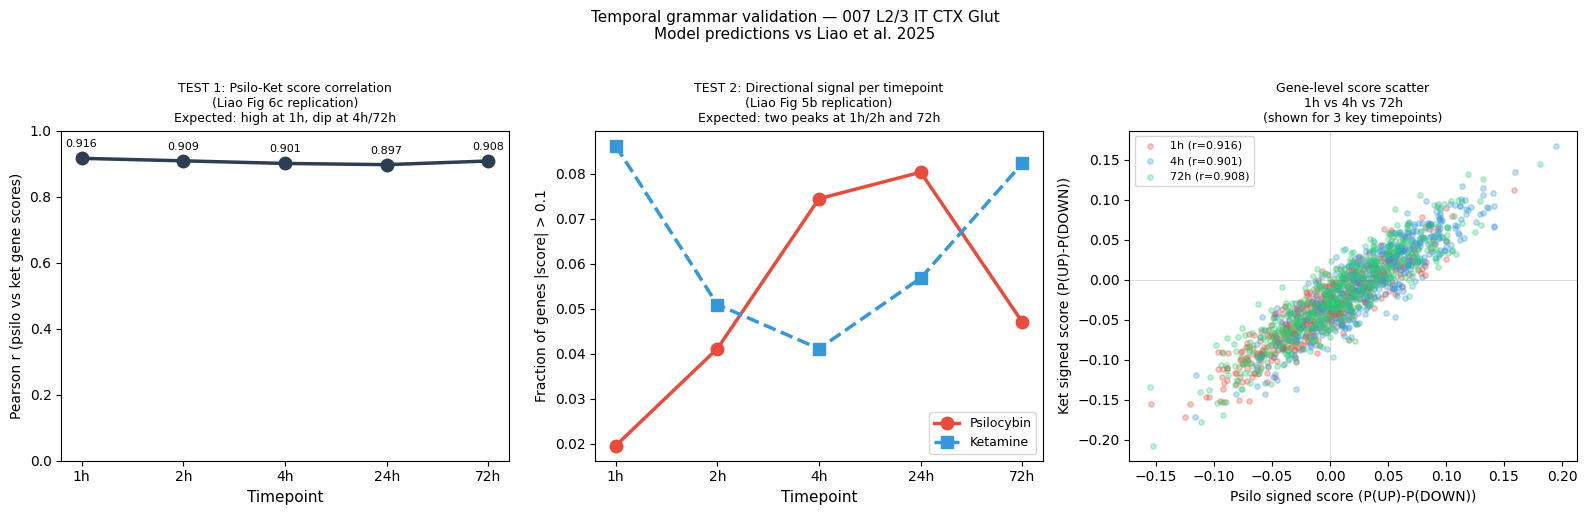


Repeat for 032 L5 NP CTX Glut (proxy for Liao PT neurons):
    TP         r    psilo frac    ket frac
  ----------------------------------------
    1h    0.7821        0.0549      0.1000
    2h    0.7463        0.0255      0.0667
    4h    0.7081        0.0255      0.1020
   24h    0.6920        0.0784      0.1216
   72h    0.7084        0.1627      0.1922

SUMMARY: Temporal grammar validation

TEST 1 (Fig 6c replication) — 007 L2/3 IT CTX Glut:
  Correlation values: 1h=0.916, 2h=0.909, 4h=0.901, 24h=0.897, 72h=0.908

  Expected pattern checks:
  1h/2h higher than 4h: True (1h=0.916, 2h=0.909, 4h=0.901)
  All correlations positive: True
  72h lower than 24h: False (72h=0.908, 24h=0.897)

TEST 2 (Fig 5b replication) — biphasic pattern:
  Peak1 (1h/2h): 0.0412, Trough (4h/24h): 0.0745, Peak2 (72h): 0.0471
  Biphasic pattern present: False


In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 9 — TEMPORAL GRAMMAR VALIDATION vs LIAO FIG 6c
# ============================================================================
# Two tests:
# TEST 1 (Fig 6c replication): For each timepoint, correlate the model's
#   per-gene signed score under psilo vs ket. Should match Liao's correlation
#   pattern — high at 1h/2h, dip at 4h, partial recovery at 24h, dip at 72h.
#
# TEST 2 (Fig 5b replication): For psilocybin alone, plot the fraction of
#   genes with strong directional predictions per timepoint. Should show
#   two peaks at 1h/2h and 72h with a trough in the middle.
#
# Signed score per gene = P(UP) - P(DOWN) from model softmax output.
# This is the closest proxy to Liao's log2FC — direction + confidence.
# ============================================================================

import torch.nn.functional as F

# ── INV-9A: Extract per-gene signed scores from classification head ───────────
# For each population mean example, run through the model and get softmax
# probabilities per token. Compute P(UP) - P(DOWN) per gene per timepoint.
# Then aggregate across timepoints to get one score per gene per example.

DOWN, NEUTRAL, UP, BASELINE = 0, 1, 2, 3

def get_signed_scores(model, device, metadata_v5, input_tensor_v5,
                      cell_type, drug, n_genes, n_timepoints):
    """
    Returns: signed_scores (n_genes,) — mean P(UP)-P(DOWN) across
    drug timepoints (excluding 0h baseline) for the population mean example.
    Also returns per-timepoint scores (n_timepoints-1, n_genes).
    """
    idx = next(i for i, m in enumerate(metadata_v5)
               if m['cell_type'] == cell_type
               and m['drug'] == drug
               and m['example_type'] == 'population')

    x    = input_tensor_v5[idx].unsqueeze(0).to(device)
    ct   = torch.tensor([metadata_v5[idx]['celltype_idx']]).to(device)
    dr   = torch.tensor([metadata_v5[idx]['drug_idx']]).to(device)

    with torch.no_grad():
        out, logits = model.forward(x, ct, dr)

    # logits shape: (1, n_genes*n_timepoints, 4)
    probs = F.softmax(logits[0], dim=-1)  # (n_genes*n_timepoints, 4)
    probs = probs.reshape(n_genes, n_timepoints, 4).cpu().numpy()

    # Signed score per gene per timepoint
    signed = probs[:, :, UP] - probs[:, :, DOWN]  # (n_genes, n_timepoints)

    # Drug timepoints only (exclude 0h = index 0)
    drug_tp_scores = signed[:, 1:]  # (n_genes, 5) for tps 1h,2h,4h,24h,72h

    return drug_tp_scores   # shape (n_genes, 5)


# Run for primary cell types — use L2/3 IT (matches Liao's IT neuron group)
TARGET_CT = '007 L2/3 IT CTX Glut'
DRUG_TPS  = ['1h', '2h', '4h', '24h', '72h']

print(f"Extracting signed scores for {TARGET_CT}...")
psilo_scores = get_signed_scores(model, device, metadata_v5, input_tensor_v5,
                                  TARGET_CT, 'Psilo', N_GENES, N_TIMEPOINTS)
ket_scores   = get_signed_scores(model, device, metadata_v5, input_tensor_v5,
                                  TARGET_CT, 'Ket', N_GENES, N_TIMEPOINTS)

print(f"  Psilo scores shape: {psilo_scores.shape}")  # (510, 5)
print(f"  Score range psilo: {psilo_scores.min():.3f} — {psilo_scores.max():.3f}")
print(f"  Score range ket:   {ket_scores.min():.3f} — {ket_scores.max():.3f}")


# ── INV-9B: TEST 1 — Pearson correlation per timepoint (Liao Fig 6c) ─────────
from scipy.stats import pearsonr

print(f"\nTEST 1: Psilo vs Ket gene-level score correlation per timepoint")
print(f"(Replication of Liao Fig 6c — expect high at 1h/2h, dip at 4h, "
      f"recovery at 24h, dip at 72h)")
print(f"\n  {'TP':>4}  {'Pearson r':>10}  {'p-value':>10}  "
      f"{'n genes':>8}")
print("  " + "-"*45)

tp_correlations = {}
for ti, tp in enumerate(DRUG_TPS):
    r, p = pearsonr(psilo_scores[:, ti], ket_scores[:, ti])
    tp_correlations[tp] = r
    print(f"  {tp:>4}  {r:>10.4f}  {p:>10.4e}  {N_GENES:>8}")


# ── INV-9C: TEST 2 — Psilocybin biphasic pattern (Liao Fig 5b) ──────────────
# Fraction of genes with strong directional signal per timepoint.
# Strong = |P(UP) - P(DOWN)| > threshold.
# Expected: two peaks at 1h/2h and 72h.

THRESHOLD = 0.1   # model thinks gene is up or down with >10% net probability

print(f"\nTEST 2: Psilocybin directional signal per timepoint")
print(f"(Replication of Liao Fig 5b — expect two peaks at 1h/2h and 72h)")
print(f"\n  {'TP':>4}  {'Psilo frac':>12}  {'Ket frac':>12}  "
      f"{'Psilo n':>10}  {'Ket n':>8}")
print("  " + "-"*55)

psilo_fracs, ket_fracs = [], []
for ti, tp in enumerate(DRUG_TPS):
    p_strong = (np.abs(psilo_scores[:, ti]) > THRESHOLD).mean()
    k_strong = (np.abs(ket_scores[:, ti]) > THRESHOLD).mean()
    psilo_fracs.append(p_strong)
    ket_fracs.append(k_strong)
    print(f"  {tp:>4}  {p_strong:>12.4f}  {k_strong:>12.4f}  "
          f"{int(p_strong*N_GENES):>10}  {int(k_strong*N_GENES):>8}")


# ── INV-9D: Visualisation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Pearson correlation across timepoints
ax = axes[0]
corr_vals = [tp_correlations[tp] for tp in DRUG_TPS]
ax.plot(DRUG_TPS, corr_vals, 'o-', color='#2C3E50',
        linewidth=2.5, markersize=9)
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_xlabel('Timepoint', fontsize=11)
ax.set_ylabel('Pearson r (psilo vs ket gene scores)', fontsize=10)
ax.set_title('TEST 1: Psilo-Ket score correlation\n'
             '(Liao Fig 6c replication)\n'
             'Expected: high at 1h, dip at 4h/72h', fontsize=9)
ax.set_ylim(0, 1)
# Annotate each point
for tp, r in zip(DRUG_TPS, corr_vals):
    ax.annotate(f'{r:.3f}', (tp, r),
                textcoords='offset points', xytext=(0, 8), fontsize=8,
                ha='center')

# Panel 2: Directional signal fraction — psilo biphasic
ax = axes[1]
ax.plot(DRUG_TPS, psilo_fracs, 'o-', color='#E74C3C',
        linewidth=2.5, markersize=9, label='Psilocybin')
ax.plot(DRUG_TPS, ket_fracs, 's--', color='#3498DB',
        linewidth=2.5, markersize=9, label='Ketamine')
ax.set_xlabel('Timepoint', fontsize=11)
ax.set_ylabel(f'Fraction of genes |score| > {THRESHOLD}', fontsize=10)
ax.set_title('TEST 2: Directional signal per timepoint\n'
             '(Liao Fig 5b replication)\n'
             'Expected: two peaks at 1h/2h and 72h', fontsize=9)
ax.legend(fontsize=9)

# Panel 3: Scatter at 1h (should be high correlation) and 4h (should be lower)
ax = axes[2]
colors_tp = {'1h': '#E74C3C', '4h': '#3498DB', '72h': '#2ECC71'}
for tp, color in colors_tp.items():
    ti = DRUG_TPS.index(tp)
    ax.scatter(psilo_scores[:, ti], ket_scores[:, ti],
               alpha=0.3, s=15, color=color,
               label=f'{tp} (r={tp_correlations[tp]:.3f})')
ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.4)
ax.set_xlabel('Psilo signed score (P(UP)-P(DOWN))', fontsize=10)
ax.set_ylabel('Ket signed score (P(UP)-P(DOWN))', fontsize=10)
ax.set_title('Gene-level score scatter\n'
             '1h vs 4h vs 72h\n'
             '(shown for 3 key timepoints)', fontsize=9)
ax.legend(fontsize=8)

plt.suptitle(f'Temporal grammar validation — {TARGET_CT}\n'
             f'Model predictions vs Liao et al. 2025',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/temporal_grammar_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── INV-9E: Repeat for L5 PT (Liao's other major group) ─────────────────────
PT_CT = '032 L5 NP CTX Glut'  # closest to Liao's PT neurons in our dataset
if PT_CT in ct_list:
    print(f"\nRepeat for {PT_CT} (proxy for Liao PT neurons):")
    pt_psilo = get_signed_scores(model, device, metadata_v5, input_tensor_v5,
                                  PT_CT, 'Psilo', N_GENES, N_TIMEPOINTS)
    pt_ket   = get_signed_scores(model, device, metadata_v5, input_tensor_v5,
                                  PT_CT, 'Ket', N_GENES, N_TIMEPOINTS)

    print(f"  {'TP':>4}  {'r':>8}  {'psilo frac':>12}  {'ket frac':>10}")
    print("  " + "-"*40)
    for ti, tp in enumerate(DRUG_TPS):
        r, _ = pearsonr(pt_psilo[:, ti], pt_ket[:, ti])
        pf   = (np.abs(pt_psilo[:, ti]) > THRESHOLD).mean()
        kf   = (np.abs(pt_ket[:, ti])   > THRESHOLD).mean()
        print(f"  {tp:>4}  {r:>8.4f}  {pf:>12.4f}  {kf:>10.4f}")


# ── INV-9F: Summary ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("SUMMARY: Temporal grammar validation")
print(f"{'='*60}")
print(f"\nTEST 1 (Fig 6c replication) — {TARGET_CT}:")
print(f"  Correlation values: " +
      ", ".join(f"{tp}={tp_correlations[tp]:.3f}" for tp in DRUG_TPS))

# Check expected pattern: 1h should be highest, 4h lower than 2h
t1  = tp_correlations['1h']
t2  = tp_correlations['2h']
t4  = tp_correlations['4h']
t24 = tp_correlations['24h']
t72 = tp_correlations['72h']

early_high  = t1 > t4 and t2 > t4
late_lower  = t72 < t24 or t72 < t4
all_positive = all(v > 0 for v in tp_correlations.values())

print(f"\n  Expected pattern checks:")
print(f"  1h/2h higher than 4h: {early_high} "
      f"(1h={t1:.3f}, 2h={t2:.3f}, 4h={t4:.3f})")
print(f"  All correlations positive: {all_positive}")
print(f"  72h lower than 24h: {t72 < t24} "
      f"(72h={t72:.3f}, 24h={t24:.3f})")

print(f"\nTEST 2 (Fig 5b replication) — biphasic pattern:")
peak1 = max(psilo_fracs[0], psilo_fracs[1])  # 1h or 2h
trough = min(psilo_fracs[2], psilo_fracs[3])  # 4h or 24h
peak2 = psilo_fracs[4]                         # 72h
biphasic = peak1 > trough and peak2 > trough
print(f"  Peak1 (1h/2h): {peak1:.4f}, Trough (4h/24h): {trough:.4f}, "
      f"Peak2 (72h): {peak2:.4f}")
print(f"  Biphasic pattern present: {biphasic}")

Top 30 attention genes (by temporal CV):
  ['Cdkl5', 'Celf4', 'Elmo1', 'Eml5', 'Eno2', 'Fam219a', 'Flt1', 'Gja1', 'Gm16599', 'Gm28376', 'Gm46367', 'Gria1', 'Gsg1l', 'Igsf11', 'Itga8', 'Kcnq1ot1', 'Madd', 'Maml3', 'Mest', 'Nyap2', 'Pak7', 'Plcl1', 'Rims2', 'Sh3gl2', 'Slc35f4', 'Slc39a10', 'Spata7', 'Tspoap1', 'Ubr5', 'Vsnl1']

Liao top 50 DEGs at 1h  (L2/3 IT, Psilo): 50 total, 22 in our 510-gene universe
Liao top 50 DEGs at 72h (L2/3 IT, Psilo): 50 total, 12 in our 510-gene universe

Overlap analysis:

  1h  (early phase):
    Universe: 510 genes
    Attention top 30: 30 genes
    Liao DEGs in universe: 22
    Overlap: 0 genes
    Expected by chance: 1.29
    Enrichment fold: 0.00x
    Hypergeometric p-value: 1.0000e+00
    No overlapping genes

  72h (late phase):
    Universe: 510 genes
    Attention top 30: 30 genes
    Liao DEGs in universe: 12
    Overlap: 0 genes
    Expected by chance: 0.71
    Enrichment fold: 0.00x
    Hypergeometric p-value: 1.0000e+00
    No overlapping gene

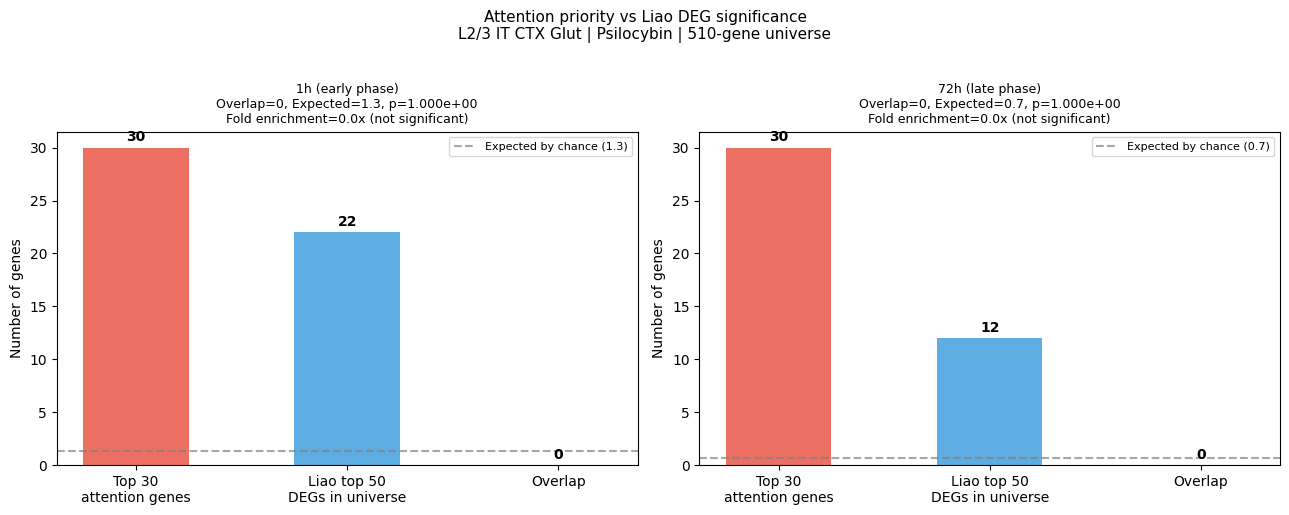


SUMMARY: Attention priority vs Liao DEG significance
  Cell type: L2/3 IT CTX Glut | Drug: Psilocybin
  Universe: 510 genes | Attention set: top 30 by temporal CV

  1h  overlap: 0/30 genes (0.0% of attention set), expected 1.3, p=1.0000e+00
  72h overlap: 0/30 genes (0.0% of attention set), expected 0.7, p=1.0000e+00

  EARLY PHASE: No significant enrichment — model attention priorities do not specifically align with Liao 1h DEGs
  LATE PHASE:  No significant enrichment — model attention priorities do not specifically align with Liao 72h DEGs


In [ ]:
# ============================================================================
# INVESTIGATION BLOCK 10 — ATTENTION PRIORITY vs LIAO DEG SIGNIFICANCE
# ============================================================================
# Hypothesis: genes the model finds most temporally informative (top 30 by
# attention CV) should overlap with genes Liao found most statistically
# significant at 1h and 72h in L2/3 IT neurons.
#
# Test: hypergeometric overlap between top attention genes and Liao top DEGs
# at each phase. Null = random overlap at 30/510 = 5.9% rate.
# Cell type: L2/3 IT (007 L2/3 IT CTX Glut) — primary target, highest
# biological confidence.
# ============================================================================

from scipy.stats import hypergeom

# ── INV-10A: Top 30 attention genes (from INV-2A) ────────────────────────────
# These were computed in INV-2A. If attn_results is still in scope, use it.
# Otherwise recompute.
if 'attn_results' not in dir():
    print("Recomputing temporal attention CV...")
    attn_results = compute_temporal_attention_cv(
        '007 L2/3 IT CTX Glut', 'Psilo', model, device)

top30_attn_genes = set(r['gene'] for r in attn_results[:30])
print(f"Top 30 attention genes (by temporal CV):")
print(f"  {sorted(top30_attn_genes)}")


# ── INV-10B: Liao top DEGs at 1h and 72h — L2/3 IT ──────────────────────────
# Pull from SQLite. Use psilocybin only, L2/3 IT cell type.
# Rank by adjusted p-value (ascending), then by |LFC| (descending).
# Take top 50 at each phase.

conn = sqlite3.connect(DB_PATH)

TOP_N = 50

liao_1h = pd.read_sql(f"""
    SELECT gene_name, log2FoldChange, padj, ABS(log2FoldChange) as abs_lfc
    FROM de_results
    WHERE celltype = '007 L2/3 IT CTX Glut'
    AND treatment_drug = 'Psilo'
    AND treatment_time = '1h'
    AND padj < 0.05
    ORDER BY padj ASC, abs_lfc DESC
    LIMIT {TOP_N}
""", conn)

liao_72h = pd.read_sql(f"""
    SELECT gene_name, log2FoldChange, padj, ABS(log2FoldChange) as abs_lfc
    FROM de_results
    WHERE celltype = '007 L2/3 IT CTX Glut'
    AND treatment_drug = 'Psilo'
    AND treatment_time = '72h'
    AND padj < 0.05
    ORDER BY padj ASC, abs_lfc DESC
    LIMIT {TOP_N}
""", conn)
conn.close()

liao_1h_genes  = set(liao_1h['gene_name'].tolist())
liao_72h_genes = set(liao_72h['gene_name'].tolist())

# Filter to genes in our 510-gene universe
liao_1h_in_universe  = liao_1h_genes  & set(final_genes_500)
liao_72h_in_universe = liao_72h_genes & set(final_genes_500)

print(f"\nLiao top {TOP_N} DEGs at 1h  (L2/3 IT, Psilo): "
      f"{len(liao_1h_genes)} total, "
      f"{len(liao_1h_in_universe)} in our 510-gene universe")
print(f"Liao top {TOP_N} DEGs at 72h (L2/3 IT, Psilo): "
      f"{len(liao_72h_genes)} total, "
      f"{len(liao_72h_in_universe)} in our 510-gene universe")


# ── INV-10C: Overlap and hypergeometric test ──────────────────────────────────
# Hypergeometric test parameters:
#   M = universe size (510 genes)
#   n = number of "successes" in universe (top 30 attention genes)
#   N = number drawn (Liao top DEGs in universe)
#   k = observed overlap

M = len(final_genes_500)  # 510
n = 30                     # top attention genes

def hypergeom_test(universe_size, attention_genes, liao_genes, label):
    overlap = attention_genes & liao_genes
    N = len(liao_genes)
    k = len(overlap)
    expected = n * N / universe_size
    # P(X >= k) — one-tailed, enrichment
    p_val = hypergeom.sf(k - 1, universe_size, n, N)

    print(f"\n  {label}:")
    print(f"    Universe: {universe_size} genes")
    print(f"    Attention top 30: {n} genes")
    print(f"    Liao DEGs in universe: {N}")
    print(f"    Overlap: {k} genes")
    print(f"    Expected by chance: {expected:.2f}")
    print(f"    Enrichment fold: {k/expected:.2f}x")
    print(f"    Hypergeometric p-value: {p_val:.4e}")
    if overlap:
        print(f"    Overlapping genes: {sorted(overlap)}")
    else:
        print(f"    No overlapping genes")
    return overlap, p_val, k, expected

print(f"\nOverlap analysis:")
overlap_1h,  p_1h,  k_1h,  exp_1h  = hypergeom_test(
    M, top30_attn_genes, liao_1h_in_universe,  "1h  (early phase)")
overlap_72h, p_72h, k_72h, exp_72h = hypergeom_test(
    M, top30_attn_genes, liao_72h_in_universe, "72h (late phase)")


# ── INV-10D: Extend to top 50 and top 100 attention genes ────────────────────
# Check if signal improves with more attention genes — tests whether the
# relationship is specific to the very top genes or broader.
print(f"\nSensitivity check — expanding attention gene set:")
print(f"  {'Top N attn':>12}  {'1h overlap':>12}  {'1h p':>10}  "
      f"{'72h overlap':>12}  {'72h p':>10}")
print("  " + "-"*60)

for top_n in [30, 50, 100]:
    attn_set = set(r['gene'] for r in attn_results[:top_n])
    o1  = attn_set & liao_1h_in_universe
    o72 = attn_set & liao_72h_in_universe
    p1  = hypergeom.sf(len(o1)  - 1, M, top_n, len(liao_1h_in_universe))
    p72 = hypergeom.sf(len(o72) - 1, M, top_n, len(liao_72h_in_universe))
    print(f"  {top_n:>12}  {len(o1):>12}  {p1:>10.4e}  "
          f"{len(o72):>12}  {p72:>10.4e}")


# ── INV-10E: Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, overlap, liao_genes, p_val, k, expected, tp_label in [
    (axes[0], overlap_1h,  liao_1h_in_universe,  p_1h,
     k_1h,  exp_1h,  '1h (early phase)'),
    (axes[1], overlap_72h, liao_72h_in_universe, p_72h,
     k_72h, exp_72h, '72h (late phase)'),
]:
    # Venn-style bar chart
    categories = ['Top 30\nattention genes',
                  f'Liao top {TOP_N}\nDEGs in universe',
                  'Overlap']
    values     = [30, len(liao_genes), k]
    colors     = ['#E74C3C', '#3498DB', '#9B59B6']
    bars = ax.bar(categories, values, color=colors, alpha=0.8, width=0.5)
    ax.axhline(y=expected, color='gray', linestyle='--',
               alpha=0.7, label=f'Expected by chance ({expected:.1f})')
    ax.set_ylabel('Number of genes', fontsize=10)
    ax.set_title(f'{tp_label}\nOverlap={k}, Expected={expected:.1f}, '
                 f'p={p_val:.3e}\nFold enrichment={k/expected:.1f}x '
                 f'{"(SIGNIFICANT)" if p_val < 0.05 else "(not significant)"}',
                 fontsize=9)
    ax.legend(fontsize=8)
    # Label bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Attention priority vs Liao DEG significance\n'
             'L2/3 IT CTX Glut | Psilocybin | 510-gene universe',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/attention_vs_liao_overlap.png',
            dpi=150, bbox_inches='tight')
plt.show()


# ── INV-10F: Summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("SUMMARY: Attention priority vs Liao DEG significance")
print(f"{'='*60}")
print(f"  Cell type: L2/3 IT CTX Glut | Drug: Psilocybin")
print(f"  Universe: {M} genes | Attention set: top 30 by temporal CV")
print(f"\n  1h  overlap: {k_1h}/{n} genes "
      f"({k_1h/n*100:.1f}% of attention set), "
      f"expected {exp_1h:.1f}, p={p_1h:.4e}")
print(f"  72h overlap: {k_72h}/{n} genes "
      f"({k_72h/n*100:.1f}% of attention set), "
      f"expected {exp_72h:.1f}, p={p_72h:.4e}")

if p_1h < 0.05 and k_1h > exp_1h:
    print(f"\n  EARLY PHASE: Significant enrichment — model attention "
          f"priorities align with Liao 1h DEGs")
elif p_1h >= 0.05:
    print(f"\n  EARLY PHASE: No significant enrichment — model attention "
          f"priorities do not specifically align with Liao 1h DEGs")

if p_72h < 0.05 and k_72h > exp_72h:
    print(f"  LATE PHASE:  Significant enrichment — model attention "
          f"priorities align with Liao 72h DEGs")
elif p_72h >= 0.05:
    print(f"  LATE PHASE:  No significant enrichment — model attention "
          f"priorities do not specifically align with Liao 72h DEGs")


In [ ]:
#------------------------------------- Dr Bagot -------------------------------------------------#

In [ ]:
# ── INV-11A: Explore Bagot metadata ──────────────────────────────────────────
import pandas as pd
import numpy as np

BAGOT_PATH = DRIVE_PATH + '/module2-gene-delta/data'

print("Loading cell metadata...")
meta = pd.read_csv(f'{BAGOT_PATH}/GSE283929_cell_metadata.csv.gz')
print(f"Shape: {meta.shape}")
print(f"\nColumns:\n{list(meta.columns)}")
print(f"\nFirst 3 rows:\n{meta.head(3).to_string()}")

for col in meta.columns:
    n_unique = meta[col].nunique()
    if n_unique <= 25:
        print(f"\n{col} ({n_unique} unique): {sorted(meta[col].unique())}")
    else:
        print(f"\n{col}: {n_unique} unique values — sample: {list(meta[col].unique())[:5]}")

print("\n\nCell count file:")
cc = pd.read_csv(f'{BAGOT_PATH}/GSE283929_cell_count.csv.gz')
print(cc.to_string())


Loading cell metadata...
Shape: (39435, 17)

Columns:
['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'condition', 'sex', 'percent.mt', 'label.from.pfc', 'label.from.allen', 'label', 'RNA_snn_res.0.5', 'seurat_clusters', 'RNA_snn_res.0.1', 'subtype', 'cell.type', 'sample_combined']

First 3 rows:
             Unnamed: 0     orig.ident  nCount_RNA  nFeature_RNA  sample condition sex  percent.mt label.from.pfc label.from.allen        label  RNA_snn_res.0.5  seurat_clusters  RNA_snn_res.0.1  subtype cell.type sample_combined
0  TGAGGAGCAAGTAGTA-1_1  SeuratProject       22564          4851  PSY_F1       PSY   F    0.833186     Excitatory          L6b_CTX      L6b_CTX                7                1              1.0    L6_CT     Gluta          PSI_F1
1  GAGCCTGGTAAGAACT-1_1  SeuratProject       22565          4650  PSY_F1       PSY   F    1.431420     Excitatory      L2_3_IT_CTX  L2_3_IT_CTX                5                0              0.0  L2-5_IT     Gluta        

In [ ]:
import gzip
with gzip.open(f'{BAGOT_PATH}/GSE283929_expression_matrix.csv.gz', 'rt') as f:
    line1 = f.readline()
    line2 = f.readline()
print(repr(line1[:200]))
print(repr(line2[:100]))

'TGAGGAGCAAGTAGTA-1_1 GAGCCTGGTAAGAACT-1_1 GGTCACGAGAGTTCGG-1_1 CATTCCGTCACCATAG-1_1 ACTATCTTCCATACAG-1_1 ATCTCTAGTCTCAAGT-1_1 TTCCGGTCACTGTTCC-1_1 GGGTAGAGTGGACTGA-1_1 AGGGTCCAGATCCGAG-1_1 GCACGGTCAGT'
'Xkr4 58 11 44 45 50 51 56 23 42 46 34 47 27 31 10 43 26 27 28 33 31 22 32 45 18 43 13 21 43 51 21 32'


In [ ]:
with open(f'{DRIVE_PATH}/module2-gene-delta/data/bagot_pseudobulks.pkl', 'rb') as f:
    d = pickle.load(f)
pseudobulk_bagot = d['pseudobulk_bagot']
bagot_lfc = d['bagot_lfc']
bagot_saline_mean = d['bagot_saline_mean']
genes_in_bagot = d['genes_in_bagot']

In [ ]:
# ── INV-11B: Load expression matrix and build Bagot pseudobulks ──────────────
# Expression matrix is genes × cells (rows = genes, cols = cell barcodes)
# We need to: filter to 510-gene panel, compute mean per animal × subtype,
# then construct model input tensors.

import torch
import torch.nn.functional as F
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

MIN_CELLS = 10  # minimum cells per animal × subtype to include
TIMEPOINT_IDX_24H = 4  # index in [0h, 1h, 2h, 4h, 24h, 72h]

print("Loading expression matrix (this will take ~2-3 minutes)...")
expr = pd.read_csv(f'{BAGOT_PATH}/GSE283929_expression_matrix.csv.gz',
                   index_col=0, sep=' ')
print(f"Expression matrix shape: {expr.shape}  (genes × cells)")
print(f"First 3 gene names: {list(expr.index[:3])}")
print(f"First 3 cell barcodes: {list(expr.columns[:3])}")

Loading expression matrix (this will take ~2-3 minutes)...
Expression matrix shape: (24600, 39565)  (genes × cells)
First 3 gene names: ['Xkr4', 'Gm1992', 'Gm19938']
First 3 cell barcodes: ['TGAGGAGCAAGTAGTA-1_1', 'GAGCCTGGTAAGAACT-1_1', 'GGTCACGAGAGTTCGG-1_1']


In [ ]:
# Quick check — what do the gene names look like?
print(expr.index[:20].tolist())
print(f"\nTotal genes in matrix: {len(expr.index)}")

['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587', 'Gm37323', 'Mrpl15', 'Lypla1', 'Tcea1', 'Rgs20', 'Gm16041', 'Atp6v1h', 'Oprk1', 'Rb1cc1', '4732440D04Rik', 'Alkal1', 'St18', 'Pcmtd1']

Total genes in matrix: 24600


In [ ]:
# ── INV-11C: Filter to 510-gene panel and build pseudobulks ──────────────────

# Map final_genes_500 (our 510 gene panel) to Bagot gene names
# Bagot uses standard mouse gene symbols — should match directly
genes_in_bagot = [g for g in final_genes_500 if g in expr.index]
genes_missing  = [g for g in final_genes_500 if g not in expr.index]
print(f"510-gene panel: {len(genes_in_bagot)} found in Bagot, "
      f"{len(genes_missing)} missing")
if genes_missing:
    print(f"Missing genes: {genes_missing[:20]}")

# Filter expression matrix to our gene panel
expr_filtered = expr.loc[genes_in_bagot]  # (n_found_genes, n_cells)
print(f"\nFiltered expression matrix: {expr_filtered.shape}")

# Normalize: log(CPM+1) — Bagot data is raw counts from CellRanger/CellBender
# Check if already normalized
print(f"\nExpression value range: {expr_filtered.values.min():.2f} "
      f"— {expr_filtered.values.max():.2f}")
print(f"Are values integers? {(expr_filtered.values == expr_filtered.values.astype(int)).all()}")
# If integer → raw counts, normalize. If float with large range → likely raw.
# If max ~10-15 → likely already log-normalized.

510-gene panel: 510 found in Bagot, 0 missing

Filtered expression matrix: (510, 39565)

Expression value range: 0.00 — 1086.00
Are values integers? True


In [ ]:
# ── INV-11D: Normalize if needed, then build pseudobulks ─────────────────────

# Normalize raw counts to log(CPM+1) if needed
max_val = expr_filtered.values.max()
if max_val > 50:
    print("Detected raw counts — normalizing to log(CPM+1)...")
    # CPM normalization per cell
    cell_totals = expr_filtered.sum(axis=0)  # total counts per cell
    cpm = expr_filtered.divide(cell_totals, axis=1) * 1e6
    expr_norm = np.log1p(cpm)
    print(f"After normalization: range {expr_norm.values.min():.2f} "
          f"— {expr_norm.values.max():.2f}")
else:
    print("Data appears already normalized.")
    expr_norm = expr_filtered

# Build pseudobulks: mean expression per animal × subtype
# Use subtype column from metadata; join on cell barcode
meta_indexed = meta.set_index('Unnamed: 0')  # cell barcode as index

# Align: only keep cells present in both expression and metadata
common_cells = expr_norm.columns.intersection(meta_indexed.index)
print(f"\nCells in expression matrix: {expr_norm.shape[1]}")
print(f"Cells in metadata: {len(meta_indexed)}")
print(f"Common cells: {len(common_cells)}")

expr_aligned = expr_norm[common_cells]
meta_aligned = meta_indexed.loc[common_cells]

# Build pseudobulk dict: {(sample, subtype): mean_expression_vector}
pseudobulk_bagot = {}
cell_counts_bagot = {}

for (sample, subtype), group in meta_aligned.groupby(['sample_combined', 'subtype']):
    n_cells = len(group)
    if n_cells < MIN_CELLS:
        print(f"  SKIP {sample} × {subtype}: only {n_cells} cells (< {MIN_CELLS})")
        continue
    cells = group.index
    pb_vector = expr_aligned[cells].mean(axis=1).values  # mean across cells → (n_genes,)
    pseudobulk_bagot[(sample, subtype)] = pb_vector
    cell_counts_bagot[(sample, subtype)] = n_cells

print(f"\nPseudobulk profiles constructed: {len(pseudobulk_bagot)}")
print(f"\n{'Sample':15s}  {'Subtype':12s}  {'n_cells':>8}")
print("-"*40)
for (s, ct), n in sorted(cell_counts_bagot.items()):
    print(f"{s:15s}  {ct:12s}  {n:>8}")

Detected raw counts — normalizing to log(CPM+1)...
After normalization: range 0.00 — 13.69

Cells in expression matrix: 39565
Cells in metadata: 39435
Common cells: 39435
  SKIP PSI_F4 × L5-6_NP: only 8 cells (< 10)

Pseudobulk profiles constructed: 86

Sample           Subtype        n_cells
----------------------------------------
PSI_F1           Astro             2235
PSI_F1           Endo               416
PSI_F1           GABA               152
PSI_F1           L2-5_IT            420
PSI_F1           L5-6_NP             54
PSI_F1           L5_PT              103
PSI_F1           L6_CT              481
PSI_F1           Micro              385
PSI_F1           NFO                296
PSI_F1           OPC                641
PSI_F1           Oligo             1315
PSI_F2           Astro             2659
PSI_F2           Endo              1037
PSI_F2           GABA               272
PSI_F2           L2-5_IT            421
PSI_F2           L5-6_NP             69
PSI_F2           L5_PT   

In [ ]:
import pickle
with open(f'{DRIVE_PATH}/module2-gene-delta/data/bagot_pseudobulks.pkl', 'wb') as f:
    pickle.dump({'pseudobulk': pseudobulk_bagot,
                 'cell_counts': cell_counts_bagot,
                 'meta': meta_aligned}, f)

In [ ]:
# ── INV-11E: Compute Bagot DEGs (psilo vs saline per subtype) ────────────────
# Simple approach: for each subtype, compare mean expression in psilo vs saline
# animals. Compute log2FC and a basic t-test across replicates.
# This gives us the "ground truth" direction to validate against.

from scipy.stats import ttest_ind

subtypes_bagot = sorted(set(ct for (_, ct) in pseudobulk_bagot.keys()))
psilo_samples  = [s for s in meta_aligned['sample_combined'].unique()
                  if s.startswith('PSI')]
saline_samples = [s for s in meta_aligned['sample_combined'].unique()
                  if s.startswith('SAL')]

print(f"Psilo samples: {psilo_samples}")
print(f"Saline samples: {saline_samples}")
print(f"Subtypes with pseudobulks: {subtypes_bagot}")

bagot_lfc = {}  # {subtype: array of log2FC per gene (510,)}

for subtype in subtypes_bagot:
    psilo_vecs  = [pseudobulk_bagot[(s, subtype)]
                   for s in psilo_samples
                   if (s, subtype) in pseudobulk_bagot]
    saline_vecs = [pseudobulk_bagot[(s, subtype)]
                   for s in saline_samples
                   if (s, subtype) in pseudobulk_bagot]

    if len(psilo_vecs) < 2 or len(saline_vecs) < 2:
        print(f"  SKIP {subtype}: insufficient replicates "
              f"(psilo={len(psilo_vecs)}, saline={len(saline_vecs)})")
        continue

    psilo_mat  = np.array(psilo_vecs)   # (n_psilo, n_genes)
    saline_mat = np.array(saline_vecs)  # (n_saline, n_genes)

    mean_psilo  = psilo_mat.mean(axis=0)
    mean_saline = saline_mat.mean(axis=0)

    # log2FC: psilo vs saline (add small pseudocount for stability)
    lfc = np.log2(mean_psilo + 0.01) - np.log2(mean_saline + 0.01)
    bagot_lfc[subtype] = lfc

    n_up   = (lfc > 0.1).sum()
    n_down = (lfc < -0.1).sum()
    print(f"  {subtype:12s}: n_psilo={len(psilo_vecs)}, "
          f"n_saline={len(saline_vecs)}, "
          f"UP={n_up}, DOWN={n_down}, "
          f"max_lfc={lfc.max():.3f}, min_lfc={lfc.min():.3f}")

print(f"\nSubtypes with DEG data: {list(bagot_lfc.keys())}")

Psilo samples: ['PSI_F1', 'PSI_F2', 'PSI_F4', 'PSI_F5']
Saline samples: ['SAL_F1', 'SAL_F2', 'SAL_F3.F4', 'SAL_F6']
Subtypes with pseudobulks: ['Astro', 'Endo', 'GABA', 'L2-5_IT', 'L5-6_NP', 'L5_PT', 'L6_CT', 'Micro', 'NFO', 'OPC', 'Oligo']
  Astro       : n_psilo=4, n_saline=4, UP=180, DOWN=118, max_lfc=3.106, min_lfc=-1.608
  Endo        : n_psilo=4, n_saline=4, UP=276, DOWN=96, max_lfc=3.829, min_lfc=-1.873
  GABA        : n_psilo=4, n_saline=4, UP=101, DOWN=162, max_lfc=1.754, min_lfc=-2.510
  L2-5_IT     : n_psilo=4, n_saline=4, UP=64, DOWN=178, max_lfc=1.371, min_lfc=-1.644
  L5-6_NP     : n_psilo=3, n_saline=4, UP=57, DOWN=366, max_lfc=2.932, min_lfc=-3.844
  L5_PT       : n_psilo=4, n_saline=4, UP=117, DOWN=207, max_lfc=3.231, min_lfc=-2.571
  L6_CT       : n_psilo=4, n_saline=4, UP=99, DOWN=172, max_lfc=2.579, min_lfc=-3.157
  Micro       : n_psilo=4, n_saline=4, UP=164, DOWN=248, max_lfc=4.565, min_lfc=-4.256
  NFO         : n_psilo=4, n_saline=4, UP=202, DOWN=160, max_lfc=3.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA L4
Loaded 500-gene set: 505
Loading AnnData (~2 min for 13GB)...
Loaded: (322232, 26100)
Cell types: 18
Psilo animals/tp: {'1h': 3, '2h': 3, '4h': 4, '24h': 3, '72h': 4}
Control animals: 8
  [pseudobulk_v2] Loading from checkpoint...
Individual profiles: 728
Population means: 197
  [gene_set_500_v2] Computing...
  [gene_set_500_v2] Saved.
Gene set: 510 genes
  Grin2a: YES
  Grin2b: YES
  Shisa7: YES
  Shisa9: YES
  Htr2a: YES
  Bdnf: YES
  Arc: YES
  Fos: YES
  [input_tensors_v5_v2] Computing...
  [input_tensors_v5_v2] Saved.
Input tensor: torch.Size([623, 510, 6])
Individual: 588 | Population: 35
  [label_tensor_v5_v2] Computing...
  [label_tensor_v5_v2] Saved.
Label distribution:
  DOWN: 30,492 (1.6%)
  NEUTRAL: 1,493,808 (78.4%)
  UP: 64,350 (3.4%)
  BASELINE: 317,730 (16.7%)
N_GENES confirmed from tensor: 510
Parameters: 862,084
N

<string>:397: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True


Using N_GENES from tensor shape: 510
N_GENES: 510
N_TIMEPOINTS: 6
Parameters: 862,084
Loaded final checkpoint | loss=0.7655 | acc=0.694
Training done. Epochs: 300 | loss=0.7655 | acc=0.694


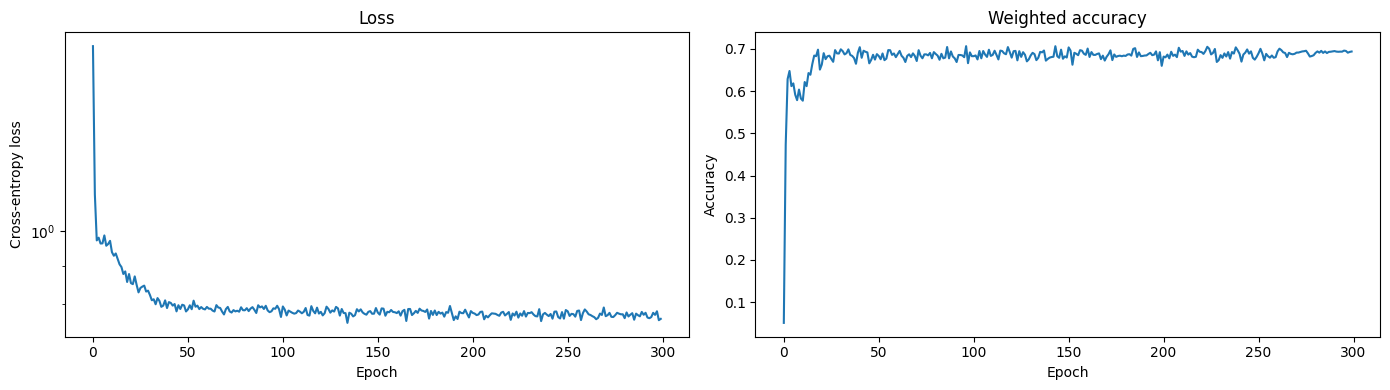

Loaded epoch 150 checkpoint for evaluation
Loss: 0.7804 | Acc: 0.703
Loading cached embeddings...
Embeddings: (623, 128)
Drug silhouette:      0.0618
Cell type silhouette: -0.0437


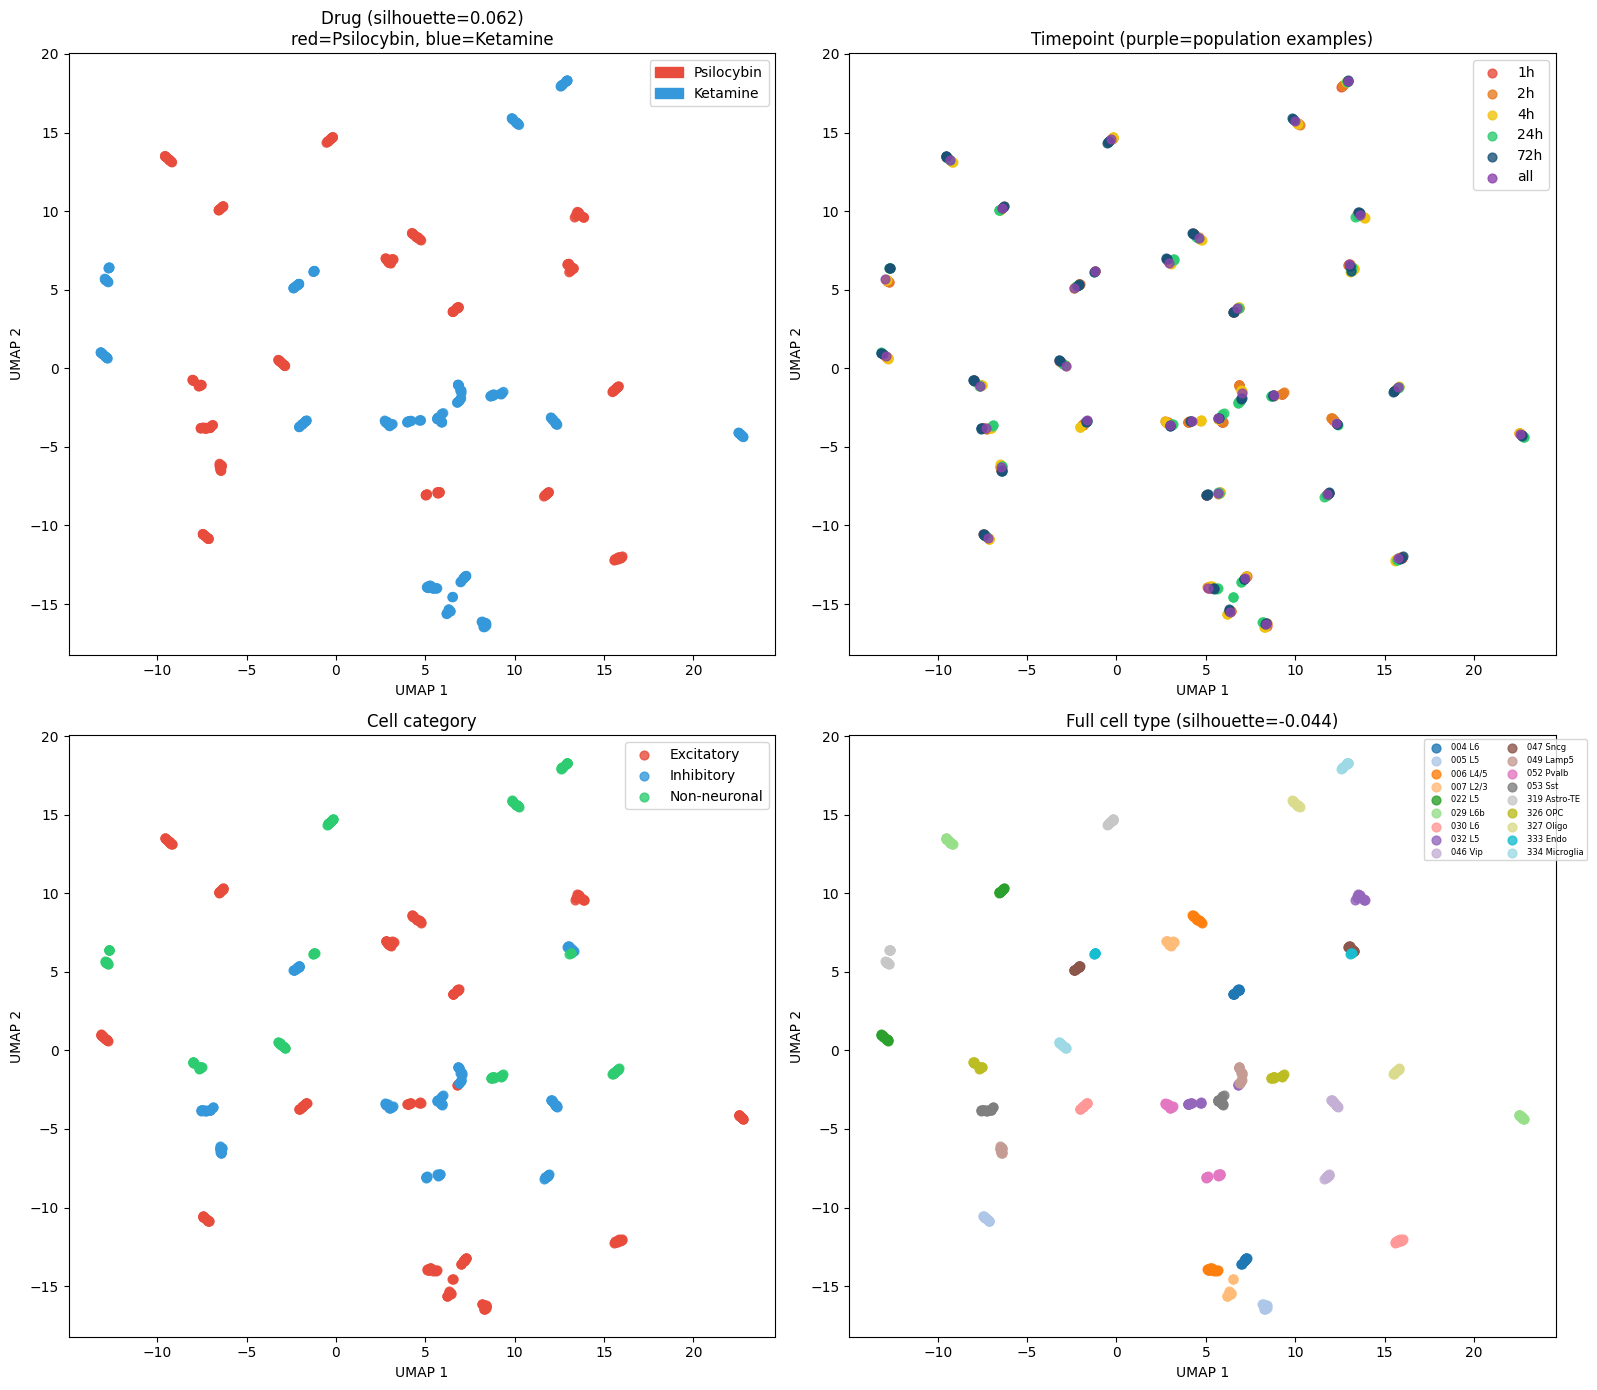

Per-class accuracy:
Class         Correct    Total      Acc
------------------------------------------
DOWN            4,178    7,604    0.549
NEUTRAL       268,774  365,798    0.735
UP                647   15,728    0.041
BASELINE            0        0    0.000

Per-cell-type accuracy (sorted by accuracy):
Cell type                           Acc    Total
--------------------------------------------------
333  Endo  NN                     0.996    7,650
047  Sncg  Gaba                   0.990   22,440
334  Microglia  NN                0.986   22,440
327  Oligo  NN                    0.963   22,440
326  OPC  NN                      0.954   22,440
046  Vip  Gaba                    0.912   22,440
049  Lamp5  Gaba                  0.882   22,440
319  Astro-TE  NN                 0.851   22,440
053  Sst  Gaba                    0.841   22,440
032  L5  NP                       0.773   22,440
029  L6b  CTX                     0.732   22,440
052  Pvalb  Gaba                  0.666   22,440
030

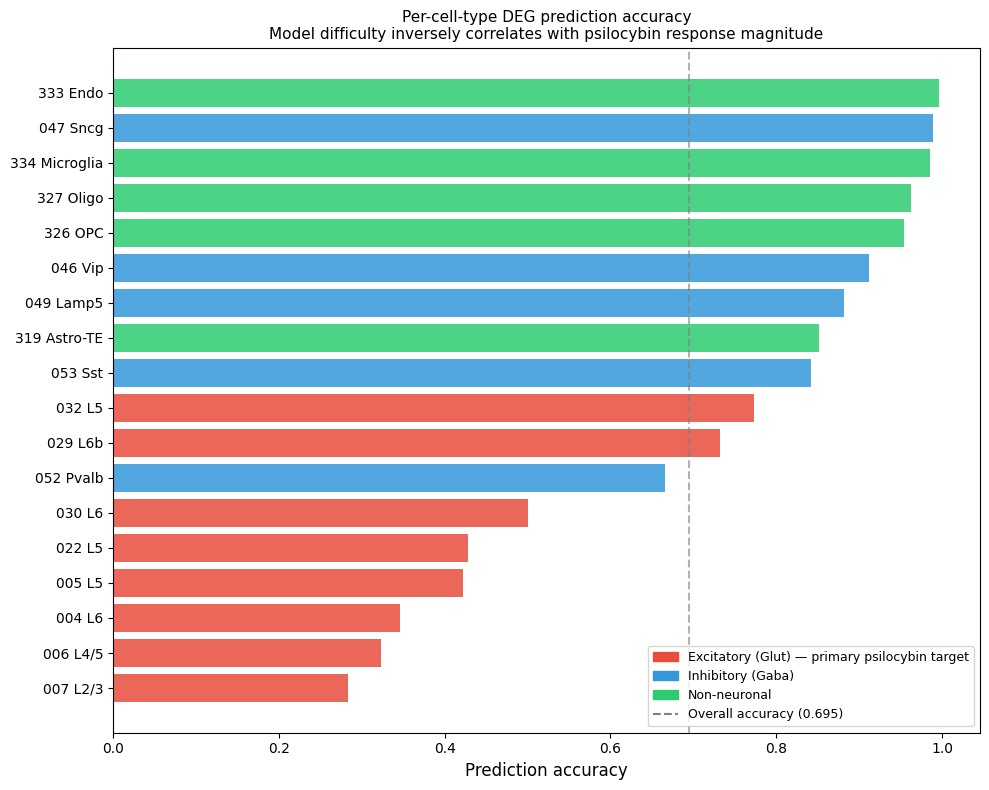

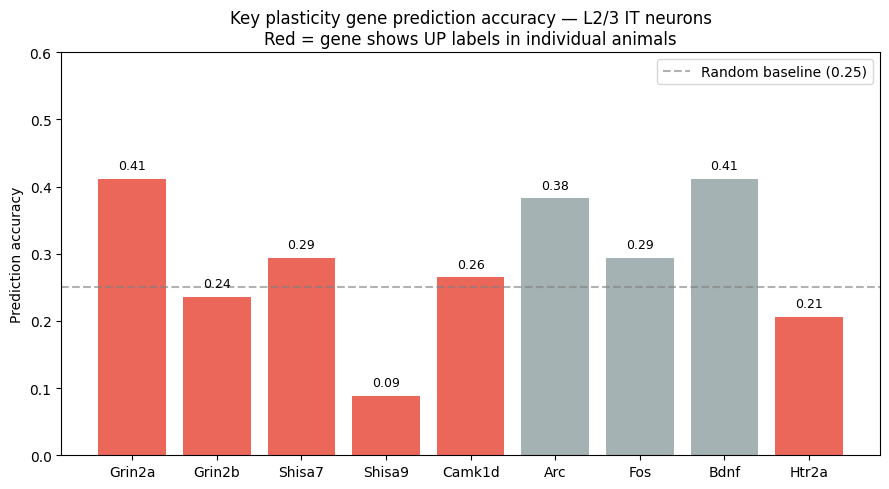

L2/3 IT Psilo individual examples: 17

Genes with UP labels (n>=3 animals):      234
Genes with DOWN labels (n>=3 animals):    122
Genes with NEUTRAL labels (n>=3 animals): 510

Expression variance across animals:
  UP genes      — mean std: 0.2403, median: 0.2164
  DOWN genes    — mean std: 0.1690, median: 0.1443
  NEUTRAL genes — mean std: 0.2638, median: 0.2569

Mann-Whitney U test (UP vs DOWN variance):
  U=18615.0, p=0.0000
  UP and DOWN genes have significantly different variance


<string>:1089: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


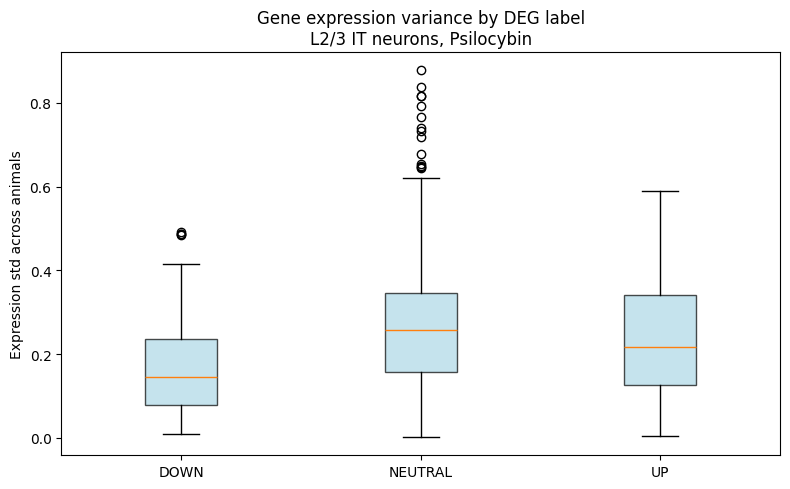

Cell type      UP std  DOWN std   Ratio    p-value   n_up  n_down
-----------------------------------------------------------------
L4/5           0.2471    0.1531    1.61     0.0000    237     127
L5             0.2452    0.1652    1.48     0.0000    223     130
L6             0.2441    0.1705    1.43     0.0000    214     124
L2/3           0.2403    0.1690    1.42     0.0000    234     122
L5             0.2624    0.1914    1.37     0.0004     97      67
L6             0.2292    0.1842    1.24     0.0028    197     126
L6b            0.2993    0.2550    1.17     0.1999     75      53
L5             0.1966    0.1835    1.07     0.4007    201     106
Attention weight extraction method added.
Attention weights: 4 layers, shape per layer: torch.Size([1, 3060, 3060])
L2/3 IT Psilo population examples: 1
Using example: {'animal': 'population', 'cell_type': '007 L2/3 IT CTX Glut', 'drug': 'Psilo', 'timepoint': 'all', 'timepoint_idx': -1, 'celltype_idx': 3, 'drug_idx': 0, 'example_type': 'p

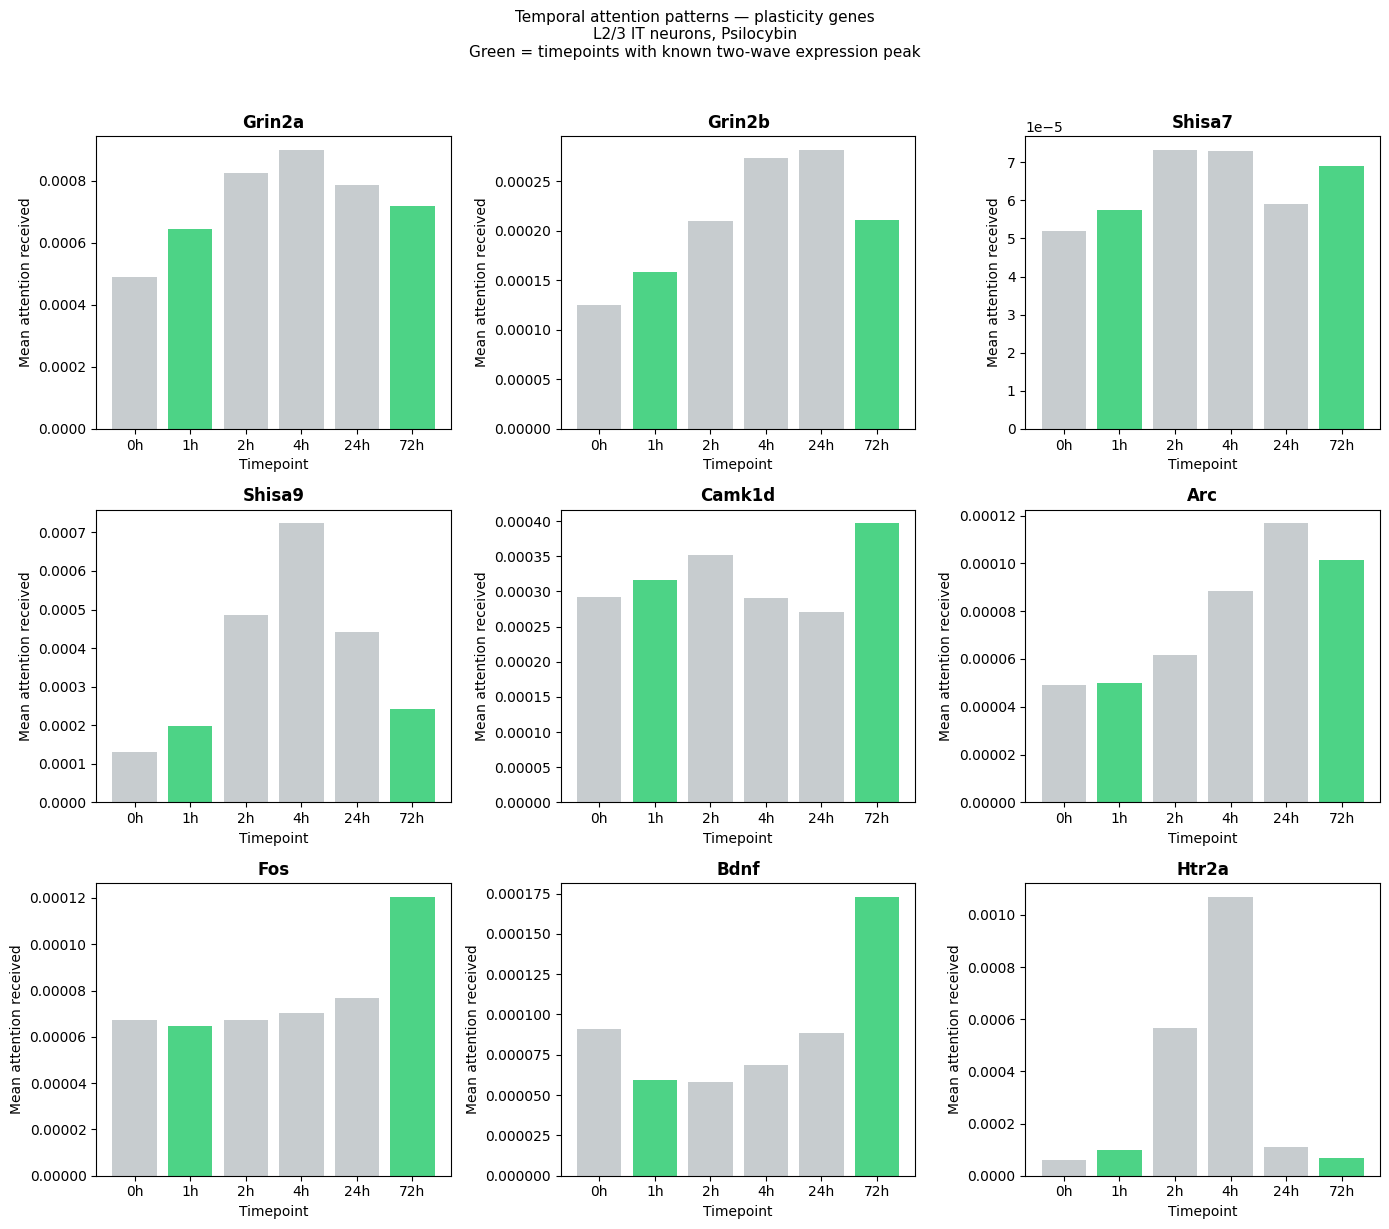


Two-hump attention score per gene:
Gene           1h attn   24h attn   72h attn   peak_ratio
-------------------------------------------------------
Grin2a        0.000646   0.000787   0.000719        0.867
Grin2b        0.000158   0.000282   0.000211        0.656
Shisa7        0.000057   0.000059   0.000069        1.071
Shisa9        0.000198   0.000440   0.000243        0.500
Camk1d        0.000316   0.000271   0.000397        1.315
Arc           0.000050   0.000117   0.000101        0.649
Fos           0.000065   0.000077   0.000120        1.204
Bdnf          0.000059   0.000088   0.000173        1.314
Htr2a         0.000099   0.000109   0.000067        0.759
Housekeeping genes in set: []

Flattest attention profiles (housekeeping candidates):
  Rapgefl1: CV=0.0503, attns=['0.000081', '0.000088', '0.000090', '0.000091', '0.000080', '0.000083']
  Nr4a3: CV=0.0571, attns=['0.000042', '0.000042', '0.000045', '0.000045', '0.000045', '0.000050']
  Celf3: CV=0.0740, attns=['0.000145', '0

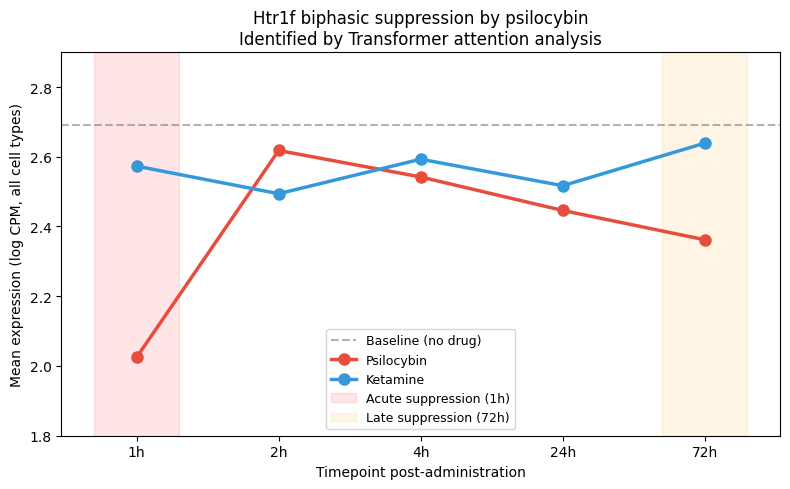

Biphasic pattern summary:
  Baseline:           2.692
  1h  Psilo vs Ket:   -0.548 (Psilo=2.025)
  2h  Psilo vs Ket:   +0.124 (recovery)
  72h Psilo vs Ket:   -0.277 (Psilo=2.362)


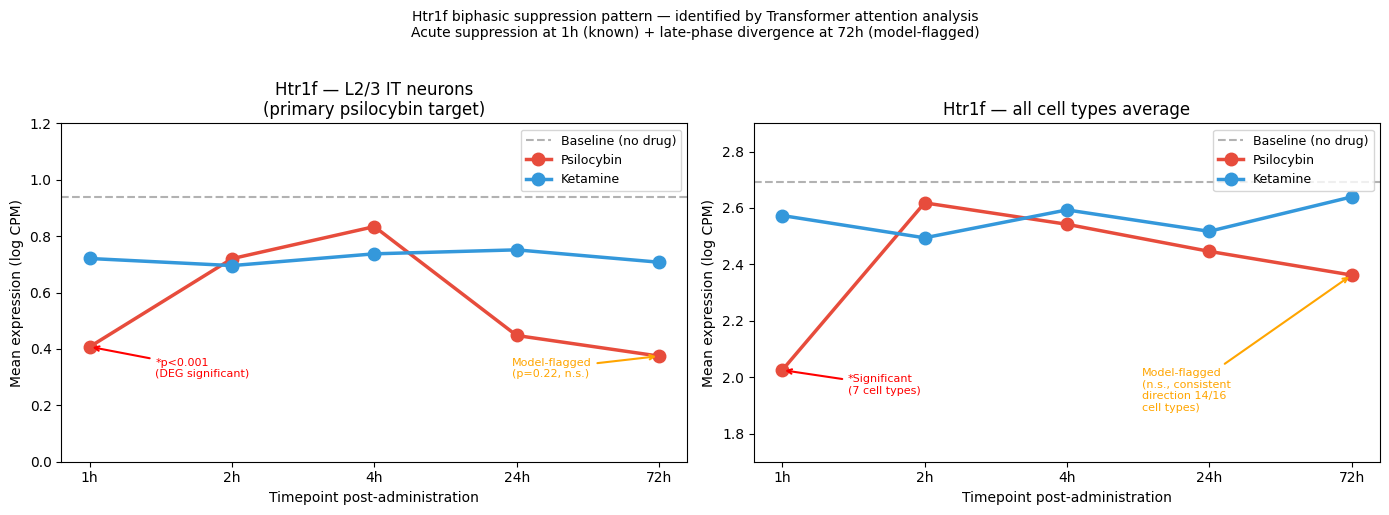

L2/3 IT Htr1f values:
drug    Ket  Psilo  none
time                    
1h    0.721  0.408   NaN
2h    0.696  0.720   NaN
4h    0.737  0.834   NaN
24h   0.751  0.448   NaN
72h   0.708  0.375   NaN
Model class loaded.


In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'scanpy', '-q'])

# Read the file, strip magic commands, exec to get the class
with open(f'{DRIVE_PATH}/module2-gene-delta/module2_prototype.py', 'r') as f:
    src = f.read()

# Remove jupyter magic lines
import re
src_clean = re.sub(r'^\s*!.*$', '', src, flags=re.MULTILINE)
exec(src_clean, globals())
print("Model class loaded.")

In [ ]:
print([ct for ct in ct_list if 'Astro' in ct])
print([ct for ct in ct_list if 'Endo' in ct])
print([ct for ct in ct_list if 'Micro' in ct])
print([ct for ct in ct_list if 'Oligo' in ct])

['319 Astro-TE NN']
['333 Endo NN']
['334 Microglia NN']
['327 Oligo NN']


In [ ]:
BAGOT_TO_LIAO = {
    'L2-5_IT':  '007 L2/3 IT CTX Glut',
    'L5-6_NP':  '032 L5 NP CTX Glut',
    'L5_PT':    '022 L5 ET CTX Glut',
    'L6_CT':    '004 L6 IT CTX Glut',
    'GABA':     '052 Pvalb Gaba',
    'Astro':    '319 Astro-TE NN',
    'Endo':     '333 Endo NN',
    'Micro':    '334 Microglia NN',
    'NFO':      '326 OPC NN',
    'OPC':      '326 OPC NN',
    'Oligo':    '327 Oligo NN',
}

In [ ]:
print([ct for ct in ct_list if 'IT' in ct or 'L2' in ct])
print([ct for ct in ct_list if 'NP' in ct or 'L5' in ct])
print([ct for ct in ct_list if 'Pvalb' in ct or 'GABA' in ct or 'Gaba' in ct])
print([ct for ct in ct_list if 'OPC' in ct or 'NFO' in ct])

['004 L6 IT CTX Glut', '005 L5 IT CTX Glut', '006 L4/5 IT CTX Glut', '007 L2/3 IT CTX Glut']
['005 L5 IT CTX Glut', '022 L5 ET CTX Glut', '032 L5 NP CTX Glut']
['046 Vip Gaba', '047 Sncg Gaba', '049 Lamp5 Gaba', '052 Pvalb Gaba', '053 Sst Gaba']
['326 OPC NN']


In [ ]:
# ── INV-11F: Model inference on Bagot pseudobulks ────────────────────────────
# For each psilo animal × subtype, construct model input tensor:
#   - Column 0 (0h): use Liao population mean baseline for that cell type
#     (best available proxy — Bagot has no 0h control, only 24h saline)
#     ALTERNATIVE: use Bagot saline mean as baseline
#   - Column 4 (24h): Bagot psilo pseudobulk for this animal
#   - All other columns: sentinel -1.0
# Run model, extract signed scores P(UP)-P(DOWN) per gene at 24h.

# We'll use Bagot saline MEAN as baseline (column 0) — cleaner than
# using Liao baseline which introduces cross-dataset noise.
bagot_saline_mean = {}
for subtype in subtypes_bagot:
    saline_vecs = [pseudobulk_bagot[(s, subtype)]
                   for s in saline_samples
                   if (s, subtype) in pseudobulk_bagot]
    if saline_vecs:
        bagot_saline_mean[subtype] = np.array(saline_vecs).mean(axis=0)

def build_bagot_tensor(psilo_vec, saline_baseline, n_genes=510, n_timepoints=6):
    """Build a (1, n_genes, n_timepoints) input tensor for one Bagot example."""
    x = np.full((n_genes, n_timepoints), NOT_MEASURED, dtype=np.float32)
    # Map genes: pseudobulk_bagot uses genes_in_bagot ordering
    # We need to align to final_genes_500 ordering
    for i, gene in enumerate(final_genes_500):
        if gene in genes_in_bagot:
            gene_idx_bagot = genes_in_bagot.index(gene)
            x[i, 0] = saline_baseline[gene_idx_bagot]   # baseline at 0h
            x[i, TIMEPOINT_IDX_24H] = psilo_vec[gene_idx_bagot]  # 24h drug
    # Per-example normalization (same as training)
    measured = x[x != NOT_MEASURED]
    if len(measured) > 0:
        x_norm = x.copy()
        x_norm[x != NOT_MEASURED] = (measured - measured.mean()) / (measured.std() + 1e-8)
        x_norm[x == NOT_MEASURED] = NOT_MEASURED
        return torch.tensor(x_norm).unsqueeze(0)  # (1, n_genes, n_timepoints)
    return torch.tensor(x).unsqueeze(0)

# Get cell type and drug conditioning indices
# Bagot subtypes need to map to our 18 cell types for conditioning
# Use best available match from our ct_list
BAGOT_TO_LIAO = {
    'L2-5_IT':  '007 L2/3 IT CTX Glut',
    'L5-6_NP':  '032 L5 NP CTX Glut',
    'L5_PT':    '022 L5 ET CTX Glut',
    'L6_CT':    '004 L6 IT CTX Glut',
    'GABA':     '052 Pvalb Gaba',
    'Astro':    '319 Astro-TE NN',
    'Endo':     '333 Endo NN',
    'Micro':    '334 Microglia NN',
    'NFO':      '326 OPC NN',
    'OPC':      '326 OPC NN',
    'Oligo':    '327 Oligo NN',
}

# Run inference: for each psilo animal × subtype, get signed scores
bagot_signed_scores = {}  # {subtype: mean signed score array (n_genes,)}

model.eval()
# For each subtype: one mean psilo vector, one inference call
for subtype in subtypes_bagot:
    if subtype not in bagot_lfc or subtype not in bagot_saline_mean:
        continue

    # Mean psilo pseudobulk across all animals
    psilo_vecs = [pseudobulk_bagot[(s, subtype)]
                  for s in psilo_samples
                  if (s, subtype) in pseudobulk_bagot]
    if not psilo_vecs:
        continue
    psilo_mean = np.array(psilo_vecs).mean(axis=0)
    baseline   = bagot_saline_mean[subtype]

    # One inference call
    x  = build_bagot_tensor(psilo_mean, baseline).to(device)
    ct = torch.tensor([ct_list.index(BAGOT_TO_LIAO[subtype])]).to(device)
    dr = torch.tensor([0]).to(device)  # psilo

    with torch.no_grad():
        _, logits = model.forward(x, ct, dr)

    probs  = F.softmax(logits[0], dim=-1).reshape(N_GENES, N_TIMEPOINTS, 4).cpu().numpy()
    signed = probs[:, TIMEPOINT_IDX_24H, UP] - probs[:, TIMEPOINT_IDX_24H, DOWN]
    bagot_signed_scores[subtype] = signed

print(f"\nInference complete for {len(bagot_signed_scores)} subtypes.")


Inference complete for 11 subtypes.


In [ ]:
# ── INV-11G: Per-cell-type Spearman correlation (primary test) ───────────────
# For each subtype: correlate model signed scores vs Bagot log2FC across genes.
# Only use the genes present in both datasets (genes_in_bagot ∩ final_genes_500).

print("="*65)
print("PRIMARY TEST: Model signed score vs Bagot log2FC per cell type")
print("(Spearman correlation across genes — directional agreement)")
print("="*65)
print(f"\n{'Subtype':12s}  {'n_genes':>8}  {'rho':>8}  {'p-value':>10}  "
      f"{'Direction':>12}  {'Bagot finding'}")
print("-"*80)

results_11g = {}
for subtype in sorted(bagot_signed_scores.keys()):
    scores = bagot_signed_scores[subtype]    # (510,) — model prediction
    lfc    = bagot_lfc[subtype]              # (510,) — Bagot ground truth

    # Only use genes present in Bagot (non-NaN LFC)
    # genes_in_bagot are already in final_genes_500 ordering
    valid_mask = np.array([g in genes_in_bagot for g in final_genes_500])
    valid_scores = scores[valid_mask]

    # Reorder lfc to match final_genes_500 ordering
    lfc_aligned = np.array([
        lfc[genes_in_bagot.index(g)]
        if g in genes_in_bagot else np.nan
        for g in final_genes_500
    ])
    valid_lfc = lfc_aligned[valid_mask]

    rho, pval = spearmanr(valid_scores, valid_lfc)
    direction = "↑ POSITIVE" if rho > 0 else "↓ NEGATIVE"
    sig = "*" if pval < 0.05 else ("~" if pval < 0.1 else " ")

    bagot_note = {
        'L5-6_NP': 'MOST responsive (Bagot Fig 2B)',
        'L2-5_IT': 'IEG upregulation (Arc, Nr4a3)',
        'L5_PT':   '2nd most DEGs (54 UP)',
        'L6_CT':   'Arc upregulation',
        'GABA':    'Suppressed signaling',
        'Astro':   'Non-neuronal',
        'Oligo':   'Non-neuronal',
        'Micro':   'Non-neuronal',
        'NFO':     'Non-neuronal',
        'OPC':     'Non-neuronal',
        'Endo':    'Non-neuronal',
    }.get(subtype, '')

    results_11g[subtype] = {'rho': rho, 'pval': pval, 'n_genes': valid_mask.sum()}
    print(f"{subtype:12s}  {valid_mask.sum():>8}  {rho:>8.4f}  {pval:>10.4e}  "
          f"{direction:>12}{sig}  {bagot_note}")

# Summary
pos_sig  = sum(1 for r in results_11g.values()
               if r['rho'] > 0 and r['pval'] < 0.05)
pos_any  = sum(1 for r in results_11g.values() if r['rho'] > 0)
total    = len(results_11g)
print(f"\nSummary: {pos_any}/{total} subtypes positive correlation, "
      f"{pos_sig}/{total} significant (p<0.05)")
print(f"Mean rho across all subtypes: "
      f"{np.mean([r['rho'] for r in results_11g.values()]):.4f}")
print(f"Mean rho neuronal only: "
      f"{np.mean([r['rho'] for k,r in results_11g.items() if k in ['L2-5_IT','L5-6_NP','L5_PT','L6_CT','GABA']]):.4f}")

PRIMARY TEST: Model signed score vs Bagot log2FC per cell type
(Spearman correlation across genes — directional agreement)

Subtype        n_genes       rho     p-value     Direction  Bagot finding
--------------------------------------------------------------------------------
Astro              510   -0.1065  1.6154e-02    ↓ NEGATIVE*  Non-neuronal
Endo               510    0.0931  3.5580e-02    ↑ POSITIVE*  Non-neuronal
GABA               510    0.0841  5.7615e-02    ↑ POSITIVE~  Suppressed signaling
L2-5_IT            510    0.0310  4.8486e-01    ↑ POSITIVE   IEG upregulation (Arc, Nr4a3)
L5-6_NP            510   -0.2369  6.1430e-08    ↓ NEGATIVE*  MOST responsive (Bagot Fig 2B)
L5_PT              510   -0.0190  6.6897e-01    ↓ NEGATIVE   2nd most DEGs (54 UP)
L6_CT              510   -0.2013  4.5841e-06    ↓ NEGATIVE*  Arc upregulation
Micro              510    0.0237  5.9407e-01    ↑ POSITIVE   Non-neuronal
NFO                510   -0.0145  7.4309e-01    ↓ NEGATIVE   Non-neuronal

Overall ρ = 0.1081, p = 4.73e-16
Total points: 5610 (11 subtypes × ~510 genes)


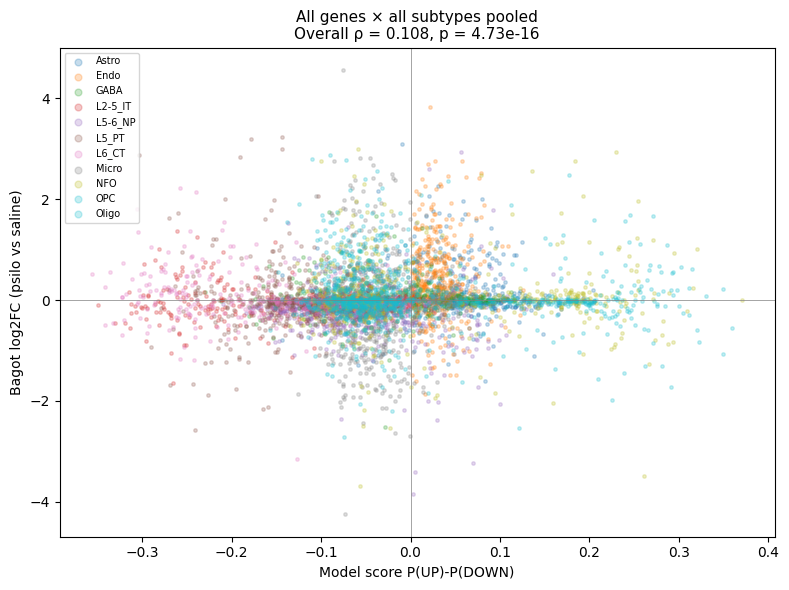

In [ ]:
# ── INV-11G supplement: overall correlation, no pre-grouping ─────────────────

all_scores = []
all_lfc    = []
all_labels = []

for subtype in bagot_signed_scores:
    if subtype not in bagot_lfc:
        continue
    scores = bagot_signed_scores[subtype]
    lfc_aligned = np.array([
        bagot_lfc[subtype][genes_in_bagot.index(g)]
        if g in genes_in_bagot else np.nan
        for g in final_genes_500
    ])
    valid = ~np.isnan(lfc_aligned)
    all_scores.extend(scores[valid])
    all_lfc.extend(lfc_aligned[valid])
    all_labels.extend([subtype] * valid.sum())

all_scores = np.array(all_scores)
all_lfc    = np.array(all_lfc)

rho_overall, p_overall = spearmanr(all_scores, all_lfc)
print(f"Overall ρ = {rho_overall:.4f}, p = {p_overall:.2e}")
print(f"Total points: {len(all_scores)} ({len(bagot_signed_scores)} subtypes × ~510 genes)")

# scatter — color by cell type, structure emerges from data
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(bagot_signed_scores)))
for i, subtype in enumerate(bagot_signed_scores):
    mask = np.array(all_labels) == subtype
    ax.scatter(all_scores[mask], all_lfc[mask],
               alpha=0.25, s=6, color=colors[i], label=subtype)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Model score P(UP)-P(DOWN)')
ax.set_ylabel('Bagot log2FC (psilo vs saline)')
ax.set_title(f'All genes × all subtypes pooled\nOverall ρ = {rho_overall:.3f}, p = {p_overall:.2e}',
             fontsize=11)
ax.legend(fontsize=7, markerscale=2, loc='upper left')
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV11_overall_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1144/2595967214.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


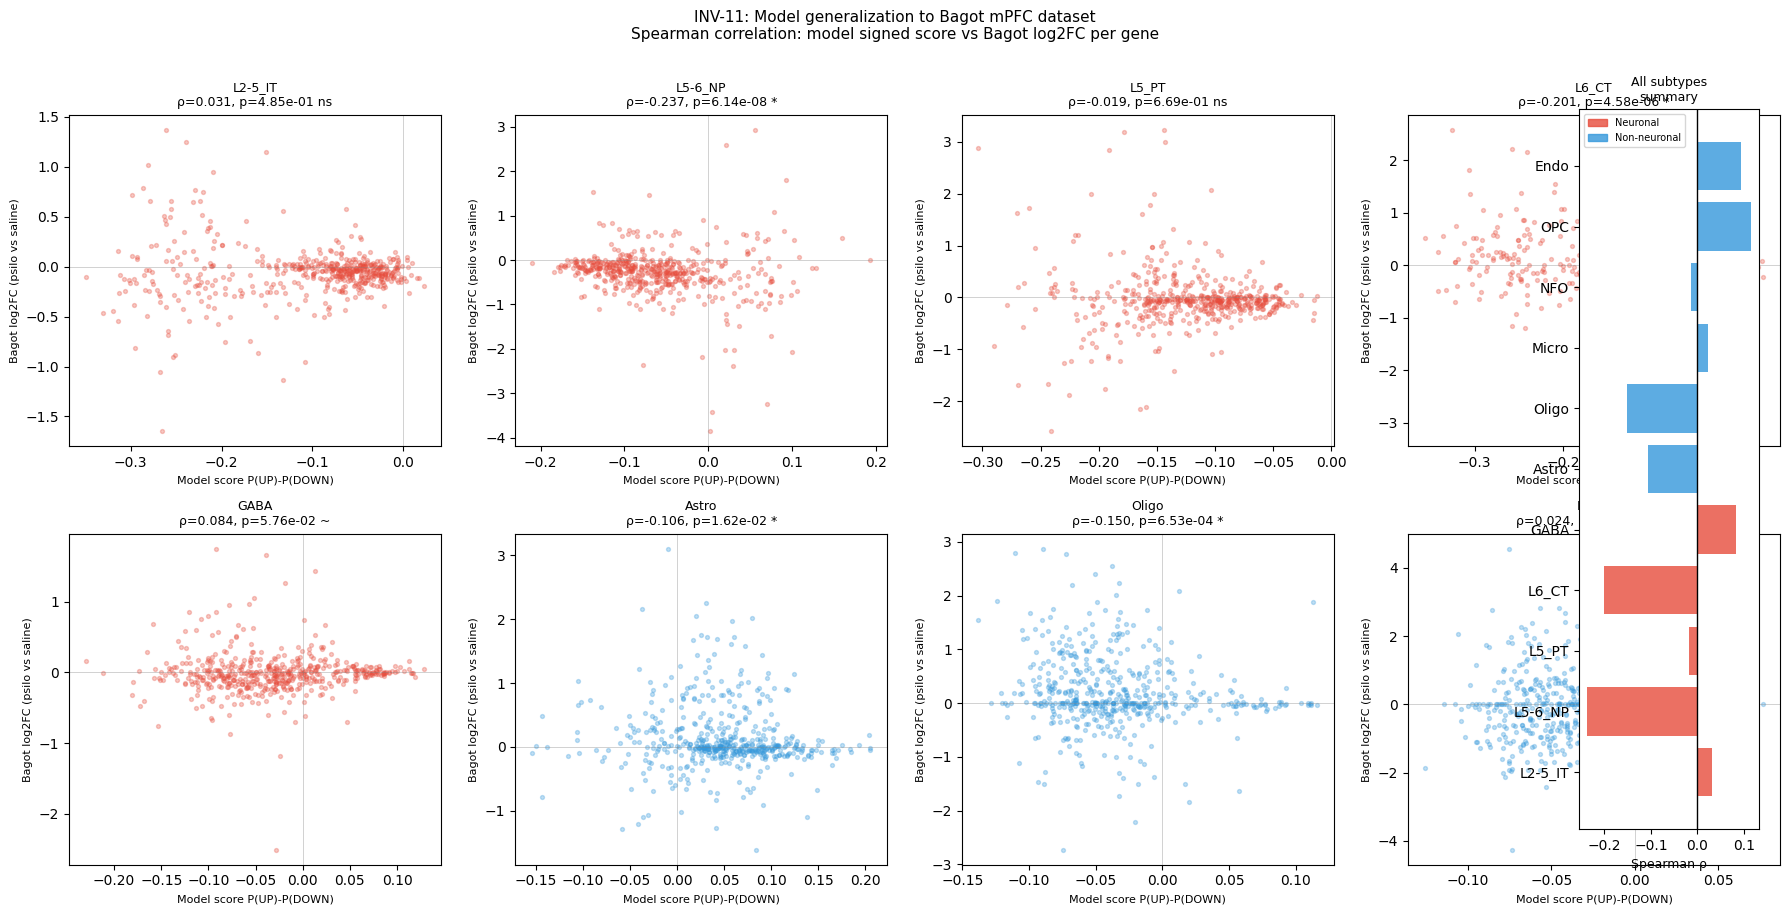


INV-11 complete.
Key question: is L5-6_NP among the highest rho values?
L5-6_NP rho = -0.2369
L2-5_IT rho = 0.0310


In [ ]:
# ── INV-11H: Visualisation ────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

neuronal    = ['L2-5_IT', 'L5-6_NP', 'L5_PT', 'L6_CT', 'GABA']
nonneuronal = ['Astro', 'Oligo', 'Micro', 'NFO', 'OPC', 'Endo']
plot_order  = [s for s in neuronal + nonneuronal
               if s in bagot_signed_scores and s in bagot_lfc]

for ax, subtype in zip(axes, plot_order):
    scores     = bagot_signed_scores[subtype]
    lfc_aligned = np.array([
        bagot_lfc[subtype][genes_in_bagot.index(g)]
        if g in genes_in_bagot else np.nan
        for g in final_genes_500
    ])
    valid = ~np.isnan(lfc_aligned)
    rho   = results_11g[subtype]['rho']
    pval  = results_11g[subtype]['pval']

    color = '#E74C3C' if subtype in neuronal else '#3498DB'
    ax.scatter(scores[valid], lfc_aligned[valid],
               alpha=0.3, s=8, color=color)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.set_xlabel('Model score P(UP)-P(DOWN)', fontsize=8)
    ax.set_ylabel('Bagot log2FC (psilo vs saline)', fontsize=8)
    sig_str = '*' if pval < 0.05 else ('~' if pval < 0.1 else 'ns')
    ax.set_title(f'{subtype}\nρ={rho:.3f}, p={pval:.2e} {sig_str}',
                 fontsize=9,
                 color='darkred' if rho > 0 and pval < 0.05 else 'black')

# Hide unused axes
for ax in axes[len(plot_order):]:
    ax.set_visible(False)

# Summary bar chart in last panel
ax = axes[7] if len(plot_order) <= 7 else fig.add_axes([0.88, 0.1, 0.1, 0.8])
rhos      = [results_11g[s]['rho'] for s in plot_order]
colors_bar = ['#E74C3C' if s in neuronal else '#3498DB' for s in plot_order]
bars = ax.barh(plot_order, rhos, color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Spearman ρ', fontsize=9)
ax.set_title('All subtypes\nsummary', fontsize=9)
red_patch  = mpatches.Patch(color='#E74C3C', alpha=0.8, label='Neuronal')
blue_patch = mpatches.Patch(color='#3498DB', alpha=0.8, label='Non-neuronal')
ax.legend(handles=[red_patch, blue_patch], fontsize=7)

plt.suptitle('INV-11: Model generalization to Bagot mPFC dataset\n'
             'Spearman correlation: model signed score vs Bagot log2FC per gene',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV11_bagot_crossvalidation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nINV-11 complete.")
print(f"Key question: is L5-6_NP among the highest rho values?")
print(f"L5-6_NP rho = {results_11g.get('L5-6_NP', {}).get('rho', 'N/A'):.4f}")
print(f"L2-5_IT rho = {results_11g.get('L2-5_IT', {}).get('rho', 'N/A'):.4f}")

In [ ]:
import pickle
with open(f'{DRIVE_PATH}/module2-gene-delta/data/bagot_pseudobulks.pkl', 'wb') as f:
    pickle.dump({
        'pseudobulk_bagot': pseudobulk_bagot,
        'cell_counts_bagot': cell_counts_bagot,
        'bagot_lfc': bagot_lfc,
        'bagot_saline_mean': bagot_saline_mean,
        'genes_in_bagot': genes_in_bagot,
    }, f)
print("Saved. Future sessions load from pickle, skip the 4GB CSV entirely.")

Saved. Future sessions load from pickle, skip the 4GB CSV entirely.


In [ ]:
#---------------INV12------------------#

In [ ]:
# ── INV-12A: Masked gene prediction on Bagot data ────────────────────────────
# For each target gene: hide its 24h value (set to sentinel), run inference,
# extract model's P(UP)-P(DOWN) for that gene, compare to Bagot log2FC.
# Start with top 50 genes by mean |log2FC| across cell types.

from scipy.stats import spearmanr
import pandas as pd

# ── Step 1: Pick target genes — top 50 by mean |log2FC| across subtypes ──────
mean_abs_lfc = {}
for gene in final_genes_500:
    if gene not in genes_in_bagot:
        continue
    gene_idx_bagot = genes_in_bagot.index(gene)
    lfcs = [abs(bagot_lfc[st][gene_idx_bagot])
            for st in subtypes_bagot if st in bagot_lfc]
    if lfcs:
        mean_abs_lfc[gene] = np.mean(lfcs)

target_genes = sorted(mean_abs_lfc, key=mean_abs_lfc.get, reverse=True)[:50]
print(f"Top 50 target genes selected. Mean |log2FC| range: "
      f"{mean_abs_lfc[target_genes[0]]:.3f} — {mean_abs_lfc[target_genes[49]]:.3f}")

# ── Step 2: Masked inference ──────────────────────────────────────────────────
# Results stored as: results[gene][subtype] = (model_score, bagot_lfc)
results_12a = {}

model.eval()
for gene in target_genes:
    gene_idx_panel  = list(final_genes_500).index(gene)
    gene_idx_bagot  = genes_in_bagot.index(gene)
    results_12a[gene] = {}

    for subtype in subtypes_bagot:
        if subtype not in bagot_lfc or subtype not in bagot_saline_mean:
            continue

        # Build mean psilo vector and baseline
        psilo_vecs = [pseudobulk_bagot[(s, subtype)]
                      for s in psilo_samples
                      if (s, subtype) in pseudobulk_bagot]
        if not psilo_vecs:
            continue
        psilo_mean = np.array(psilo_vecs).mean(axis=0)
        baseline   = bagot_saline_mean[subtype]

        # Build tensor — same as 11F but mask this gene at 24h
        x = np.full((N_GENES, N_TIMEPOINTS), NOT_MEASURED, dtype=np.float32)
        for i, g in enumerate(final_genes_500):
            if g in genes_in_bagot:
                idx = genes_in_bagot.index(g)
                x[i, 0] = baseline[idx]
                if i != gene_idx_panel:          # mask only the target gene
                    x[i, TIMEPOINT_IDX_24H] = psilo_mean[idx]
                # target gene stays NOT_MEASURED at 24h

        # Normalize
        measured = x[x != NOT_MEASURED]
        if len(measured) > 0:
            x_norm = x.copy()
            x_norm[x != NOT_MEASURED] = (
                (measured - measured.mean()) / (measured.std() + 1e-8))
            x_norm[x == NOT_MEASURED] = NOT_MEASURED
        else:
            x_norm = x

        x_t  = torch.tensor(x_norm).unsqueeze(0).to(device)
        ct   = torch.tensor(
            [ct_list.index(BAGOT_TO_LIAO[subtype])]).to(device)
        dr   = torch.tensor([0]).to(device)

        with torch.no_grad():
            _, logits = model.forward(x_t, ct, dr)

        probs  = F.softmax(logits[0], dim=-1).reshape(
            N_GENES, N_TIMEPOINTS, 4).cpu().numpy()
        score  = (probs[gene_idx_panel, TIMEPOINT_IDX_24H, UP] -
                  probs[gene_idx_panel, TIMEPOINT_IDX_24H, DOWN])
        actual = bagot_lfc[subtype][gene_idx_bagot]

        results_12a[gene][subtype] = (score, actual)

print(f"Inference complete: {len(target_genes)} genes × up to 11 subtypes")

# ── Step 3: Compute per-gene consistency score ────────────────────────────────
# Directional agreement: did model predict correct sign?
# Only score genes where |log2FC| > 0.3 (gene actually moved)
LFC_THRESH = 0.3

gene_stats = []
for gene in target_genes:
    scores, actuals, subtypes_hit = [], [], []
    correct, total = 0, 0
    for subtype, (score, actual) in results_12a[gene].items():
        if abs(actual) < LFC_THRESH:
            continue
        scores.append(score)
        actuals.append(actual)
        subtypes_hit.append(subtype)
        if np.sign(score) == np.sign(actual):
            correct += 1
        total += 1

    if total >= 3:
        rho, pval = spearmanr(scores, actuals) if len(scores) > 2 else (np.nan, np.nan)
        gene_stats.append({
            'gene': gene,
            'n_subtypes': total,
            'pct_correct': correct / total * 100,
            'rho': rho,
            'p': pval,
            'mean_abs_lfc': mean_abs_lfc[gene]
        })

df_12a = pd.DataFrame(gene_stats).sort_values('pct_correct', ascending=False)
print(f"\n{'Gene':<12} {'%Correct':>9} {'rho':>7} {'p':>10} {'n':>4}")
print("-" * 48)
for _, row in df_12a.iterrows():
    print(f"{row['gene']:<12} {row['pct_correct']:>8.1f}% "
          f"{row['rho']:>7.3f} {row['p']:>10.3e} {row['n_subtypes']:>4.0f}")


Top 50 target genes selected. Mean |log2FC| range: 1.370 — 0.619
Inference complete: 50 genes × up to 11 subtypes

Gene          %Correct     rho          p    n
------------------------------------------------
Mkx             100.0%   0.000  1.000e+00    5
Cntnap5a        100.0%   0.500  3.910e-01    5
Gad2            100.0%   0.714  7.134e-02    7
A530058N18Rik     87.5%   0.405  3.199e-01    8
Cacna1g          85.7%   0.250  5.887e-01    7
Tph2             85.7%   0.143  7.599e-01    7
Npy              75.0%   0.429  2.894e-01    8
Lamp5            75.0%   0.405  3.199e-01    8
Lzts3            71.4%   0.357  4.316e-01    7
Fcrls            71.4%   0.107  8.192e-01    7
Kcnmb2           71.4%   0.893  6.807e-03    7
Maob             71.4%   0.536  2.152e-01    7
Abtb2            66.7%   0.086  8.717e-01    6
Vip              66.7%   0.433  2.440e-01    9
Gm16083          66.7%   0.383  3.085e-01    9
Tafa1            66.7%  -0.371  4.685e-01    6
Sntg2            66.7%  -0.283  4.60

In [ ]:
# ── INV-12A pathway enrichment ────────────────────────────────────────────────
# Split genes into top (well-predicted) and bottom (poorly predicted)
# and check for pathway enrichment using g:Profiler API

import requests
import json

TOP_N    = 15
BOTTOM_N = 15
PCT_THRESHOLD_TOP    = 65.0
PCT_THRESHOLD_BOTTOM = 40.0

top_genes    = df_12a[df_12a['pct_correct'] >= PCT_THRESHOLD_TOP]['gene'].tolist()
bottom_genes = df_12a[df_12a['pct_correct'] <= PCT_THRESHOLD_BOTTOM]['gene'].tolist()

print(f"Top genes ({len(top_genes)}):    {top_genes}")
print(f"Bottom genes ({len(bottom_genes)}): {bottom_genes}")

def gprofiler_enrich(gene_list, label):
    """Query g:Profiler for pathway enrichment."""
    url = "https://biit.cs.ut.ee/gprofiler/api/gost/profile/"
    payload = {
        "organism": "mmusculus",
        "query": gene_list,
        "sources": ["GO:BP", "GO:MF", "KEGG", "REAC"],
        "significance_threshold_method": "fdr",
        "user_threshold": 0.05,
        "no_evidences": True,
    }
    r = requests.post(url, json=payload)
    if r.status_code != 200:
        print(f"  API error {r.status_code}")
        return []
    results = r.json().get('result', [])
    print(f"\n── {label} ({len(gene_list)} genes) ──────────────────")
    if not results:
        print("  No significant enrichment found.")
        return []
    print(f"  {'Term':<50} {'p_adj':>10}  {'Genes'}")
    print(f"  {'-'*80}")
    for r in results[:10]:
        genes_hit = ', '.join(r['intersections'][0]) if r.get('intersections') else ''
        print(f"  {r['name'][:50]:<50} {r['p_value']:>10.2e}  {genes_hit}")
    return results

top_results    = gprofiler_enrich(top_genes,    "WELL-PREDICTED genes")
bottom_results = gprofiler_enrich(bottom_genes, "POORLY-PREDICTED genes")

Top genes (18):    ['Mkx', 'Cntnap5a', 'Gad2', 'A530058N18Rik', 'Cacna1g', 'Tph2', 'Npy', 'Lamp5', 'Lzts3', 'Fcrls', 'Kcnmb2', 'Maob', 'Abtb2', 'Vip', 'Gm16083', 'Tafa1', 'Sntg2', 'Hs3st4']
Bottom genes (13): ['Fgfr3', 'Tek', 'Gja1', 'Stab1', 'Itga8', 'Bcan', 'Kcnip1', 'Bhlhe40', 'Dock2', 'Plpp4', 'Slit2', 'Csf1r', 'Mobp']

── WELL-PREDICTED genes (18 genes) ──────────────────
  Term                                                    p_adj  Genes
  --------------------------------------------------------------------------------
  glutamate decarboxylase activity                     1.86e-02  
  tryptophan 5-monooxygenase activity                  1.86e-02  
  low voltage-gated calcium channel activity           1.86e-02  
  vasoactive intestinal polypeptide receptor binding   1.86e-02  
  type 1 vasoactive intestinal polypeptide receptor    1.86e-02  
  type 2 vasoactive intestinal polypeptide receptor    1.86e-02  
  voltage-gated calcium channel activity involved SA   1.86e-02  
  Am

In [ ]:
inv11_rhos = {k:v['rho'] for k,v in results_11g.items()}
inv11_rhos

{'Astro': np.float64(-0.10647160967252103),
 'Endo': np.float64(0.09309091925573267),
 'GABA': np.float64(0.08412945930316579),
 'L2-5_IT': np.float64(0.030998739620185352),
 'L5-6_NP': np.float64(-0.23692134754312857),
 'L5_PT': np.float64(-0.01897766119773085),
 'L6_CT': np.float64(-0.20134953138883996),
 'Micro': np.float64(0.023653872173707118),
 'NFO': np.float64(-0.014548515171178828),
 'OPC': np.float64(0.11497701553391065),
 'Oligo': np.float64(-0.15045051825706562)}

In [ ]:
# Correct HTR gene list — actual serotonin receptors only
htr_genes_correct = [g for g in final_genes_500
                     if g.lower().startswith('htr')
                     and not g.lower().startswith('htra')]
print(htr_genes_correct)

['Htr1f', 'Htr2a', 'Htr1a', 'Htr2c']


HTR genes in panel (4): ['Htr1f', 'Htr2a', 'Htr1a', 'Htr2c']

Integrated 5-HTR vs model accuracy:  ρ = -0.236, p = 4.841e-01
Htr2a alone    vs model accuracy:  ρ = 0.257, p = 4.457e-01


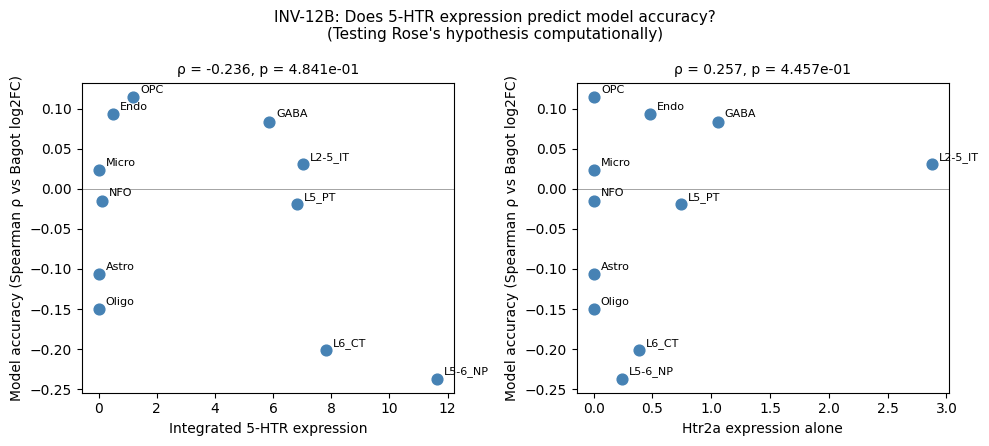

In [ ]:
# ── INV-12B: Integrated 5-HTR expression vs model accuracy per cell type ──────
# Rose's hypothesis: cell-type psilocybin sensitivity is better predicted
# by integrated serotonin receptor expression than Htr2a alone.
# Test: does per-cell-type model accuracy (rho from INV-11G) correlate
# with integrated 5-HTR expression from Bagot baseline?

from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# ── Step 1: Find HTR genes in our panel ──────────────────────────────────────
# Correct HTR gene list — actual serotonin receptors only
htr_genes = [g for g in final_genes_500
                     if g.lower().startswith('htr')
                     and not g.lower().startswith('htra')]
print(f"HTR genes in panel ({len(htr_genes)}): {htr_genes}")

# ── Step 2: Compute integrated 5-HTR expression per cell type ────────────────
# Use Bagot saline mean as the baseline expression state
htr_scores = {}
for subtype in subtypes_bagot:
    if subtype not in bagot_saline_mean:
        continue
    baseline = bagot_saline_mean[subtype]
    total = 0.0
    for gene in htr_genes:
        if gene in genes_in_bagot:
            idx = genes_in_bagot.index(gene)
            total += baseline[idx]
    htr_scores[subtype] = total

# Also store Htr2a alone for comparison
htr2a_scores = {}
for subtype in subtypes_bagot:
    if subtype not in bagot_saline_mean:
        continue
    baseline = bagot_saline_mean[subtype]
    if 'Htr2a' in genes_in_bagot:
        idx = genes_in_bagot.index('Htr2a')
        htr2a_scores[subtype] = baseline[idx]

# ── Step 3: Pull per-cell-type rho values from INV-11G ───────────────────────
inv11_rhos = {k:v['rho'] for k,v in results_11g.items()}

# ── Step 4: Align and correlate ───────────────────────────────────────────────
common = [st for st in inv11_rhos if st in htr_scores and st in htr2a_scores]

integrated = np.array([htr_scores[st]   for st in common])
htr2a_only = np.array([htr2a_scores[st] for st in common])
rhos       = np.array([inv11_rhos[st]   for st in common])

rho_int,  p_int  = spearmanr(integrated, rhos)
rho_2a,   p_2a   = spearmanr(htr2a_only, rhos)

print(f"\nIntegrated 5-HTR vs model accuracy:  ρ = {rho_int:.3f}, p = {p_int:.3e}")
print(f"Htr2a alone    vs model accuracy:  ρ = {rho_2a:.3f}, p = {p_2a:.3e}")

# ── Step 5: Plot side by side ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, scores, label, rho, p in [
    (ax1, integrated, 'Integrated 5-HTR expression', rho_int, p_int),
    (ax2, htr2a_only, 'Htr2a expression alone',      rho_2a,  p_2a),
]:
    ax.scatter(scores, rhos, color='steelblue', s=60, zorder=3)
    for i, st in enumerate(common):
        ax.annotate(st, (scores[i], rhos[i]),
                    fontsize=8, xytext=(5, 3), textcoords='offset points')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Model accuracy (Spearman ρ vs Bagot log2FC)', fontsize=10)
    ax.set_title(f'ρ = {rho:.3f}, p = {p:.3e}', fontsize=10)

fig.suptitle("INV-12B: Does 5-HTR expression predict model accuracy?\n"
             "(Testing Rose's hypothesis computationally)", fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/figures/INV12B_htr_vs_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── INV-12C: Per-animal analysis ──────────────────────────────────────────────
# Run inference per individual animal instead of mean psilo profile.
# Question: is one animal driving the signal? Is there an outlier?

from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# NOTE: UP=2, DOWN=0 per model definition in module2_investigate.py
UP_IDX, DOWN_IDX = 2, 0

animal_results = {}  # {animal: {subtype: (score, actual_lfc)}}

model.eval()
for animal in psilo_samples:
    animal_results[animal] = {}
    for subtype in subtypes_bagot:
        if subtype not in bagot_lfc or subtype not in bagot_saline_mean:
            continue
        if (animal, subtype) not in pseudobulk_bagot:
            continue

        psilo_vec = pseudobulk_bagot[(animal, subtype)]
        baseline  = bagot_saline_mean[subtype]

        # Build tensor
        x = np.full((N_GENES, N_TIMEPOINTS), NOT_MEASURED, dtype=np.float32)
        for i, g in enumerate(final_genes_500):
            if g in genes_in_bagot:
                idx = genes_in_bagot.index(g)
                x[i, 0]               = baseline[idx]
                x[i, TIMEPOINT_IDX_24H] = psilo_vec[idx]

        measured = x[x != NOT_MEASURED]
        if len(measured) == 0:
            continue
        x_norm = x.copy()
        x_norm[x != NOT_MEASURED] = (
            (measured - measured.mean()) / (measured.std() + 1e-8))
        x_norm[x == NOT_MEASURED] = NOT_MEASURED

        x_t = torch.tensor(x_norm).unsqueeze(0).to(device)
        ct  = torch.tensor([ct_list.index(BAGOT_TO_LIAO[subtype])]).to(device)
        dr  = torch.tensor([0]).to(device)

        with torch.no_grad():
            _, logits = model.forward(x_t, ct, dr)

        probs  = torch.softmax(logits[0], dim=-1).reshape(
            N_GENES, N_TIMEPOINTS, 4).cpu().numpy()
        signed = (probs[:, TIMEPOINT_IDX_24H, UP_IDX] -
                  probs[:, TIMEPOINT_IDX_24H, DOWN_IDX])

        # Align to Bagot gene ordering
        lfc_aligned = np.array([
            bagot_lfc[subtype][genes_in_bagot.index(g)]
            if g in genes_in_bagot else np.nan
            for g in final_genes_500
        ])
        valid = ~np.isnan(lfc_aligned)
        rho, p = spearmanr(signed[valid], lfc_aligned[valid])
        animal_results[animal][subtype] = {
            'rho': rho, 'p': p,
            'signed': signed, 'lfc': lfc_aligned
        }

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Subtype':<12}", end='')
for a in psilo_samples:
    print(f"  {a:>10}", end='')
print(f"  {'Mean':>8}")
print("-" * 65)

for subtype in subtypes_bagot:
    print(f"{subtype:<12}", end='')
    rhos = []
    for animal in psilo_samples:
        if subtype in animal_results.get(animal, {}):
            r = animal_results[animal][subtype]['rho']
            rhos.append(r)
            print(f"  {r:>10.3f}", end='')
        else:
            print(f"  {'—':>10}", end='')
    print(f"  {np.mean(rhos):>8.3f}" if rhos else "")

# ── Per-animal overall rho (pooled across all subtypes) ───────────────────────
print(f"\n{'Animal':<12}  {'Overall ρ':>10}  {'p':>12}")
print("-" * 38)
for animal in psilo_samples:
    all_s, all_l = [], []
    for subtype, d in animal_results[animal].items():
        valid = ~np.isnan(d['lfc'])
        all_s.extend(d['signed'][valid])
        all_l.extend(d['lfc'][valid])
    rho, p = spearmanr(all_s, all_l)
    print(f"{animal:<12}  {rho:>10.3f}  {p:>12.3e}")


Subtype           PSI_F1      PSI_F2      PSI_F4      PSI_F5      Mean
-----------------------------------------------------------------
Astro             -0.106      -0.096      -0.084      -0.108    -0.099
Endo               0.099       0.055       0.113       0.079     0.086
GABA               0.092       0.058       0.129       0.088     0.092
L2-5_IT            0.008       0.052       0.063       0.018     0.035
L5-6_NP           -0.174      -0.260           —      -0.174    -0.203
L5_PT             -0.042       0.007       0.034      -0.102    -0.026
L6_CT             -0.213      -0.101      -0.224      -0.211    -0.187
Micro              0.030       0.020       0.064       0.022     0.034
NFO                0.008       0.006      -0.040      -0.030    -0.014
OPC                0.133       0.094       0.036       0.093     0.089
Oligo             -0.157      -0.136           —      -0.158    -0.150

Animal         Overall ρ             p
--------------------------------------
PS

In [ ]:
# ── INV-12D: Model confidence analysis ───────────────────────────────────────
# For each gene × subtype in results_12a, compute confidence = max(P(UP), P(DOWN))
# Re-run masked inference storing raw probs this time.
# Quadrants: high confidence correct, high confidence wrong,
#            low confidence correct, low confidence wrong.

CONF_THRESHOLD = 0.4   # max(P(UP), P(DOWN)) > 0.4 = high confidence
LFC_THRESH_D   = 0.3   # gene must have moved to count

results_12d = {}  # {gene: {subtype: (p_up, p_down, actual_lfc)}}

model.eval()
for gene in target_genes:
    gene_idx_panel = list(final_genes_500).index(gene)
    gene_idx_bagot = genes_in_bagot.index(gene)
    results_12d[gene] = {}

    for subtype in subtypes_bagot:
        if subtype not in bagot_lfc or subtype not in bagot_saline_mean:
            continue
        psilo_vecs = [pseudobulk_bagot[(s, subtype)]
                      for s in psilo_samples
                      if (s, subtype) in pseudobulk_bagot]
        if not psilo_vecs:
            continue
        psilo_mean = np.array(psilo_vecs).mean(axis=0)
        baseline   = bagot_saline_mean[subtype]

        x = np.full((N_GENES, N_TIMEPOINTS), NOT_MEASURED, dtype=np.float32)
        for i, g in enumerate(final_genes_500):
            if g in genes_in_bagot:
                idx = genes_in_bagot.index(g)
                x[i, 0] = baseline[idx]
                if i != gene_idx_panel:
                    x[i, TIMEPOINT_IDX_24H] = psilo_mean[idx]

        measured = x[x != NOT_MEASURED]
        if len(measured) == 0:
            continue
        x_norm = x.copy()
        x_norm[x != NOT_MEASURED] = (
            (measured - measured.mean()) / (measured.std() + 1e-8))
        x_norm[x == NOT_MEASURED] = NOT_MEASURED

        x_t = torch.tensor(x_norm).unsqueeze(0).to(device)
        ct  = torch.tensor([ct_list.index(BAGOT_TO_LIAO[subtype])]).to(device)
        dr  = torch.tensor([0]).to(device)

        with torch.no_grad():
            _, logits = model.forward(x_t, ct, dr)

        probs  = torch.softmax(logits[0], dim=-1).reshape(
            N_GENES, N_TIMEPOINTS, 4).cpu().numpy()
        p_up   = probs[gene_idx_panel, TIMEPOINT_IDX_24H, UP_IDX]
        p_down = probs[gene_idx_panel, TIMEPOINT_IDX_24H, DOWN_IDX]
        actual = bagot_lfc[subtype][gene_idx_bagot]

        results_12d[gene][subtype] = (p_up, p_down, actual)

# ── Classify into quadrants ───────────────────────────────────────────────────
quadrants = {
    'high_conf_correct': [],
    'high_conf_wrong':   [],
    'low_conf_correct':  [],
    'low_conf_wrong':    [],
}

for gene, subtypes_d in results_12d.items():
    for subtype, (p_up, p_down, actual) in subtypes_d.items():
        if abs(actual) < LFC_THRESH_D:
            continue
        confidence  = max(p_up, p_down)
        pred_sign   = 1 if p_up > p_down else -1
        actual_sign = 1 if actual > 0 else -1
        correct     = pred_sign == actual_sign
        high_conf   = confidence >= CONF_THRESHOLD

        label = ('high' if high_conf else 'low') + '_conf_' + \
                ('correct' if correct else 'wrong')
        quadrants[label].append({
            'gene': gene, 'subtype': subtype,
            'confidence': confidence,
            'p_up': p_up, 'p_down': p_down,
            'actual_lfc': actual
        })

# ── Print summary ─────────────────────────────────────────────────────────────
total = sum(len(v) for v in quadrants.values())
print(f"\nConfidence analysis ({total} gene×subtype pairs, |lfc| > {LFC_THRESH_D})\n")
for q, items in quadrants.items():
    pct = len(items) / total * 100
    print(f"  {q:<25} {len(items):>4} ({pct:.1f}%)")

print(f"\n── High confidence WRONG (most dangerous) ───────────────────")
df_wrong = pd.DataFrame(quadrants['high_conf_wrong']).sort_values(
    'confidence', ascending=False)
print(df_wrong[['gene','subtype','confidence',
                'p_up','p_down','actual_lfc']].head(15).to_string(index=False))

print(f"\n── High confidence CORRECT (what the model truly learned) ───")
df_correct = pd.DataFrame(quadrants['high_conf_correct']).sort_values(
    'confidence', ascending=False)
print(df_correct[['gene','subtype','confidence',
                  'p_up','p_down','actual_lfc']].head(15).to_string(index=False))


Confidence analysis (351 gene×subtype pairs, |lfc| > 0.3)

  high_conf_correct           49 (14.0%)
  high_conf_wrong             47 (13.4%)
  low_conf_correct           140 (39.9%)
  low_conf_wrong             115 (32.8%)

── High confidence WRONG (most dangerous) ───────────────────
         gene subtype  confidence     p_up   p_down  actual_lfc
        Dock2   L6_CT    0.520259 0.143504 0.520259    0.515043
        Dock2   L5_PT    0.499997 0.227748 0.499997    2.872989
        Tafa1   L6_CT    0.499840 0.254975 0.499840    0.819563
         Mobp   L6_CT    0.495335 0.336254 0.495335    0.550656
      Cacna1g   L6_CT    0.491178 0.268583 0.491178    0.563540
       Grin2c   L6_CT    0.490788 0.213983 0.490788    0.475291
         Mobp L2-5_IT    0.488025 0.329104 0.488025    0.661959
        Csf1r   L6_CT    0.484771 0.250181 0.484771    1.814637
         Bcan   L6_CT    0.482851 0.351882 0.482851    1.109613
         Bcan L2-5_IT    0.480441 0.328059 0.480441    1.371356
         

In [ ]:
#----------Checkpoint----------------#

In [ ]:
# ── Save resume checkpoint ────────────────────────────────────────────────────
import pickle

resume = {
    # Bagot data
    'pseudobulk_bagot':   pseudobulk_bagot,
    'bagot_saline_mean':  bagot_saline_mean,
    'bagot_lfc':          bagot_lfc,
    'genes_in_bagot':     genes_in_bagot,
    'subtypes_bagot':     subtypes_bagot,
    'psilo_samples':      psilo_samples,
    'saline_samples':     saline_samples,
    # INV-11/12 results
    'results_11g':        results_11g,
    'bagot_signed_scores':bagot_signed_scores,
    'results_12a':        results_12a,
    'results_12d':        results_12d,
    'df_12a':             df_12a,
    'target_genes':       target_genes,
    'animal_results':     animal_results,
    # Mappings
    'BAGOT_TO_LIAO':      BAGOT_TO_LIAO,
    'ct_list':            ct_list,
}
resume['quadrants'] = quadrants

with open(f'{DRIVE_PATH}/module2-gene-delta/data/bagot_resume.pkl', 'wb') as f:
    pickle.dump(resume, f)
print("Resume checkpoint saved.")

Resume checkpoint saved.


In [ ]:
#------------------------------------- Dr Bagot -------------------------------------------------#